# Bacté-rivières 2026 : Data Analysis

## Links

- https://drive.google.com/drive/folders/1qfFN4roD6TY7QjWE8HPuSzKs657fmXJE
- https://github.com/hammerdirt/water-quality-2016-2017
- https://github.com/Hackuarium/montreux-water-quality
- https://besjournals.onlinelibrary.wiley.com/doi/10.1002/2688-8319.12094

## TODO

- Permutation test
- Amont vs. aval

## 1. Necessary Libraries Import

In [1]:
import sys
import IPython
import math
import pandas as pd
import matplotlib
import matplotlib_inline
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from scipy.stats import norm
import seaborn as sns
from IPython.core.display import HTML
from matplotlib.ticker import SymmetricalLogLocator
from datetime import date
from itertools import product

In [2]:
# Réglage de l'affichage par défaut des nombres réels sur deux décimales :
pd.options.display.float_format = '{:.2f}'.format

In [3]:
HTML("""
<style>
.jp-OutputArea-child {
    max-height: none !important;
}
.jp-OutputArea-output {
    overflow-y: visible !important;
}
</style>
""")

In [4]:
HTML("""
<style>
.jp-OutputArea-output {
    max-height: none !important;
    overflow-y: visible !important;
}
</style>
""")

In [5]:
first_week_start_date = date(2026, 6, 15)
weather_color = '#9ecae1'

## 2. Data Import

Measurements were saved into the following Excel (XLSX) file:

In [6]:
results_file_name = "2026-09-28_Resultats_Bacte-Rivieres_clean.xlsx"

### 2.1. Analyzed Sites

In [7]:
df_metadata = pd.read_excel(results_file_name, sheet_name='Sites')
df_metadata

,ID site,Rivière,Localisation,Coord GPS,Qui,Lieu d'incubation
0,BIE1,Bief,Lonay,2'529'592 1'153'768,Céline et Danièle,Hackuarium/Lonay
1,BIE2,Bief,Prison de la Tuilière,46'31'08.5 6'30'49.7,Yvonne et Ariane,Lonay\n
2,BMO1,Baie de Montreux Rivière,Amont,2'560'053.04 1'142'670.23,Rachel,Hackuarium
3,BMO2,Baie de Montreux Rivière,Embouchure,2'559'273.04 1'142'310.67,Rachel,Hackuarium
4,BOIM1,Boiron de Morges,Fontaine chasseurs,2'519'765 1'154'417,MDLR,MDLR
5,BOIM2,Boiron de Morges,Lussy,2'523'153 1'150'170,Maurice,MDLR
6,BOIM3,Boiron de Morges,Embouchure,2'526'282 1'149'559,MDLR,MDLR
7,BOIN1,Boiron de Nyon,Nyon2,2'506'966 1'136'977,Esther,Hackuarium
8,CHA1,Chamberonne,Amont,2'534'615 1'152'163,Objectif sciences internationales \n& Aleksandra,Camping de Vidy \n& Hackuarium
9,CHA2,Chamberonne,Embouchure,2'534'461 1'152'469,Objectif sciences internationales \n& Aleksandra,Camping de Vidy \n& Hackuarium


The above coordinates are based on the [official Swiss coordinates system (MN95)](https://www.swisstopo.admin.ch/fr/le-systeme-de-coordonnees-suisse).

### 2.2. Weather Data

Weekly weather data (means):

In [8]:
df_weekly_weather = pd.read_excel(results_file_name, sheet_name='Climat')
df_weekly_weather

,ID site,Station,Semaine,Précipitations,Température moyenne
0,COS1,CHANGINS,1,NaN,NaN
1,VNX,LATOURDEPEILZ,1,0.00,21.40
2,SVT,LATOURDEPEILZ,1,0.00,21.40
3,MRD,LATOURDEPEILZ,1,0.00,21.40
4,BMO1,LATOURDEPEILZ,1,0.00,21.40
...,...,...,...,...,...
251,VEN3,UNIL,8,NaN,NaN
252,VEN4,UNIL,8,0.00,25.40
253,VEV1,CHARDONNE,8,NaN,NaN
254,VEV2,CHARDONNE,8,NaN,NaN


Daily weather data:

In [9]:
df_daily_weather = pd.read_excel(results_file_name, sheet_name='Climat - journalier')
df_daily_weather.head(10)

,Valeurs,2026-06-13 00:00:00,2026-06-14 00:00:00,2026-06-15 00:00:00,2026-06-16 00:00:00,2026-06-17 00:00:00,2026-06-18 00:00:00,2026-06-19 00:00:00,2026-06-20 00:00:00,2026-06-21 00:00:00,...,2026-07-31 00:00:00,2026-08-01 00:00:00,2026-08-02 00:00:00,2026-08-03 00:00:00,2026-08-04 00:00:00,2026-08-05 00:00:00,2026-08-06 00:00:00,2026-08-07 00:00:00,2026-08-08 00:00:00,2026-08-09 00:00:00
0,CHANGINS.MOY.TEMP,20.65,21.72,20.58,21.46,22.50,28.46,24.80,23.79,25.74,...,25.32,24.82,26.14,25.65,23.93,23.85,25.87,24.35,24.38,24.08
1,CHANGINS.ET.TEMP,5.52,4.48,4.85,5.08,5.60,2.90,4.53,5.44,5.27,...,4.66,4.26,4.06,4.07,5.16,4.42,2.68,3.16,4.74,3.85
2,CHANGINS.ETS.TEMP,5.41,4.38,4.75,4.98,5.43,2.80,4.43,5.32,5.16,...,4.56,4.17,3.98,3.98,5.05,4.32,2.63,3.09,4.64,3.77
3,CHANGINS.SOM.PREC,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.40,0.60,0.00,4.40,15.50,0.00,0.00,0.00,0.00,0.20
4,AUBONNE.MOY.TEMP,20.33,21.00,19.78,20.97,22.07,28.49,24.38,23.77,25.14,...,24.48,24.91,26.64,25.03,23.36,23.63,24.47,24.78,24.95,23.73
5,AUBONNE.ET.TEMP,6.22,5.74,6.04,5.47,5.93,3.65,4.56,5.83,5.41,...,4.72,4.69,3.72,4.31,5.27,4.78,4.56,3.52,4.18,4.56
6,AUBONNE.ETS.TEMP,6.09,5.62,5.91,5.35,5.75,3.51,4.46,5.71,5.30,...,4.62,4.59,3.64,4.22,5.16,4.68,4.47,3.45,4.09,4.47
7,AUBONNE.SOM.PREC,0.00,1.20,6.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.40,0.00,0.00,3.20,17.80,0.20,0.00,0.00,0.00,0.00
8,ETOY.MOY.TEMP,20.28,21.27,20.46,21.08,22.12,28.59,24.48,23.93,25.54,...,25.03,25.16,26.62,25.53,23.92,23.86,24.83,24.97,25.34,24.46
9,ETOY.ET.TEMP,5.14,4.61,4.84,5.02,4.66,3.06,3.61,5.03,4.49,...,3.74,3.87,3.40,3.41,4.58,4.20,3.52,3.04,3.35,3.50


In [10]:
# Mapping station -> site(s)
site_station = (
    df_weekly_weather[['Station', 'ID site']]
    .drop_duplicates()
)

# Extraire la station depuis "Valeurs"
df_daily_weather = df_daily_weather.copy()
df_daily_weather['Station'] = df_daily_weather['Valeurs'].str.split('.').str[0]

# Dupliquer automatiquement les lignes si une station correspond à plusieurs sites
df_daily_weather = df_daily_weather.merge(
    site_station,
    on='Station',
    how='left'
)

# Remplacer le préfixe station par l'ID site
df_daily_weather['Valeurs'] = (
    df_daily_weather['ID site']
    + '.'
    + df_daily_weather['Valeurs'].str.split('.', n=1).str[1]
)

# Enlever les colonnes temporaires
df_daily_weather = df_daily_weather.drop(columns='Station')
df_daily_weather = df_daily_weather.drop(columns='ID site')

# Transposer le DataFrame
df_daily_weather = (
    df_daily_weather
    .set_index('Valeurs')
    .T
    .reset_index()
    .rename(columns={'index': 'Date'})
)

# Conversion datetime --> date
df_daily_weather['Date'] = pd.to_datetime(df_daily_weather['Date']).dt.date

# Date en index tu DataFrame
df_daily_weather = df_daily_weather.set_index('Date')

# Enlever le 'Valeurs' de la colonne d'index
df_daily_weather = df_daily_weather.rename_axis(columns=None)

df_daily_weather.head(10)

,COS1.MOY.TEMP,BOIN1.MOY.TEMP,COS1.ET.TEMP,BOIN1.ET.TEMP,COS1.ETS.TEMP,BOIN1.ETS.TEMP,COS1.SOM.PREC,BOIN1.SOM.PREC,BOIM1.MOY.TEMP,BOIM1.ET.TEMP,...,CHA2.SOM.PREC,MEB1.SOM.PREC,MEB2.SOM.PREC,SOR1.SOM.PREC,VEN0.SOM.PREC,VEN1.SOM.PREC,VEN2.SOM.PREC,VEN3.SOM.PREC,VEN4.SOM.PREC,TUB.SOM.PREC
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-13,20.65,20.65,5.52,5.52,5.41,5.41,0.00,0.00,20.33,6.22,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-14,21.72,21.72,4.48,4.48,4.38,4.38,0.00,0.00,21.00,5.74,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-15,20.58,20.58,4.85,4.85,4.75,4.75,0.00,0.00,19.78,6.04,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-16,21.46,21.46,5.08,5.08,4.98,4.98,0.00,0.00,20.97,5.47,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-17,22.50,22.50,5.60,5.60,5.43,5.43,0.00,0.00,22.07,5.93,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-18,28.46,28.46,2.90,2.90,2.80,2.80,0.00,0.00,28.49,3.65,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-19,24.80,24.80,4.53,4.53,4.43,4.43,0.00,0.00,24.38,4.56,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-20,23.79,23.79,5.44,5.44,5.32,5.32,0.00,0.00,23.77,5.83,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2026-06-21,25.74,25.74,5.27,5.27,5.16,5.16,0.00,0.00,25.14,5.41,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [11]:
def get_weekly_metric(df_daily_weather, week, site_id, metric):
    if week not in range(1, 9):
        raise ValueError("week doit être compris entre 1 et 8")

    column = f"{site_id}.{metric}"

    if column not in df_daily_weather.columns:
        raise KeyError(f"Colonne introuvable : {column}")

    start_date = pd.Timestamp('2026-06-15') + pd.Timedelta(weeks=week - 1)

    dates = pd.date_range(
        start=start_date,
        periods=7,
        freq='D'
    )

    result = (
        df_daily_weather
        .reindex(dates)[[column]]
        .rename(columns={column: metric})
    )

    result.index.name = 'Date'

    return result

Test :

In [12]:
get_weekly_metric(
    df_daily_weather,
    1,
    'COS1',
    'MOY.TEMP'
)

,MOY.TEMP
Date,
2026-06-15,20.58
2026-06-16,21.46
2026-06-17,22.50
2026-06-18,28.46
2026-06-19,24.80
2026-06-20,23.79
2026-06-21,25.74


### 2.3. Bacterial Colonies Measurements

In [13]:
df = pd.read_excel(results_file_name, sheet_name='Résultats', dtype={
    "Semaine": "object",
    "Nb colonies E. coli par 100 ml": "float64"
})
df.head(10)

,ID site,Echantillon,Semaine,Nb colonies E. coli,Nb colonies coliformes,Nb colonies E. coli par 100 ml,Nb colonies coliformes par 100 ml,Notes
0,COS1,A,1,NaN,NaN,NaN,NaN,NaN
1,COS1,B,1,NaN,NaN,NaN,NaN,NaN
2,COS1,C,1,NaN,NaN,NaN,NaN,NaN
3,VNX,A,1,12.00,78.00,1200.00,7800.00,turquoise esp
4,VNX,B,1,4.00,67.00,400.00,6700.00,pour VNX ?
5,VNX,C,1,9.00,98.00,900.00,9800.00,NaN
6,SVT,A,1,0.00,2.00,0.00,200.00,NaN
7,SVT,B,1,0.00,2.00,0.00,200.00,plus propre !
8,SVT,C,1,0.00,4.00,0.00,400.00,NaN
9,MRD,A,1,6.00,139.00,600.00,13900.00,NaN


### 2.4. Merging the DataFrames

In [14]:
df = df.merge(df_metadata, on='ID site')
df = df.merge(df_weekly_weather, on=['ID site', 'Semaine'])
df.head(20)

,ID site,Echantillon,Semaine,Nb colonies E. coli,Nb colonies coliformes,Nb colonies E. coli par 100 ml,Nb colonies coliformes par 100 ml,Notes,Rivière,Localisation,Coord GPS,Qui,Lieu d'incubation,Station,Précipitations,Température moyenne
0,COS1,A,1,NaN,NaN,NaN,NaN,NaN,Cossy,Nyon,2'507'269.09 1'137'852.59,Esther,Hackuarium/Nyon,CHANGINS,NaN,NaN
1,COS1,B,1,NaN,NaN,NaN,NaN,NaN,Cossy,Nyon,2'507'269.09 1'137'852.59,Esther,Hackuarium/Nyon,CHANGINS,NaN,NaN
2,COS1,C,1,NaN,NaN,NaN,NaN,NaN,Cossy,Nyon,2'507'269.09 1'137'852.59,Esther,Hackuarium/Nyon,CHANGINS,NaN,NaN
3,VNX,A,1,12.00,78.00,1200.00,7800.00,turquoise esp,Baie de Montreux Lac,Montreux 1 VNX,2'558'640.16 1'143'394.41,Rachel,Hackuarium,LATOURDEPEILZ,0.00,21.40
4,VNX,B,1,4.00,67.00,400.00,6700.00,pour VNX ?,Baie de Montreux Lac,Montreux 1 VNX,2'558'640.16 1'143'394.41,Rachel,Hackuarium,LATOURDEPEILZ,0.00,21.40
5,VNX,C,1,9.00,98.00,900.00,9800.00,NaN,Baie de Montreux Lac,Montreux 1 VNX,2'558'640.16 1'143'394.41,Rachel,Hackuarium,LATOURDEPEILZ,0.00,21.40
6,SVT,A,1,0.00,2.00,0.00,200.00,NaN,Baie de Montreux Lac,Montreux 2 SVT,2'559'027.81 1'143'087.97,Rachel,Hackuarium,LATOURDEPEILZ,0.00,21.40
7,SVT,B,1,0.00,2.00,0.00,200.00,plus propre !,Baie de Montreux Lac,Montreux 2 SVT,2'559'027.81 1'143'087.97,Rachel,Hackuarium,LATOURDEPEILZ,0.00,21.40
8,SVT,C,1,0.00,4.00,0.00,400.00,NaN,Baie de Montreux Lac,Montreux 2 SVT,2'559'027.81 1'143'087.97,Rachel,Hackuarium,LATOURDEPEILZ,0.00,21.40
9,MRD,A,1,6.00,139.00,600.00,13900.00,NaN,Baie de Montreux Lac,Montreux 3 MRD,2'559'292.40 1'142'415.33,Rachel,Hackuarium,LATOURDEPEILZ,0.00,21.40


Data types:

In [15]:
df.dtypes

ID site                               object
Echantillon                           object
Semaine                               object
Nb colonies E. coli                  float64
Nb colonies coliformes               float64
Nb colonies E. coli par 100 ml       float64
Nb colonies coliformes par 100 ml    float64
Notes                                 object
Rivière                               object
Localisation                          object
Coord GPS                             object
Qui                                   object
Lieu d'incubation                     object
Station                               object
Précipitations                       float64
Température moyenne                  float64
dtype: object

## 3. Data Analysis

### 3.1. Global Analysis (All Rivers Combined)

#### 3.1.1. Missing Values

In [16]:
print('The dataset contains ' + str(df.shape[0]) + ' measurements.')

The dataset contains 768 measurements.


In [17]:
missing = pd.DataFrame({
    'Number of missing values': df.isna().sum(),
    '%': df.isna().mean() * 100
}).sort_values('Number of missing values', ascending=False)

missing

,Number of missing values,%
Notes,639,83.20
Précipitations,165,21.48
Température moyenne,165,21.48
Nb colonies coliformes,102,13.28
Nb colonies coliformes par 100 ml,102,13.28
Nb colonies E. coli,92,11.98
Nb colonies E. coli par 100 ml,92,11.98
ID site,0,0.00
Echantillon,0,0.00
Semaine,0,0.00


#### 3.1.2. Descriptive Statistics & Data Distribution

In [18]:
df.describe()

,Nb colonies E. coli,Nb colonies coliformes,Nb colonies E. coli par 100 ml,Nb colonies coliformes par 100 ml,Précipitations,Température moyenne
count,676.00,666.00,676.00,666.00,603.00,603.00
mean,47.49,291.08,4749.41,29107.51,1.07,24.77
std,155.57,317.00,15556.50,31700.46,4.45,2.23
min,0.00,0.00,0.00,0.00,0.00,19.80
25%,2.00,100.00,200.00,10000.00,0.00,22.90
50%,7.00,226.50,700.00,22650.00,0.00,24.90
75%,18.00,364.00,1800.00,36400.00,0.00,26.30
max,2450.00,2800.00,245000.00,280000.00,34.10,28.80


**Note :** Missing values (`NaN`) were left out of the above computed values.

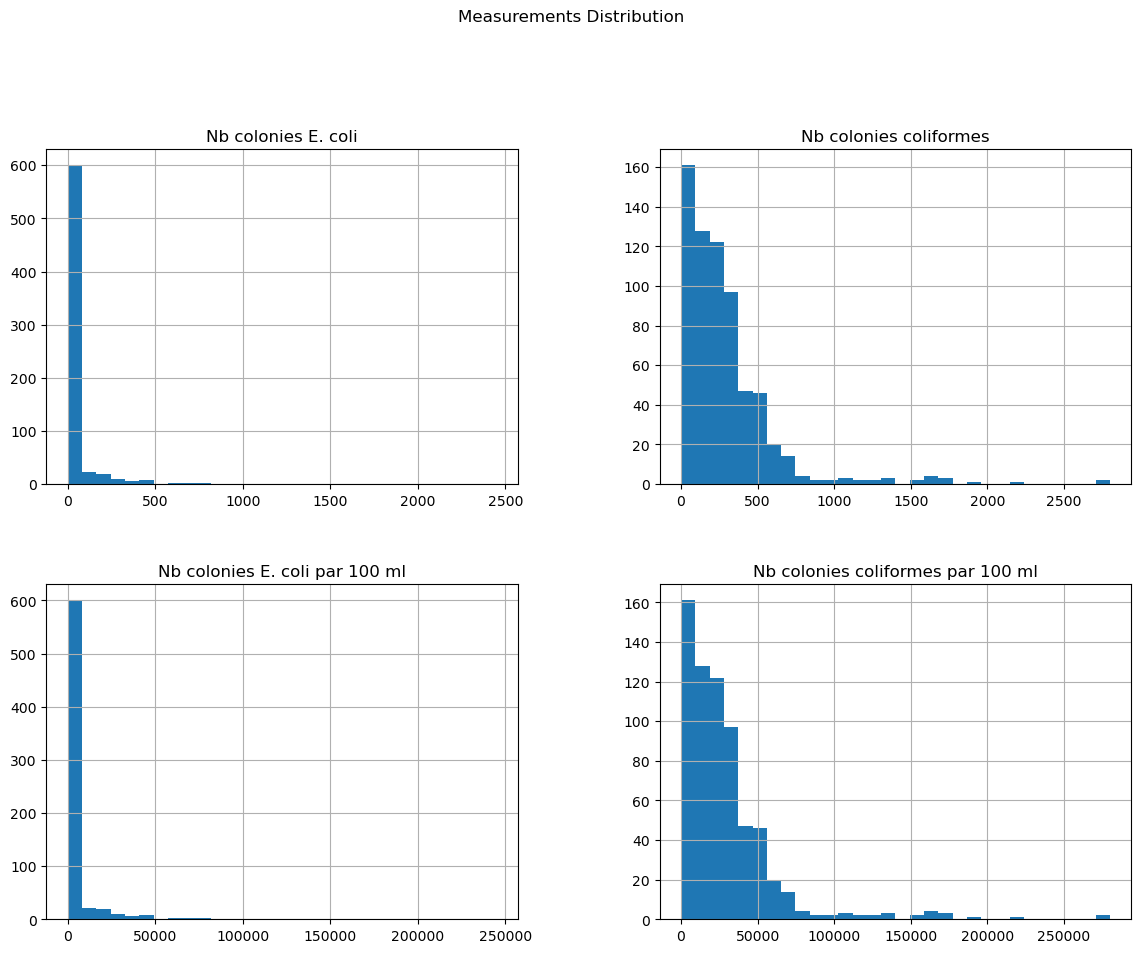

In [19]:
cols_measurements = [
    'Nb colonies E. coli',
    'Nb colonies coliformes'
]
cols_measurements_per_100mL = [
    'Nb colonies E. coli par 100 ml',
    'Nb colonies coliformes par 100 ml'
]

df[cols_measurements + cols_measurements_per_100mL].hist(figsize=(14, 10), bins=30)
plt.suptitle("Measurements Distribution", y=1.02);

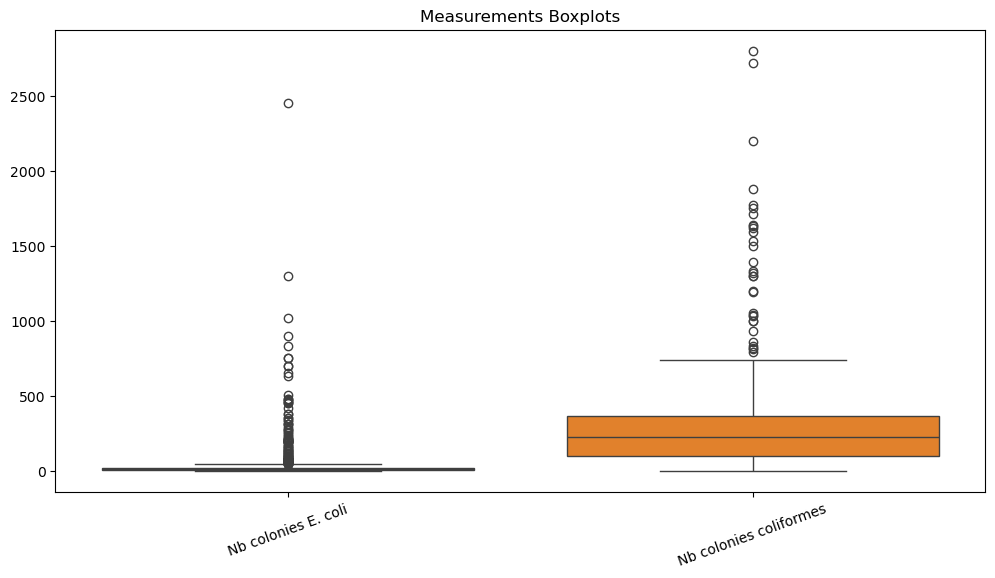

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_measurements])
plt.xticks(rotation=20)
plt.title("Measurements Boxplots");

Many outliers...

After filtering out the outliers (above `18` for the E. coli colonies count and above `696` for the coliform colonies count:

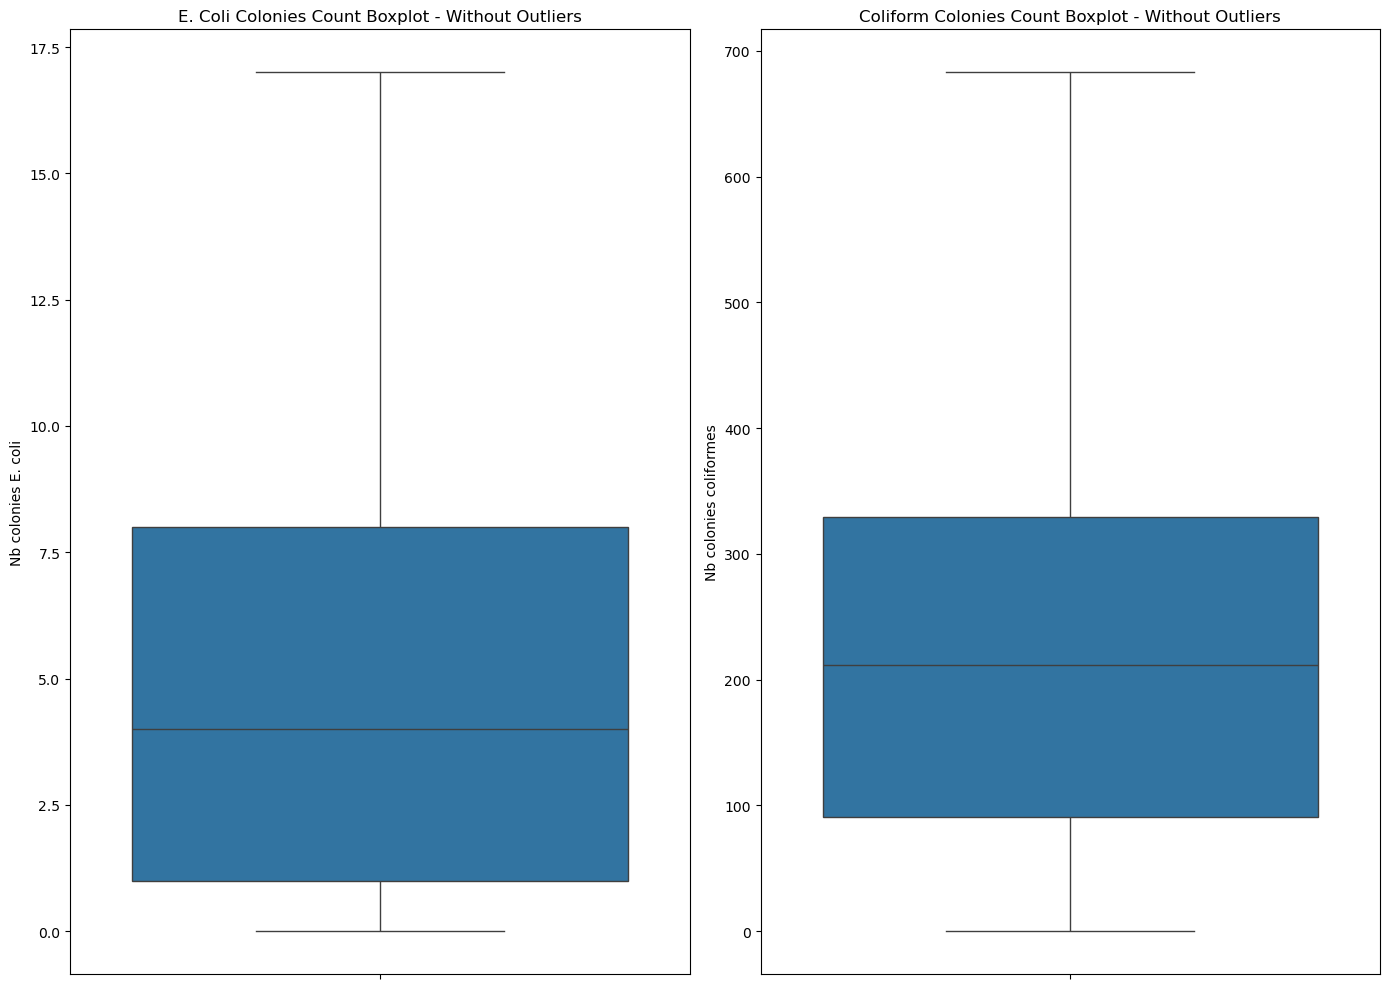

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=df[df['Nb colonies E. coli'] < 18]['Nb colonies E. coli'], ax=axes[0])
#plt.xticks(rotation=20)
axes[0].set_title("E. Coli Colonies Count Boxplot - Without Outliers")

sns.boxplot(data=df[df['Nb colonies coliformes'] < 696]['Nb colonies coliformes'], ax=axes[1])
#plt.xticks(rotation=20)
axes[1].set_title("Coliform Colonies Count Boxplot - Without Outliers")

plt.tight_layout();

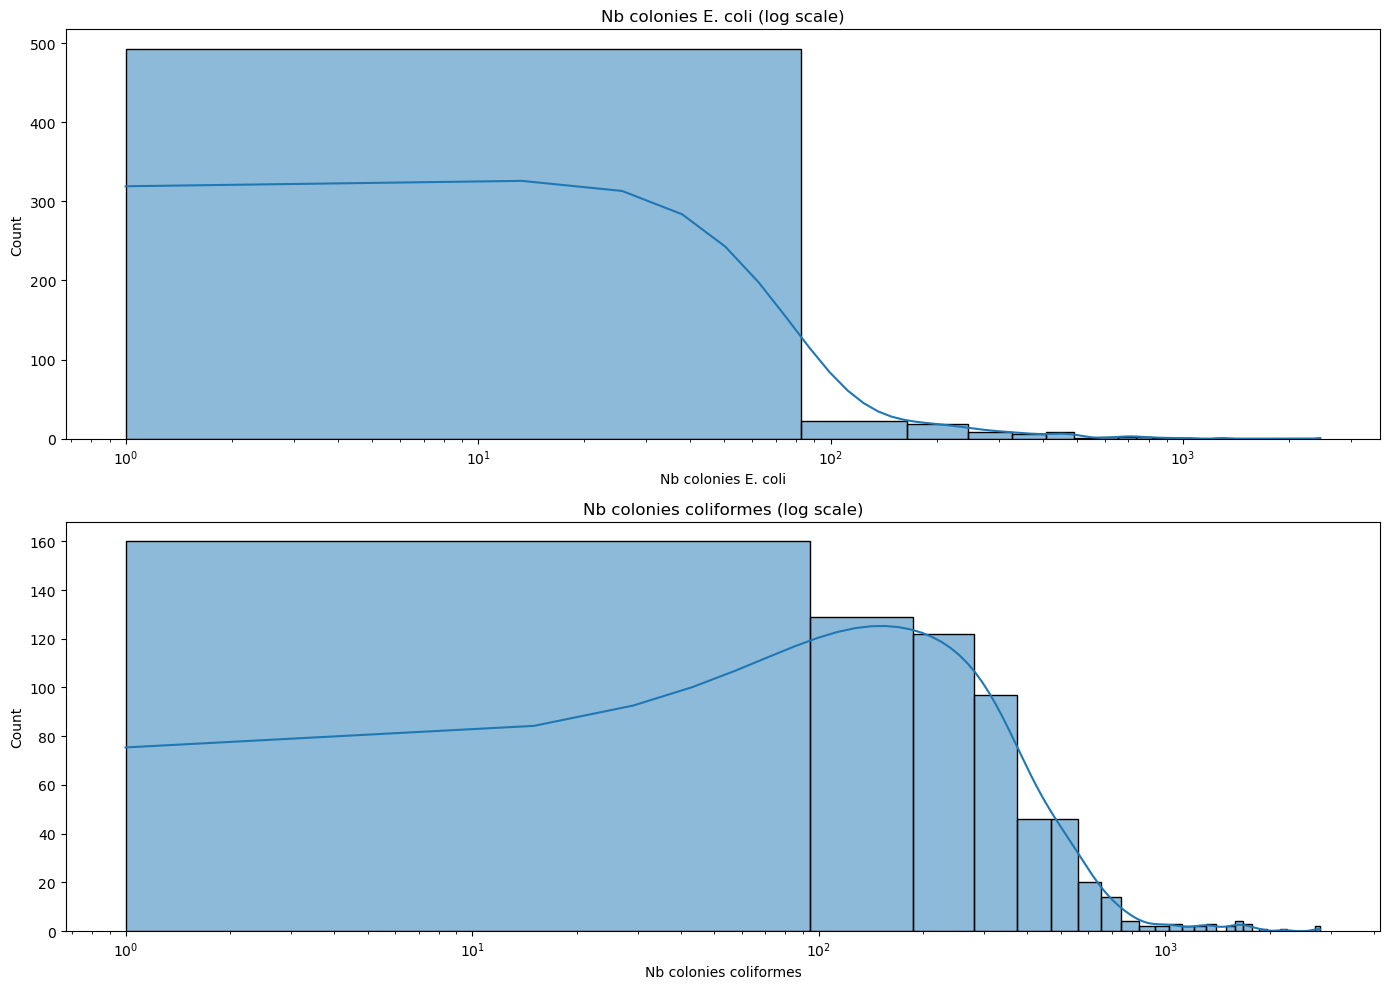

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_measurements):
    x = df[col].dropna()
    x = x[x > 0]  # to avoid log(0)
    
    sns.histplot(x, bins=30, kde=True, ax=axes[i])
    axes[i].set_xscale('log')
    axes[i].set_title(col + " (log scale)")

plt.tight_layout();

### 3.2. Overall Analysis By River

In [23]:
rivers = np.unique(df['Rivière'])
rivers

array(['Baie de Montreux Lac', 'Baie de Montreux Rivière', 'Bief',
       'Boiron de Morges', 'Boiron de Nyon', 'Chamberonne', 'Cossy',
       'Morges', 'Mèbre', 'Paudèze', 'Plage de Préverenges', 'Sorge',
       'Tuyaux EC/EU', 'Venoge', 'Veveyse', 'Vuachère'], dtype=object)

In [24]:
df.groupby('Rivière').agg({
    'Nb colonies E. coli':'mean',
    'Nb colonies coliformes':'mean'
}).sort_values('Nb colonies E. coli')

,Nb colonies E. coli,Nb colonies coliformes
Rivière,,
Baie de Montreux Lac,0.84,44.37
Plage de Préverenges,1.14,83.76
Baie de Montreux Rivière,3.02,59.79
Veveyse,5.36,155.86
Boiron de Nyon,7.62,284.62
Morges,7.76,238.10
Cossy,10.71,599.94
Boiron de Morges,10.74,358.85
Sorge,11.83,82.00


In [25]:
stats = df.groupby('Rivière')[cols_measurements].describe()

sem = df.groupby('Rivière')[cols_measurements].sem()

for col in cols_measurements:
    stats[(col, 'sem')] = sem[col]

stats = stats.sort_values(
    by=('Nb colonies E. coli', '75%'),
    ascending=False
)

stats.style.background_gradient(
    cmap='viridis'
).format('{:.2f}')

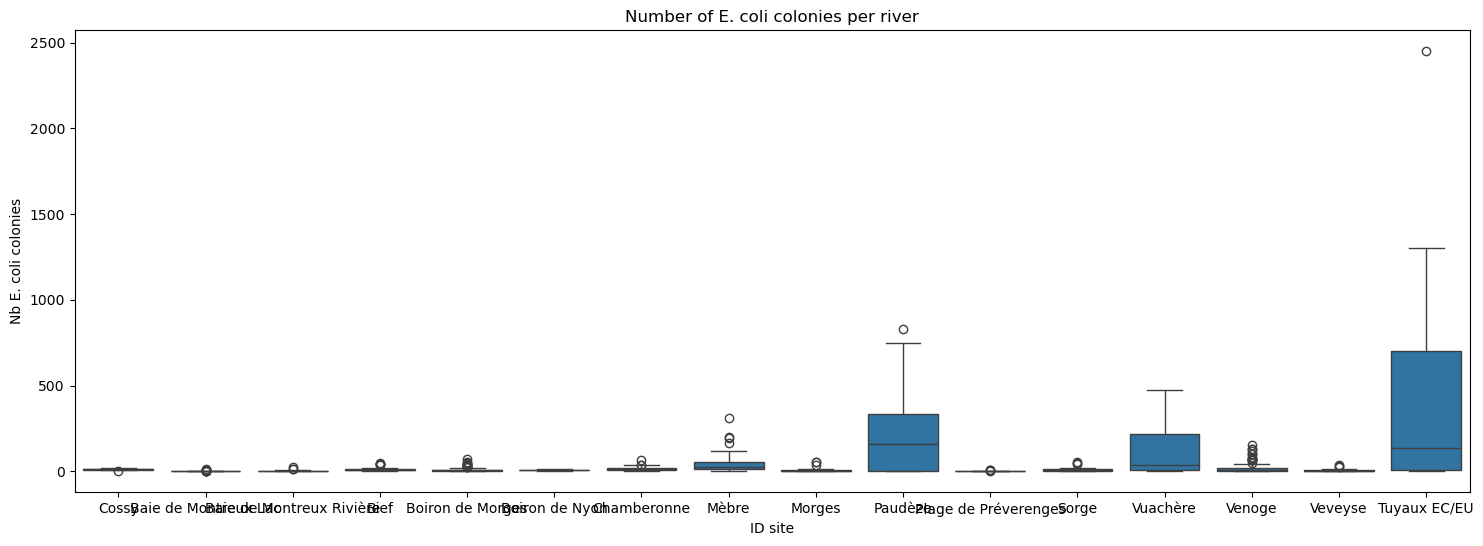

In [26]:
plt.figure(figsize=(18, 6))

sns.boxplot(
    data=df,
    x='Rivière',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per river")
plt.xlabel("ID site")
plt.ylabel("Nb E. coli colonies");

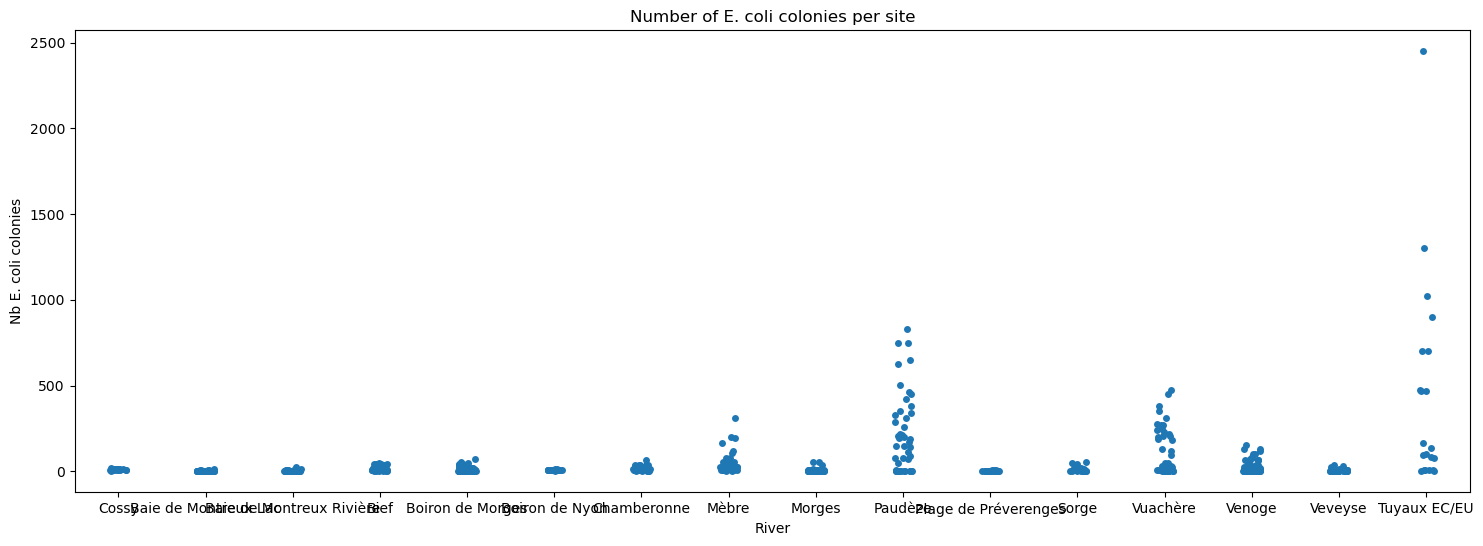

In [27]:
plt.figure(figsize=(18, 6))

sns.stripplot(
    data=df,
    x='Rivière',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per site")
plt.xlabel("River")
plt.ylabel("Nb E. coli colonies");

In [28]:
def plotByField(data, field, column, plotType):
    fieldValues = sorted(data[field].dropna().unique())

    ncols = 4
    nrows = math.ceil(len(fieldValues) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 4 * nrows)
    )

    axes = axes.flatten()

    for ax, fld in zip(axes, fieldValues):
        data_field = df.loc[
            data[field] == fld,
            column
        ].dropna()
    
        if plotType == "boxplot":
            sns.boxplot(
                y=data_field,
                ax=ax
            )
        elif plotType == "stripplot":
            sns.stripplot(
                y=data_field,
                ax=ax,
                size=3,
                alpha=0.5
            )
    
        ax.set_title(fld)
        ax.set_ylabel(column)
        ax.set_xlabel("")
    
    # Hide unused cells
    for ax in axes[len(fieldValues):]:
        ax.set_visible(False)
    
    plt.tight_layout()

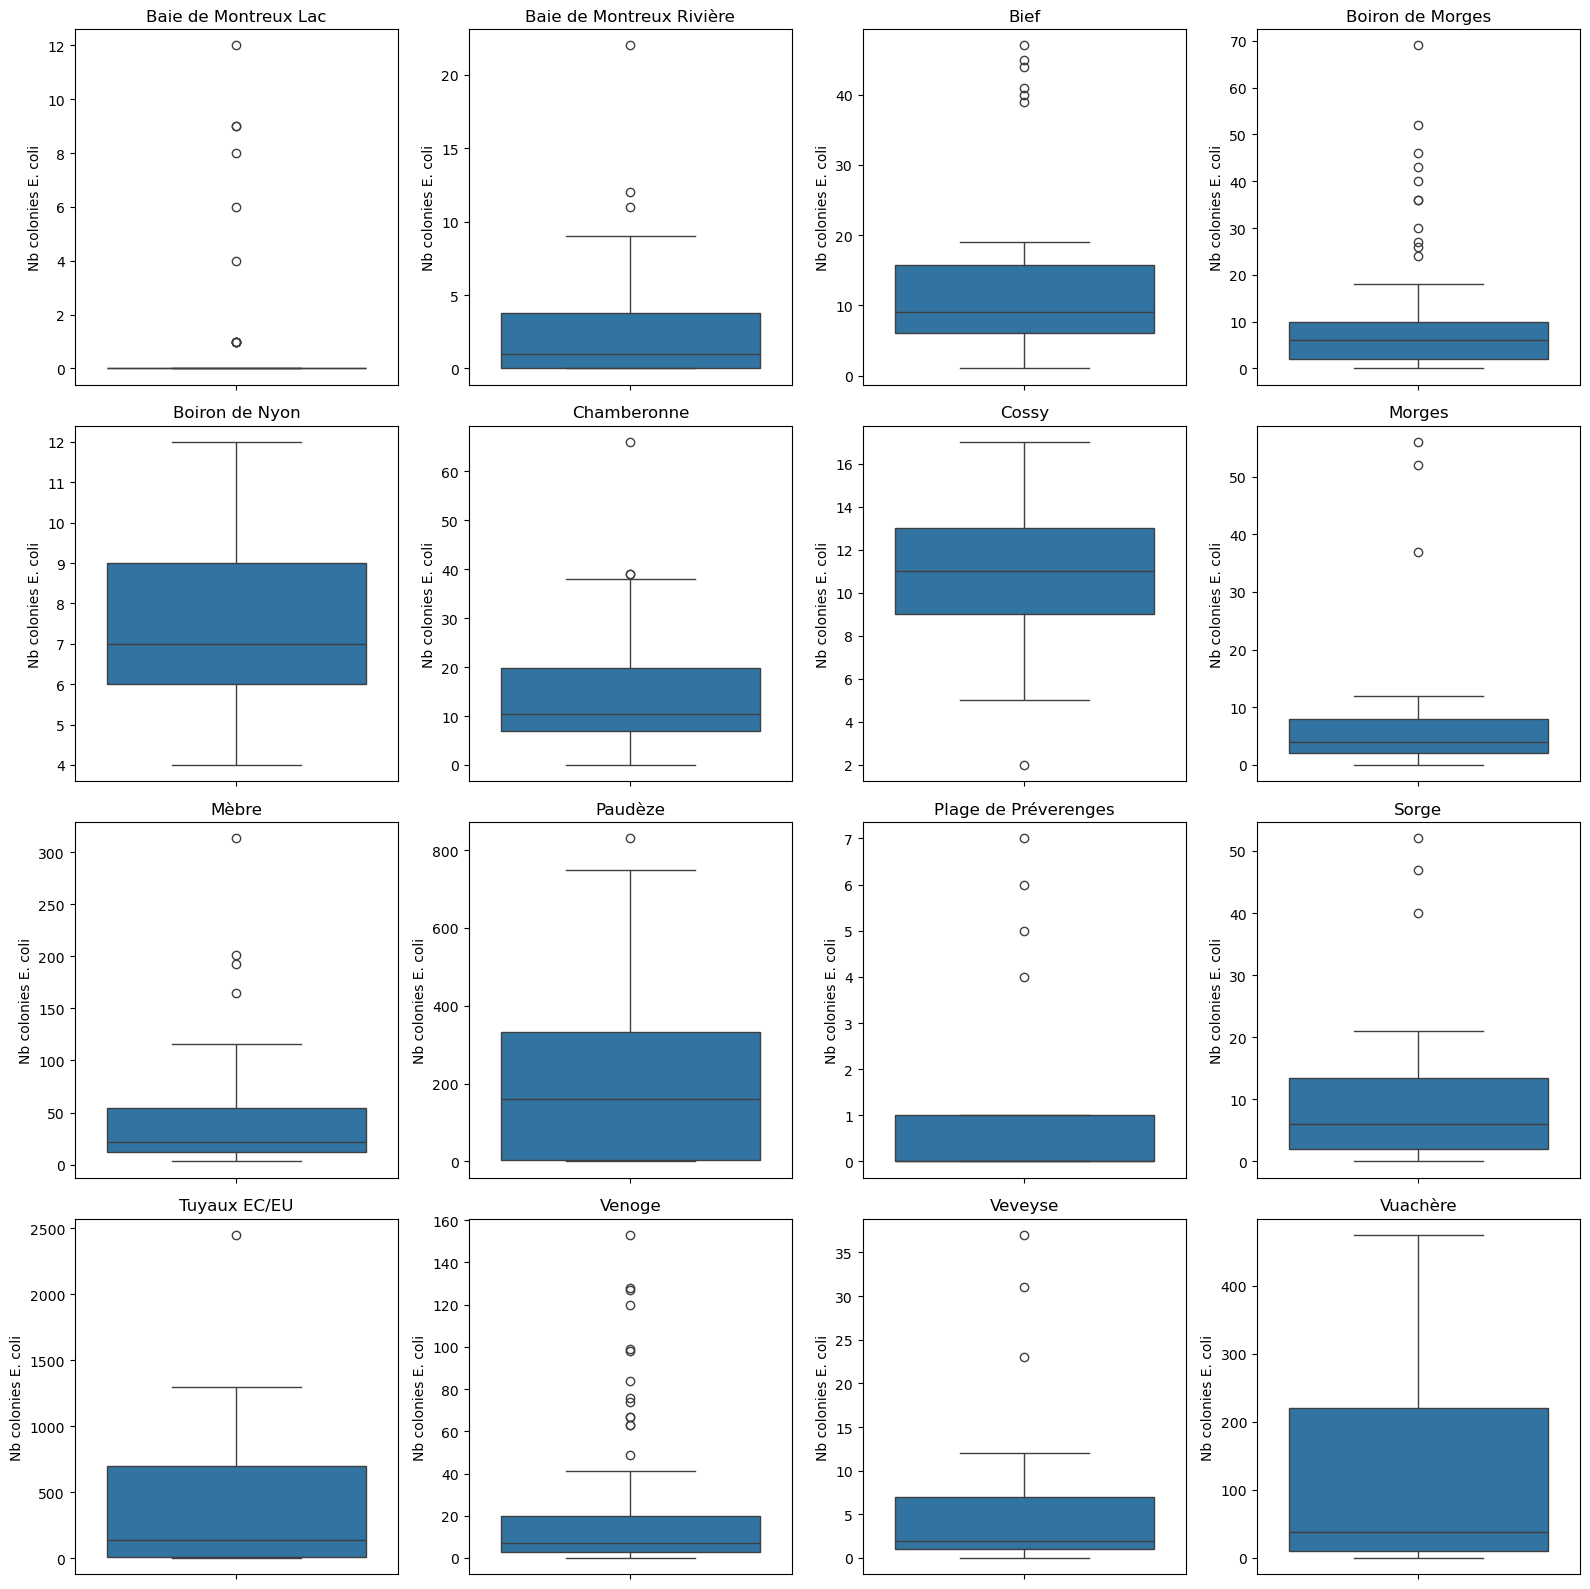

In [29]:
plotByField(df, "Rivière", "Nb colonies E. coli", "boxplot")

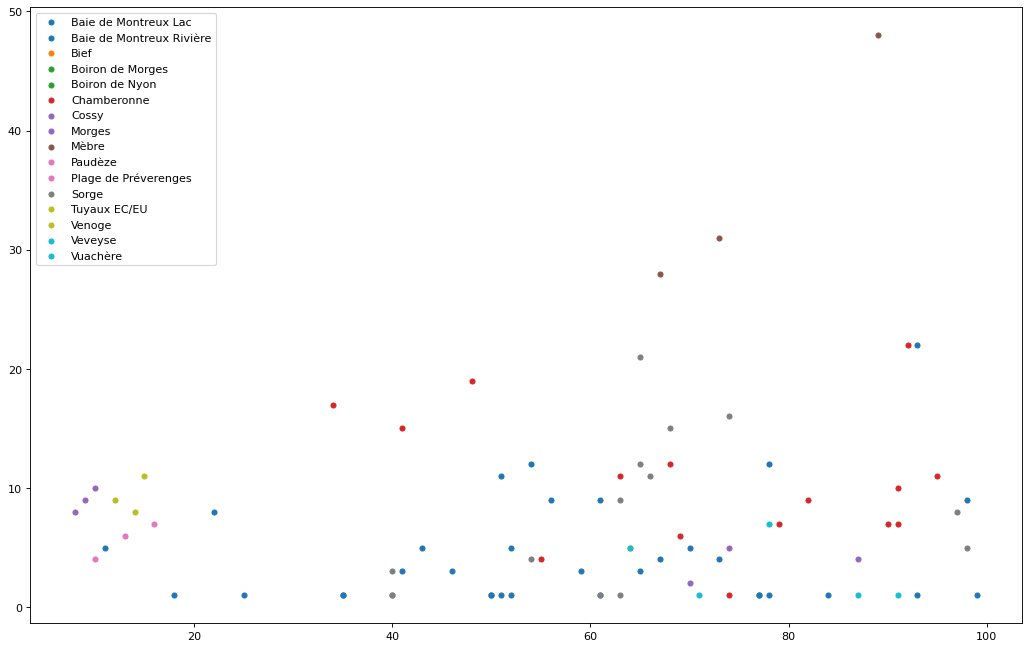

In [30]:
colors = [plt.cm.tab10(i/float(len(rivers)-1)) for i in range(len(rivers))]

df2 = df[(df['Nb colonies E. coli'] > 0) & (df['Nb colonies E. coli'] < 100) & (df['Nb colonies coliformes'] < 100) & (df['Nb colonies coliformes'] > 0)]

plt.figure(figsize=(16, 10), dpi= 80, facecolor='w', edgecolor='k')

for i, river in enumerate(rivers):
    plt.scatter('Nb colonies coliformes', 'Nb colonies E. coli', 
                data=df2.loc[df2['Rivière']==river, :], 
                s=20, color=colors[i], label=str(river))

plt.legend();

/var/folders/2f/64mxbpb54jlcq8vg5f_p1ybm0000gn/T/ipykernel_99868/1408856043.py:4: UserWarning: 
The palette list has fewer values (7) than needed (16) and will cycle, which may produce an uninterpretable plot.
  ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='Rivière', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)


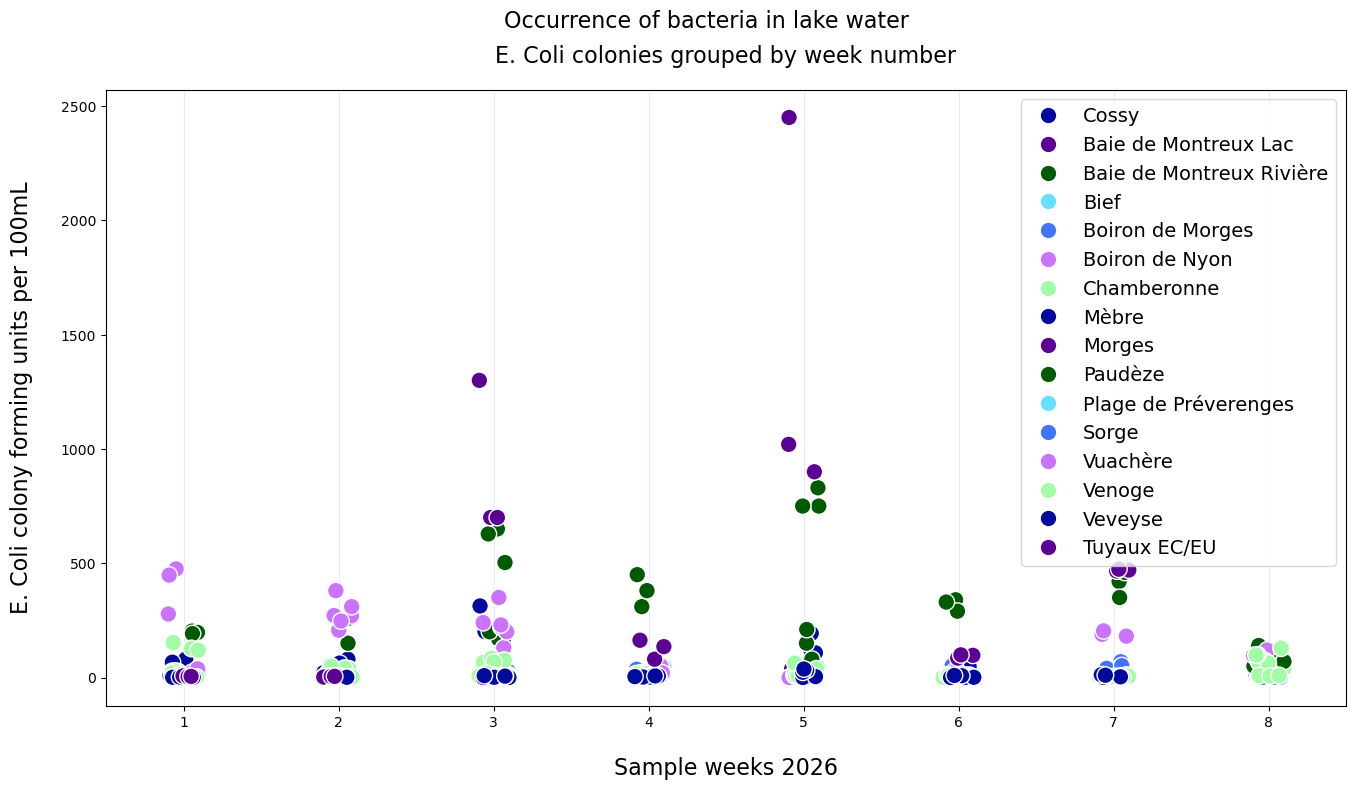

In [31]:
colors = ['#000A9C', '#5B0094', '#005903', '#68DFFC', '#4275FF', '#C973FF', '#A2FCA5']
fig, ax = plt.subplots(figsize=(16,8))

ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='Rivière', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)
ax.set_xlabel("Sample weeks 2026", size=16, labelpad=20)

ax.set_ylabel("E. Coli colony forming units per 100mL", size=16, labelpad=20)
plt.suptitle("Occurrence of bacteria in lake water" , fontsize=16, family='sans')
plt.title("E. Coli colonies grouped by week number", fontsize=16, family='sans', y=1.03)
ax.legend(loc='upper right', fontsize=14);

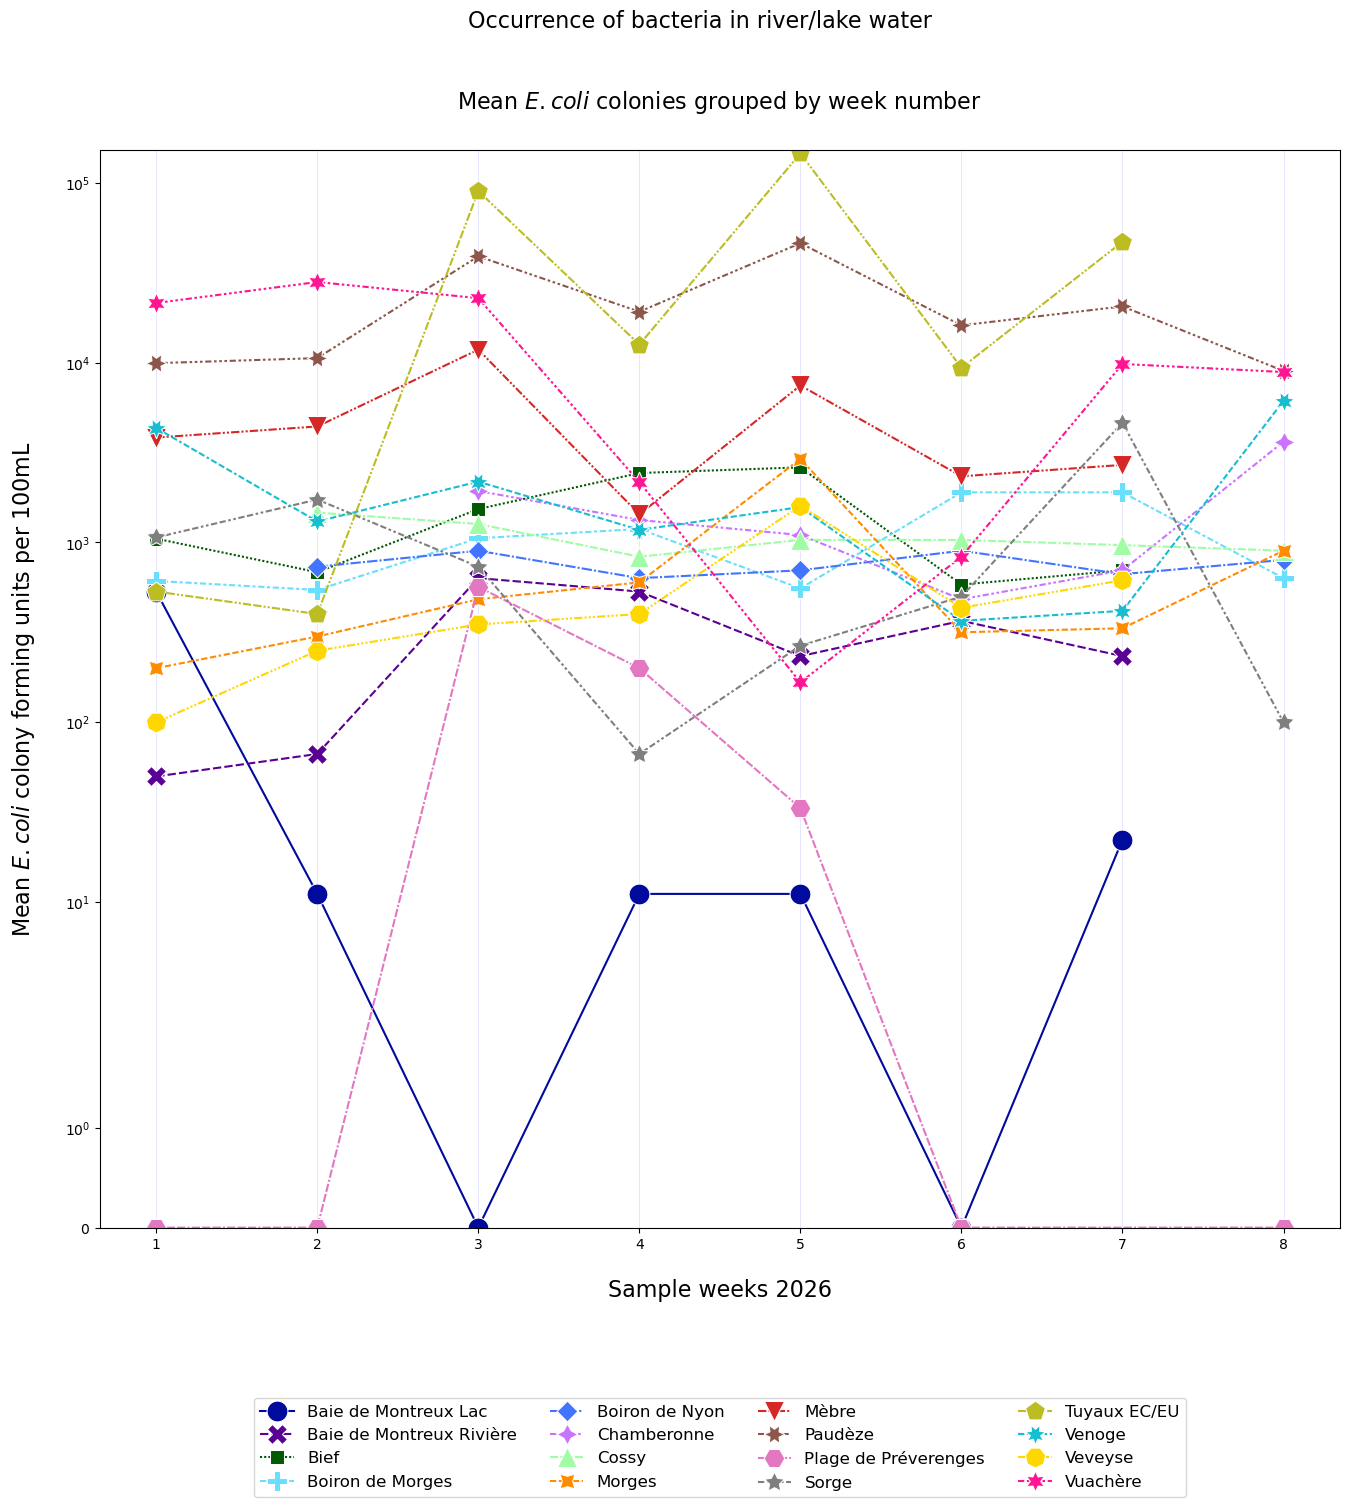

In [32]:
colors = [
    '#000A9C',  # dark blue
    '#5B0094',  # purple
    '#005903',  # dark green
    '#68DFFC',  # cyan
    '#4275FF',  # blue
    '#C973FF',  # light purple
    '#A2FCA5',  # light green
    '#FF8C00',  # orange
    '#D62728',  # red
    '#8C564B',  # brown
    '#E377C2',  # pink
    '#7F7F7F',  # grey
    '#BCBD22',  # olive
    '#17BECF',  # teal
    '#FFD700',  # gold
    '#FF1493'   # deep pink
]
fig, ax = plt.subplots(figsize=(16,14))

df_mean = (
    df.groupby(['Semaine', 'Rivière'], as_index=False)
      ['Nb colonies E. coli par 100 ml']
      .mean()
)

#df_mean_log = df_mean[df_mean['Nb colonies E. coli'] > 0]

#sns.scatterplot(
#    x='Semaine',
#    y='Nb colonies E. coli',
#    hue='Rivière',
#    data=df_mean, 
#    s=120,
#    style='Rivière',
#    palette=colors,
#    ax=ax
#)

sns.lineplot(
    x='Semaine',
    y="Nb colonies E. coli par 100 ml",
    hue='Rivière',
    data=df_mean,
    style='Rivière',
    markers=True,
    dashes=True,
    markersize=15,
    palette=colors,
    ax=ax
)

ax.set_yscale('symlog', linscale=1)
ax.set_ylim(bottom=0)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)
ax.set_xlabel("Sample weeks 2026", size=16, labelpad=20)

ax.set_ylabel(r"Mean $\it{E. coli}$ colony forming units per 100mL", size=16, labelpad=20)
plt.suptitle("Occurrence of bacteria in river/lake water" , fontsize=16, family='sans')
plt.title(r"Mean $\it{E. coli}$ colonies grouped by week number", fontsize=16, family='sans', y=1.03)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=12
);

/var/folders/2f/64mxbpb54jlcq8vg5f_p1ybm0000gn/T/ipykernel_99868/1782963321.py:18: UserWarning: The palette list has more values (16) than needed (12), which may not be intended.
  sns.lineplot(


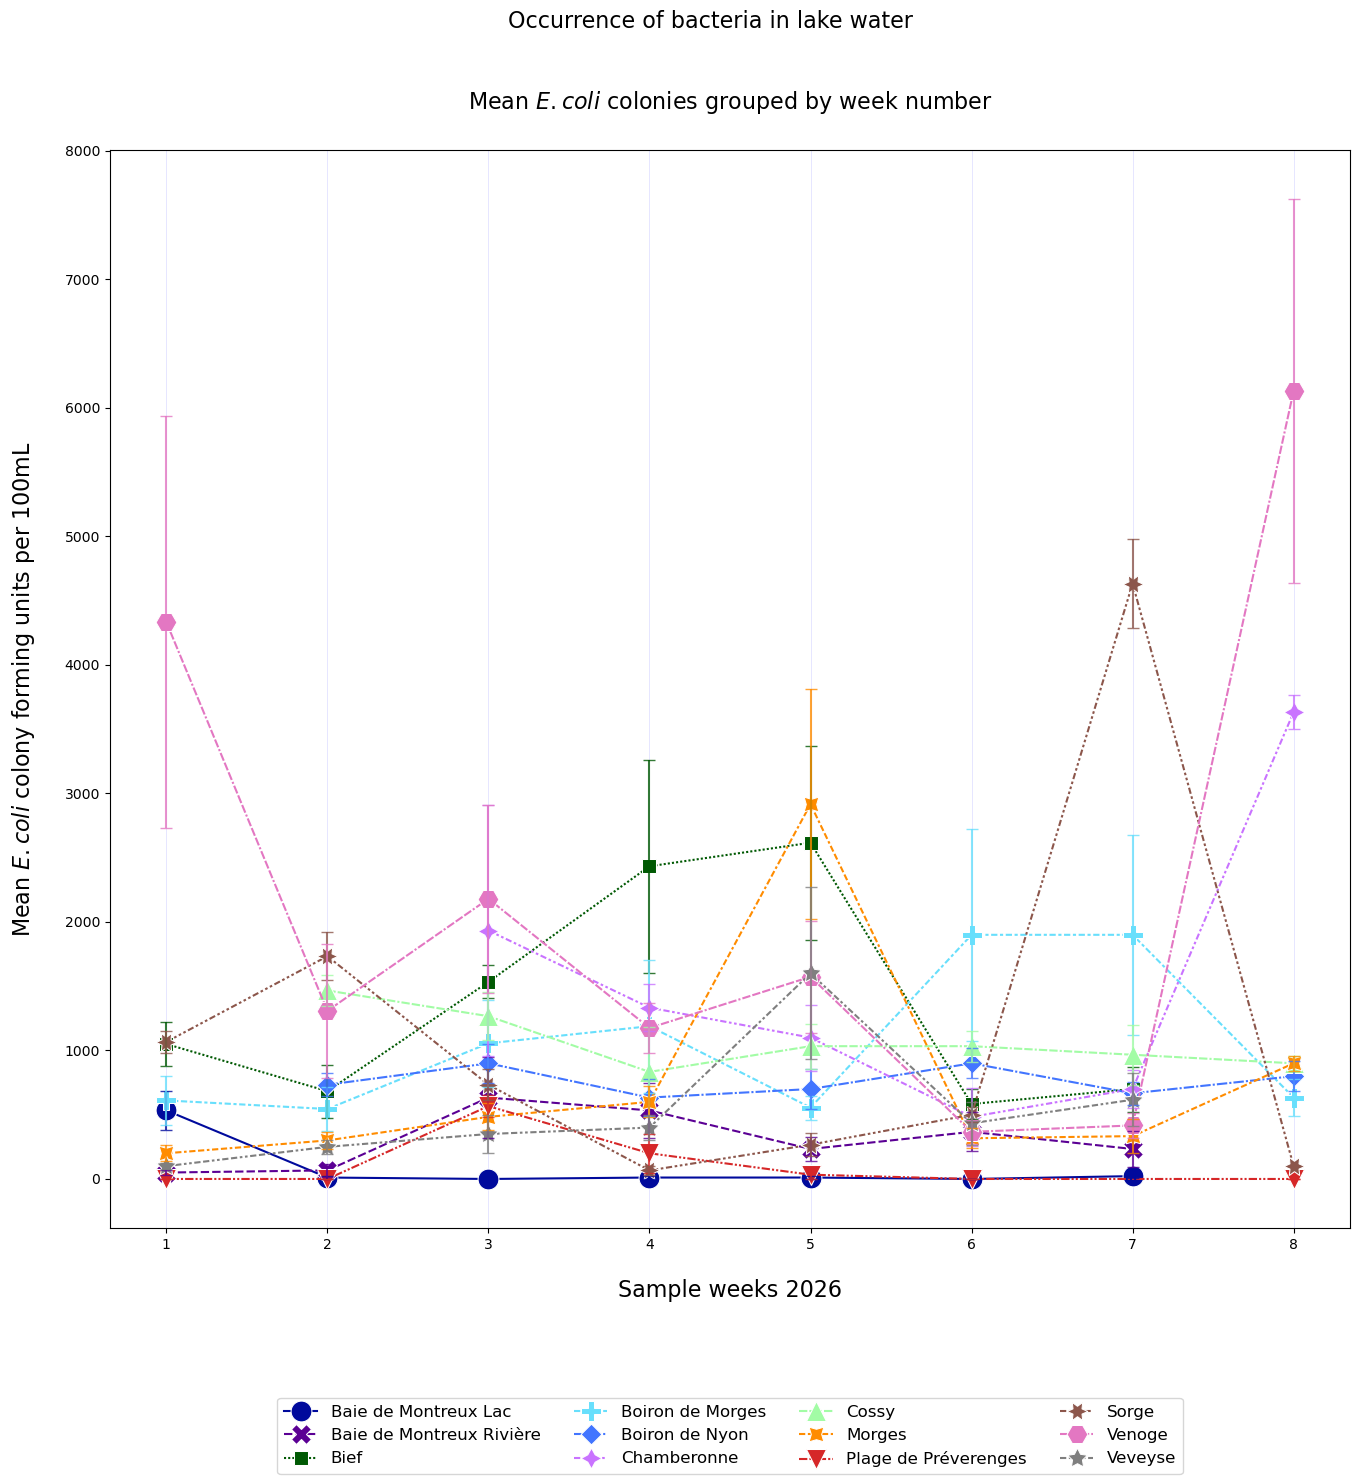

In [33]:
colors = [
    '#000A9C', '#5B0094', '#005903', '#68DFFC',
    '#4275FF', '#C973FF', '#A2FCA5', '#FF8C00',
    '#D62728', '#8C564B', '#E377C2', '#7F7F7F',
    '#BCBD22', '#17BECF', '#FFD700', '#FF1493'
]

fig, ax = plt.subplots(figsize=(16, 14))

df_wo_high_values = df[(df['Rivière'] != 'Tuyaux EC/EU') & (df['Rivière'] != 'Paudèze') & (df['Rivière'] != 'Vuachère')  & (df['Rivière'] != 'Mèbre')]

df_stats = (
    df_wo_high_values.groupby(['Semaine', 'Rivière'])['Nb colonies E. coli par 100 ml']
      .agg(['mean', 'sem'])
      .reset_index()
)

sns.lineplot(
    x='Semaine',
    y='mean',
    hue='Rivière',
    data=df_stats,
    style='Rivière',
    markers=True,
    dashes=True,
    markersize=15,
    palette=colors,
    ax=ax
)

rivieres = df_stats['Rivière'].unique()

for i, riviere in enumerate(rivieres):
    subset = df_stats[df_stats['Rivière'] == riviere]

    ax.errorbar(
        subset['Semaine'],
        subset['mean'],
        yerr=subset['sem'],
        fmt='none',
        ecolor=colors[i],
        elinewidth=1.5,
        capsize=4,
        alpha=0.8
    )

#ax.set_yscale('symlog', linscale=1)
#ax.set_ylim(bottom=0)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)

ax.set_xlabel(
    "Sample weeks 2026",
    size=16,
    labelpad=20
)

ax.set_ylabel(
    r"Mean $\it{E. coli}$ colony forming units per 100mL",
    size=16,
    labelpad=20
)

plt.suptitle(
    "Occurrence of bacteria in lake water",
    fontsize=16,
    family='sans'
)

plt.title(
    r"Mean $\it{E. coli}$ colonies grouped by week number",
    fontsize=16,
    family='sans',
    y=1.03
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=12
);

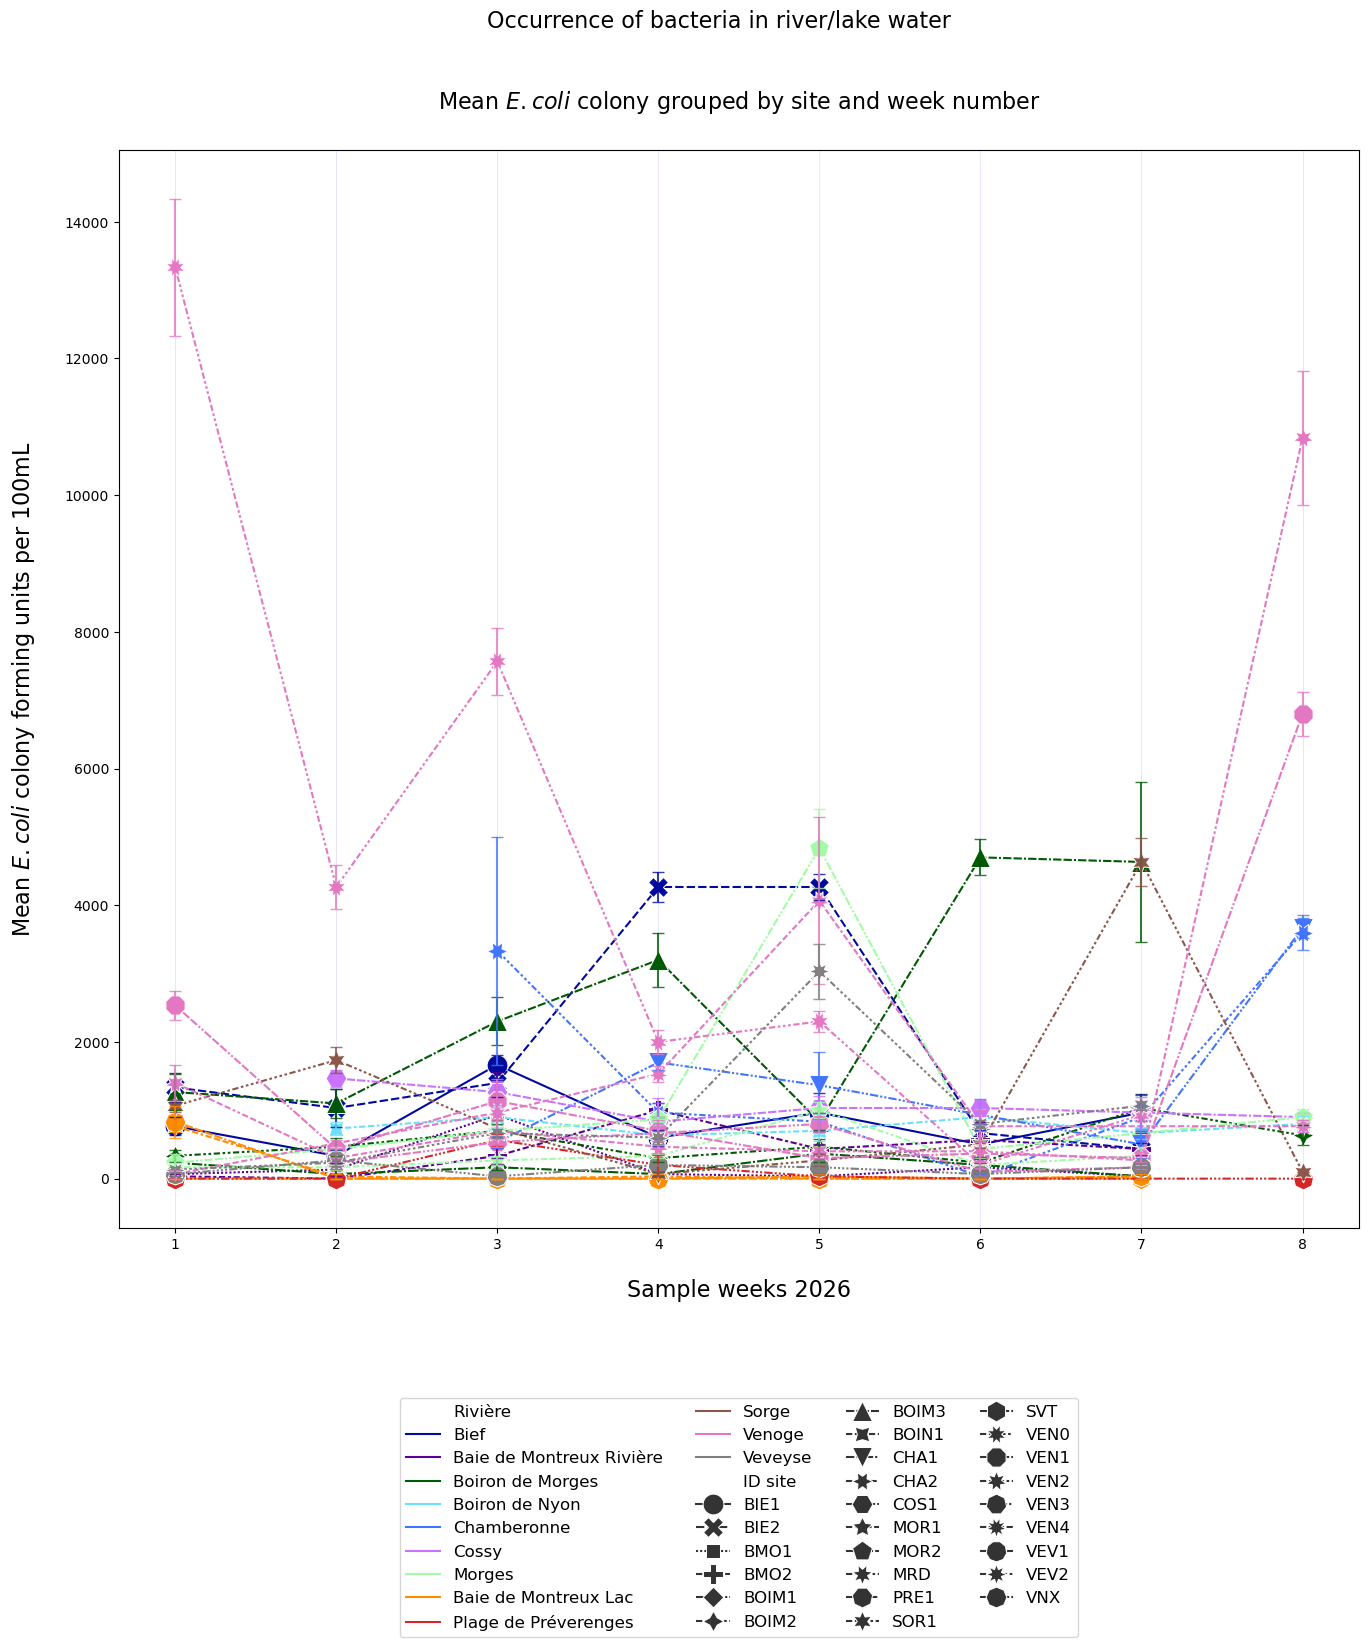

In [34]:
colors = [
    '#000A9C', '#5B0094', '#005903', '#68DFFC',
    '#4275FF', '#C973FF', '#A2FCA5', '#FF8C00',
    '#D62728', '#8C564B', '#E377C2', '#7F7F7F',
    '#BCBD22', '#17BECF', '#FFD700', '#FF1493'
]

fig, ax = plt.subplots(figsize=(16, 14))

df_wo_high_values = df[
    ~df['Rivière'].isin([
        'Tuyaux EC/EU',
        'Paudèze',
        'Vuachère',
        'Mèbre'
    ])
]

# Mean + SEM for each SITE, each week
df_stats = (
    df_wo_high_values
    .groupby(['Semaine', 'ID site', 'Rivière'])[
        'Nb colonies E. coli par 100 ml'
    ]
    .agg(['mean', 'sem'])
    .reset_index()
)

# One color per river
rivieres = df_stats['Rivière'].unique()

river_colors = {
    riviere: colors[i]
    for i, riviere in enumerate(rivieres)
}

sns.lineplot(
    data=df_stats,
    x='Semaine',
    y='mean',
    hue='Rivière',       # same color for sites of same river
    style='ID site',     # different marker/style for each site
    markers=True,
    dashes=True,
    markersize=15,
    palette=river_colors,
    ax=ax
)

for site, subset in df_stats.groupby('ID site'):

    riviere = subset['Rivière'].iloc[0]

    ax.errorbar(
        subset['Semaine'],
        subset['mean'],
        yerr=subset['sem'],
        fmt='none',
        ecolor=river_colors[riviere],
        elinewidth=1.5,
        capsize=4,
        alpha=0.8
    )

ax.xaxis.grid(
    which="major",
    color='b',
    linewidth=0.7,
    alpha=0.1
)

ax.set_xlabel(
    "Sample weeks 2026",
    size=16,
    labelpad=20
)

ax.set_ylabel(
    r"Mean $\it{E. coli}$ colony forming units per 100mL",
    size=16,
    labelpad=20
)

plt.suptitle(
    "Occurrence of bacteria in river/lake water",
    fontsize=16,
    family='sans'
)

plt.title(
    r"Mean $\it{E. coli}$ colony grouped by site and week number",
    fontsize=16,
    family='sans',
    y=1.03
)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    fontsize=12
);

### 3.3. Comparative Analysis Rivers vs. Lakes vs. Tube

In [35]:
high_rivers = ['Vuachère', 'Venoge', 'Paudèze', 'Mèbre']
tuyaux = ['Tuyaux EC/EU']
lakes = ['Baie de Montreux Lac']
other_rivers = [
    r for r in df['Rivière'].dropna().unique()
    if r not in high_rivers + tuyaux + lakes
]

Function to plot bioindicators in water vs. weather data:

In [36]:
def plot_specific_river_by_site_dynamic(
    data,
    daily_weather,
    bacteria,
    bacteria_name,
    weather_metric,
    weather_indicator_name,
    river
):
    fig, ax = plt.subplots(figsize=(16, 10))

    # --------------------------------------------------
    # Bacteria
    # --------------------------------------------------

    data_river = data[data['Rivière'] == river]

    df_stats = (
        data_river
        .groupby(['Semaine', 'ID site'])[bacteria]
        .agg(['mean', 'sem'])
        .reset_index()
    )

    sites = sorted(df_stats['ID site'].unique())

    palette = sns.color_palette(
        "viridis",
        n_colors=len(sites)
    )

    site_colors = {
        site: palette[i]
        for i, site in enumerate(sites)
    }

    sns.scatterplot(
        data=df_stats,
        x='Semaine',
        y='mean',
        hue='ID site',
        style='ID site',
        palette=site_colors,
        s=180,
        ax=ax
    )

    # SEM
    for site, subset in df_stats.groupby('ID site'):
        ax.errorbar(
            subset['Semaine'],
            subset['mean'],
            yerr=subset['sem'],
            fmt='none',
            ecolor=site_colors[site],
            elinewidth=1.5,
            capsize=4,
            alpha=0.8
        )

    # --------------------------------------------------
    # Daily weather
    # --------------------------------------------------

    ax_weather = ax.twinx()

    # 7 positions inside each week
    day_offsets = np.linspace(-0.36, 0.36, 7)
    bar_width = 0.10

    for week in range(1, 9):

        start_date = (
            pd.Timestamp('2026-06-15')
            + pd.Timedelta(weeks=week - 1)
        )

        dates = pd.date_range(
            start=start_date,
            periods=7,
            freq='D'
        )

        # Weather columns corresponding to the sites
        weather_columns = [
            f"{site}.{weather_metric}"
            for site in sites
            if f"{site}.{weather_metric}" in daily_weather.columns
        ]

        if not weather_columns:
            continue

        # Daily mean across the sites of the river
        weather_week = (
            daily_weather
            .reindex(dates)[weather_columns]
            .mean(axis=1)
        )

        x_positions = week + day_offsets

        ax_weather.bar(
            x_positions,
            weather_week.values,
            width=bar_width,
            alpha=0.20,
            color=weather_color,
            label=weather_indicator_name if week == 1 else None
        )

    ax_weather.set_ylabel(
        weather_indicator_name,
        size=16,
        labelpad=20
    )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    # Keep bacteria points in front of weather bars
    ax.set_zorder(2)
    ax_weather.set_zorder(1)
    ax.patch.set_visible(False)

    ax.xaxis.grid(
        which="major",
        linewidth=0.7,
        alpha=0.1
    )

    ax.set_xticks(range(1, 9))

    ax.set_xlabel(
        "Sample weeks 2026 (15.06. - 09.08.)",
        size=16,
        labelpad=20
    )

    ax.set_ylabel(
        r"Mean " + bacteria_name +
        " colony forming units per 100mL",
        size=16,
        labelpad=20
    )

    plt.title(
        "Occurrence of bacteria in river water: " + river,
        fontsize=16,
        y=1.03
    )

    # Combined legend
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax_weather.get_legend_handles_labels()

    ax.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        fontsize=12
    )

    plt.show()

In [37]:
def generate_plots_for_rivers(rivers_list):
    for r in rivers_list:
        for bi in [{
            "column": "Nb colonies E. coli par 100 ml",
            "label": r"$\it{E. coli}$"
        },
        {
            "column": "Nb colonies coliformes par 100 ml",
            "label": "coliform"
        }]:
            for wi in [{
                "column": "SOM.PREC",
                "label": "Rain (mm)"
            },
            {
                "column": "MOY.TEMP",
                "label": "Mean Temperature (°C)"
            }]:
                plot_specific_river_by_site_dynamic(
                    df,
                    df_daily_weather,
                    bi["column"],
                    bi["label"],
                    wi["column"],
                    wi["label"],
                    r
                )

#### 3.3.1. Tube 

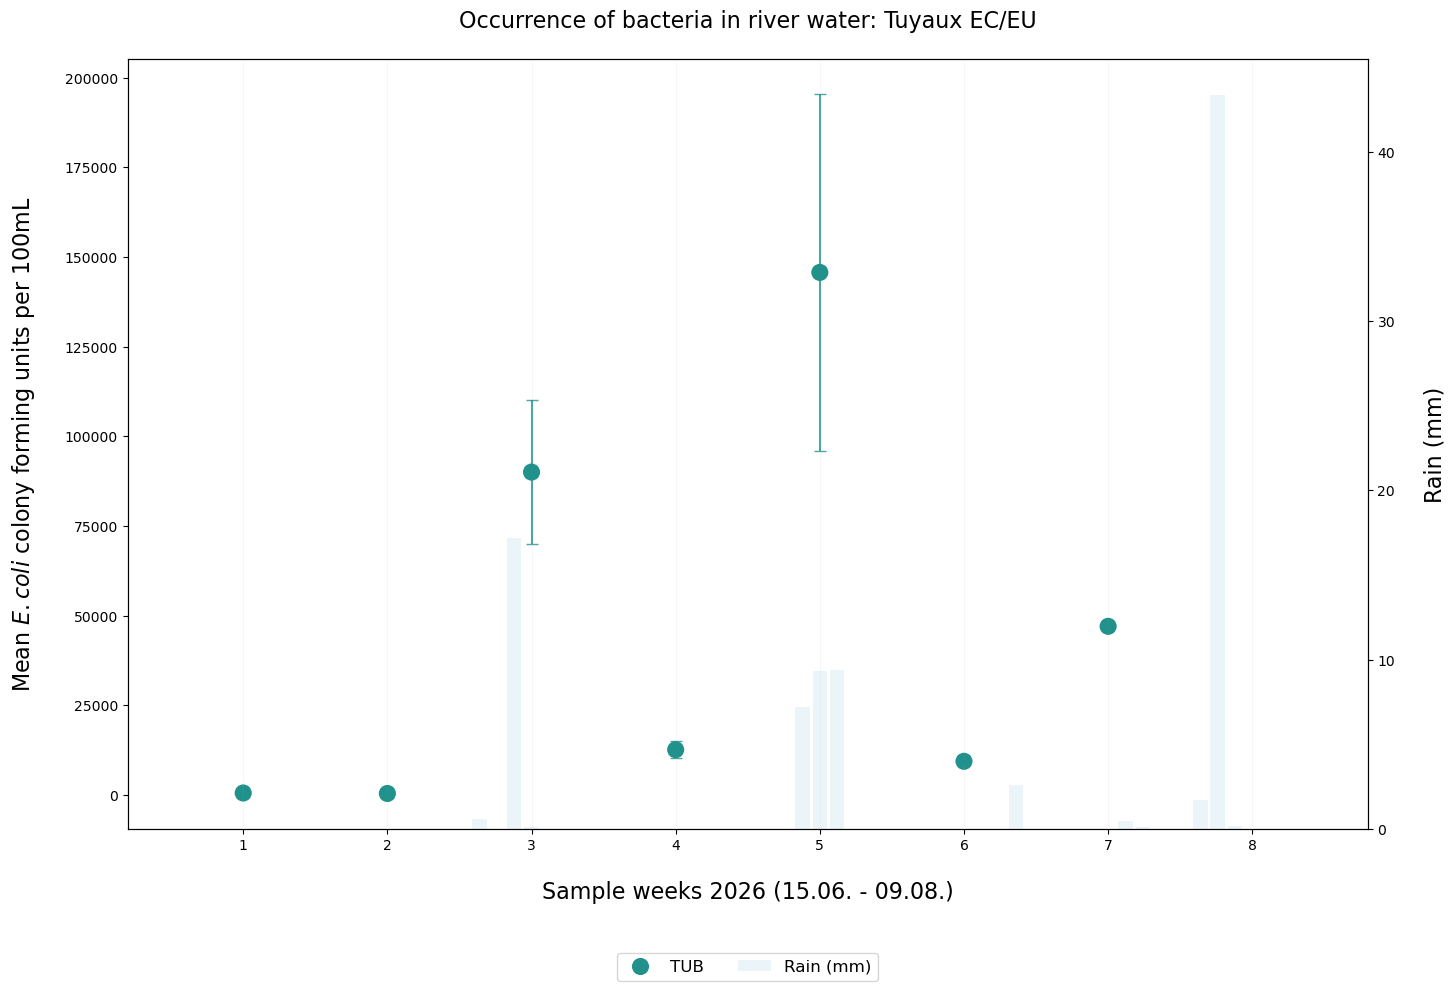

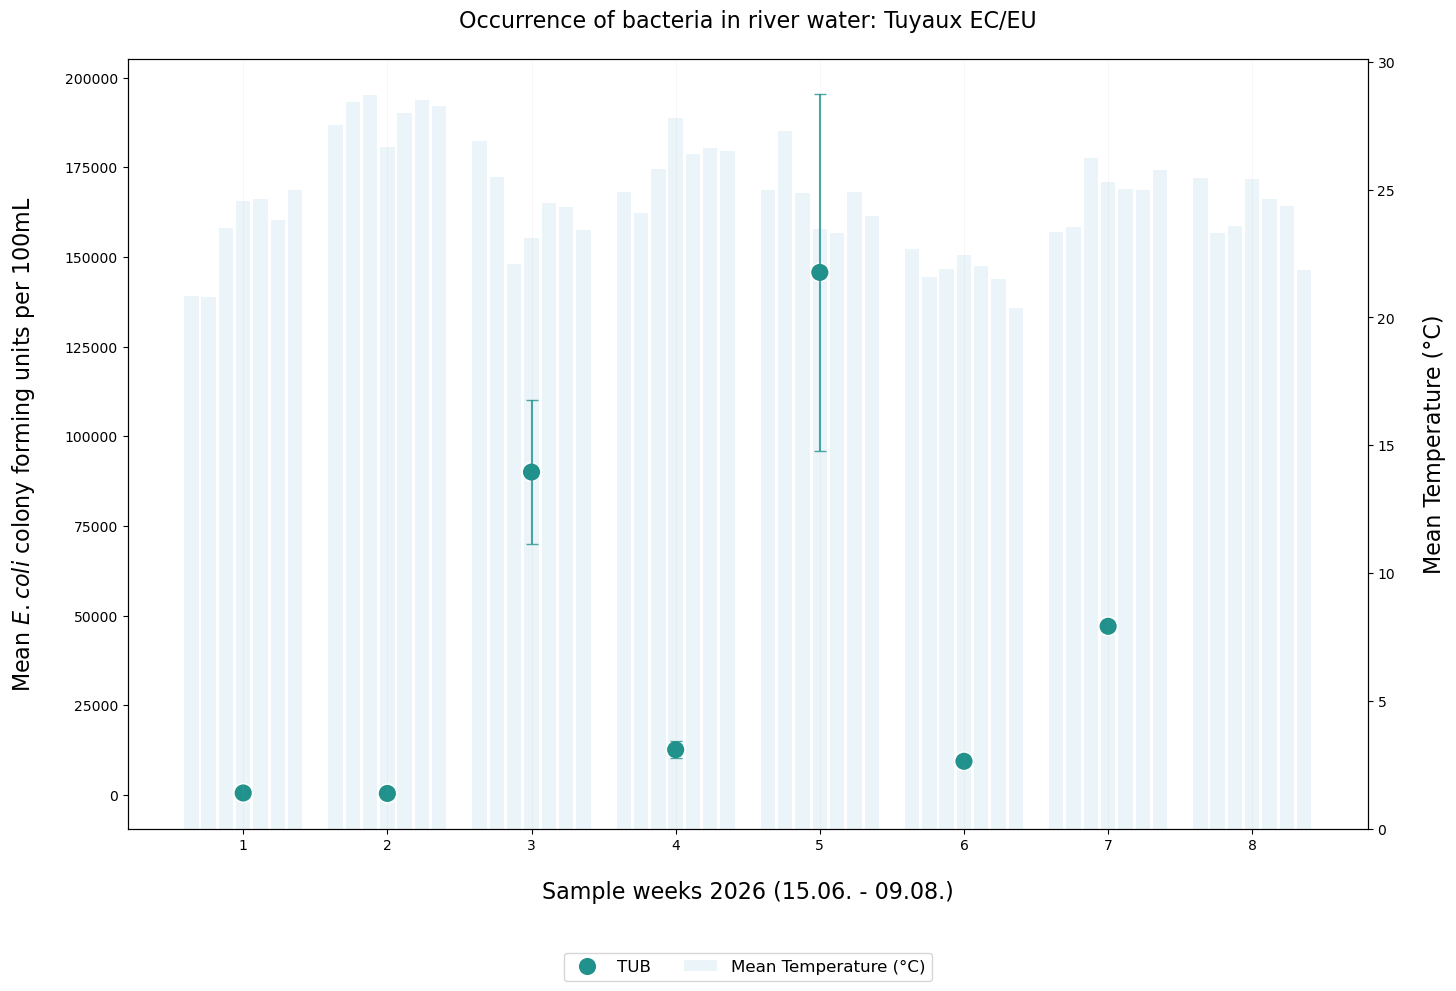

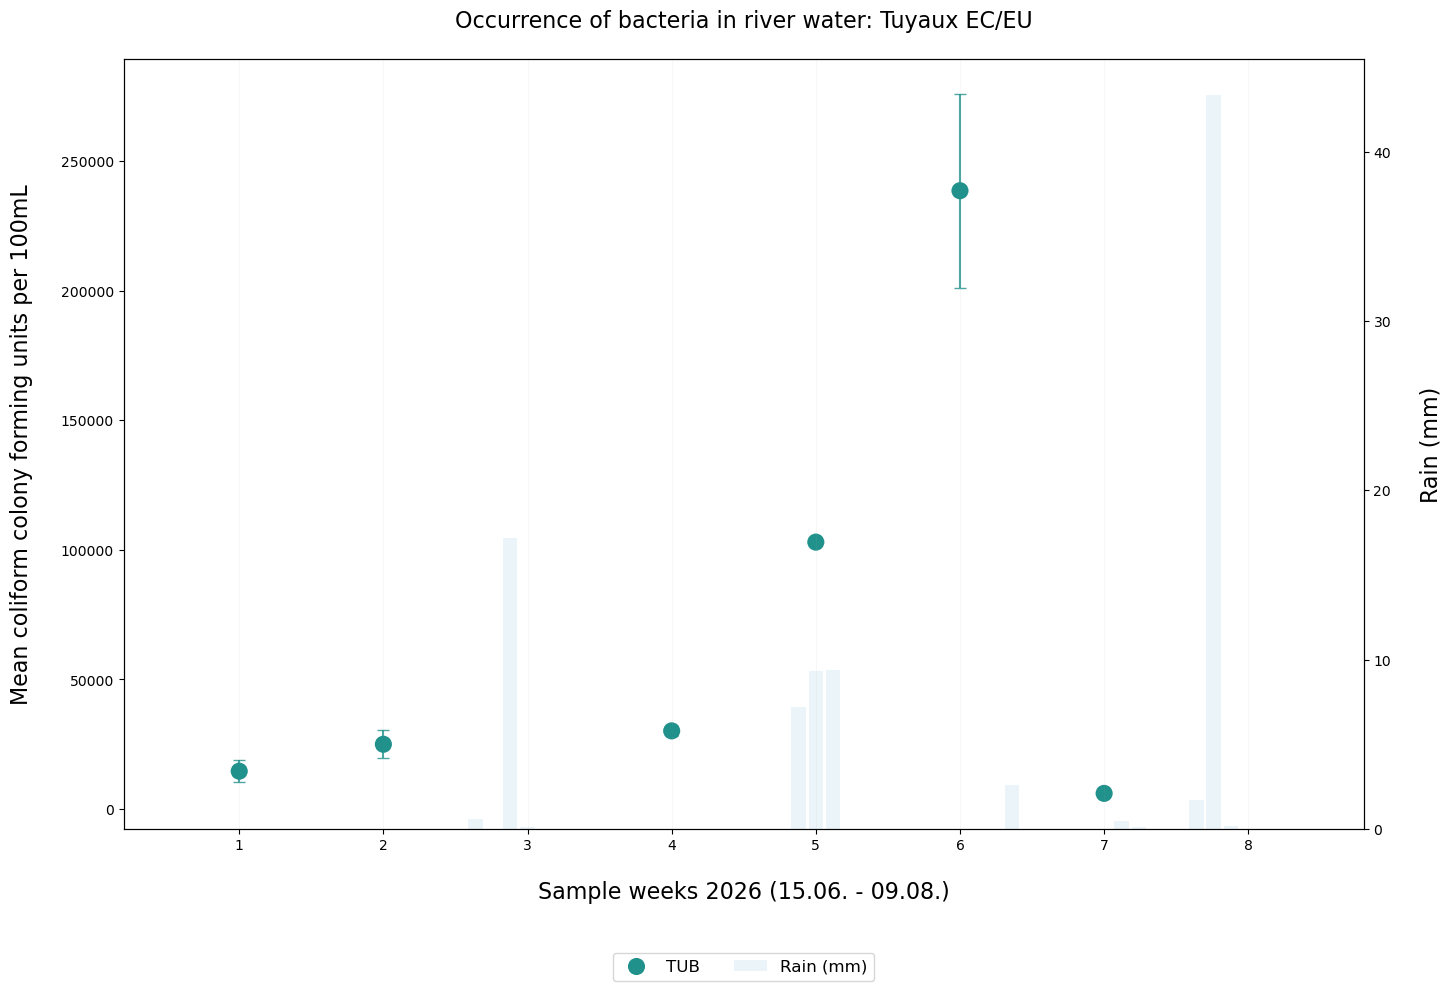

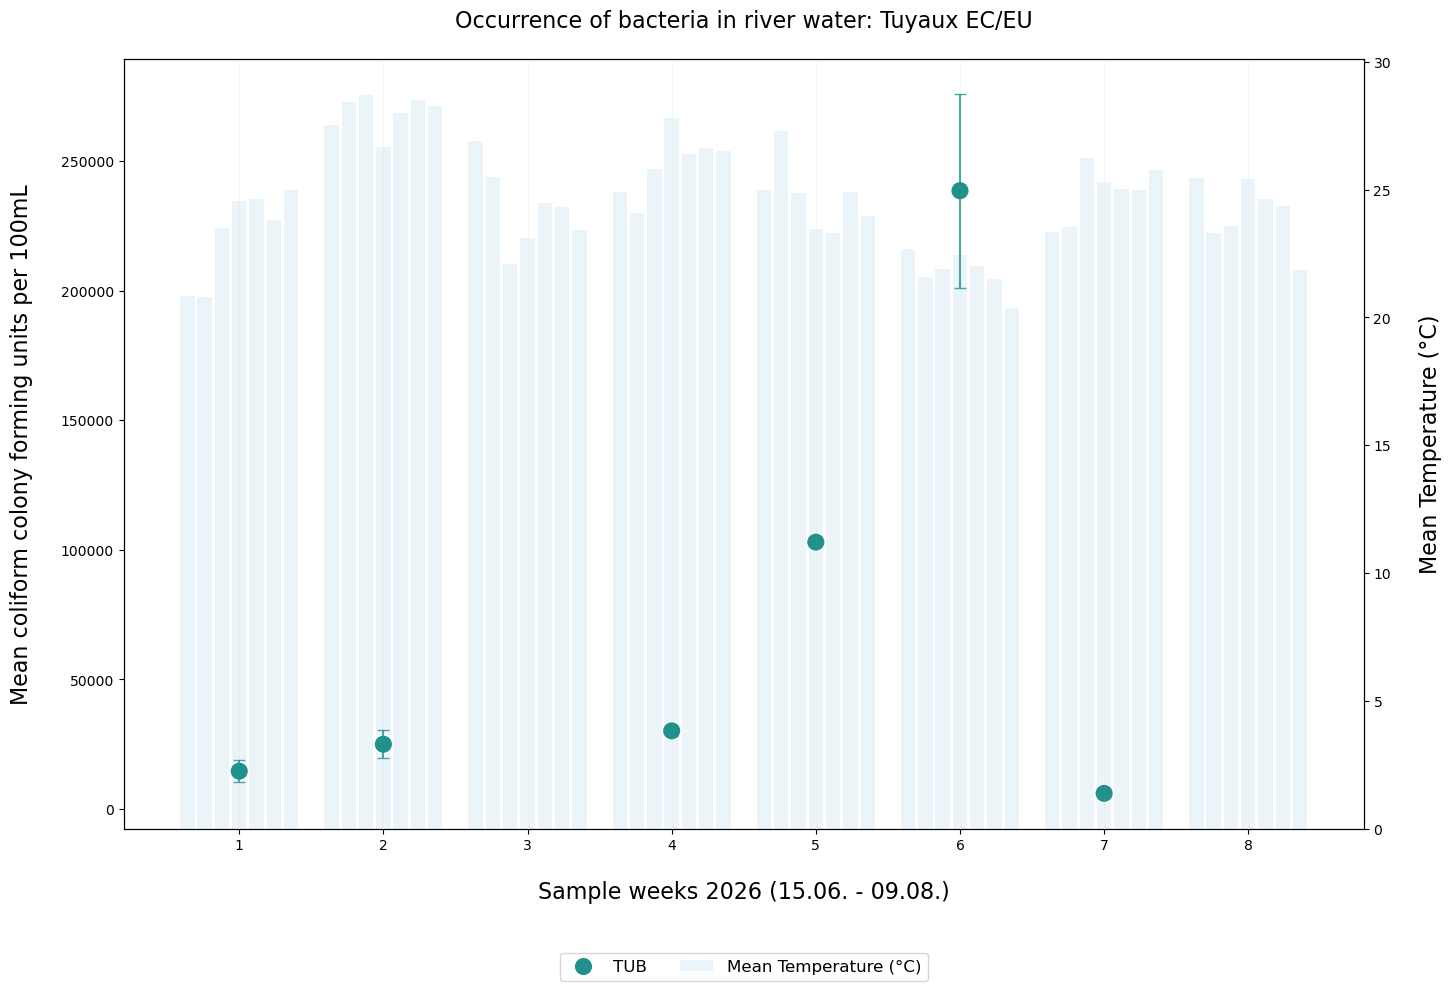

In [38]:
generate_plots_for_rivers(tuyaux)

#### 3.3.2. Lakes

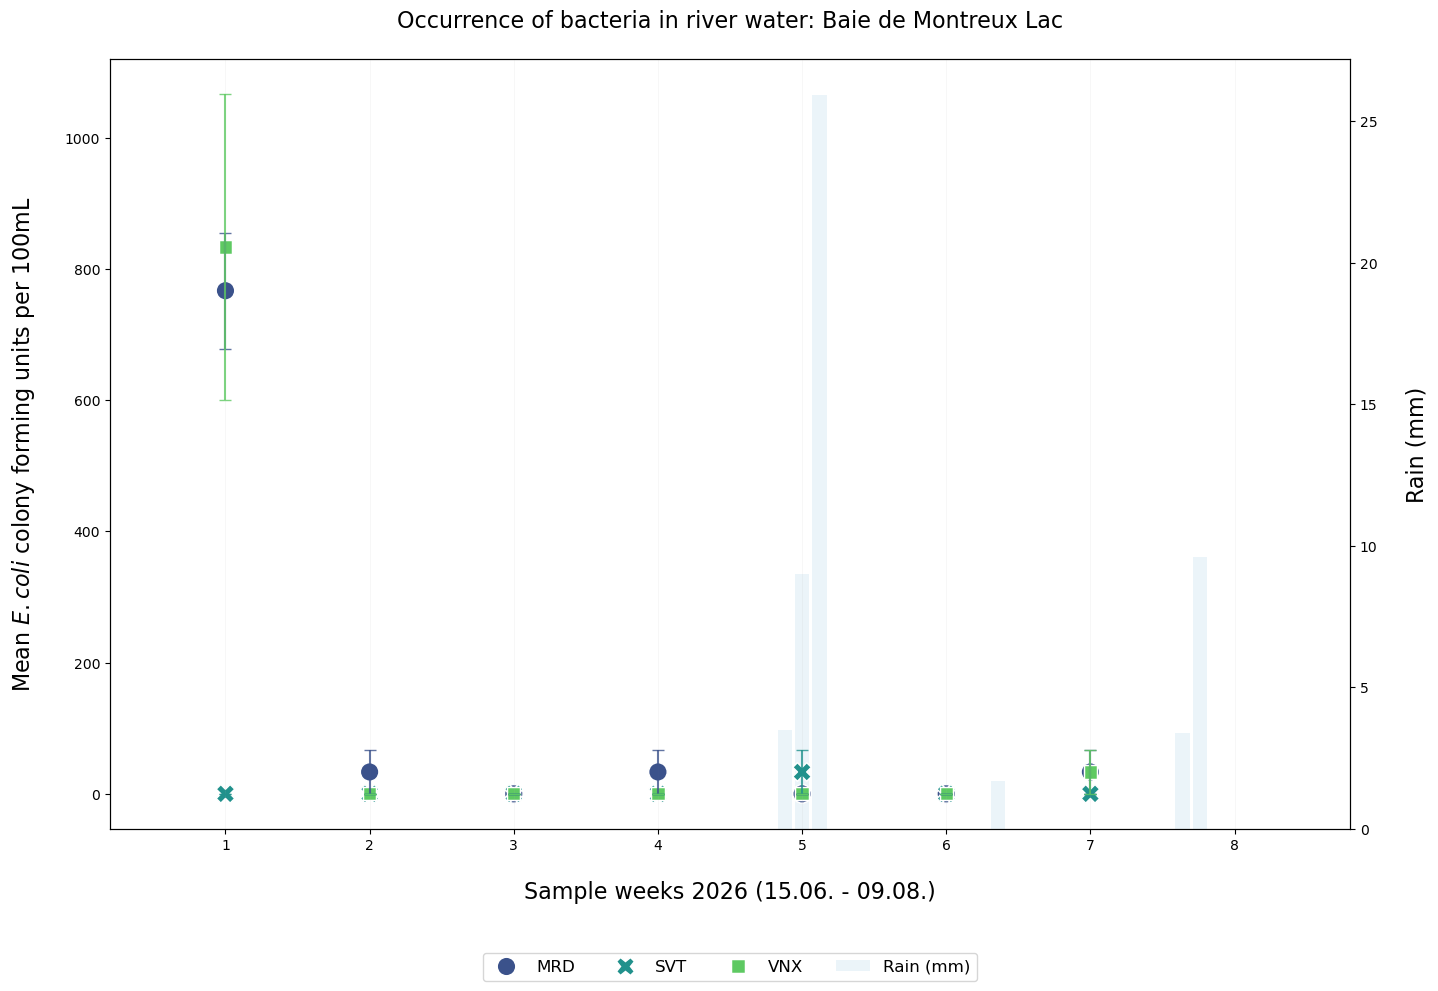

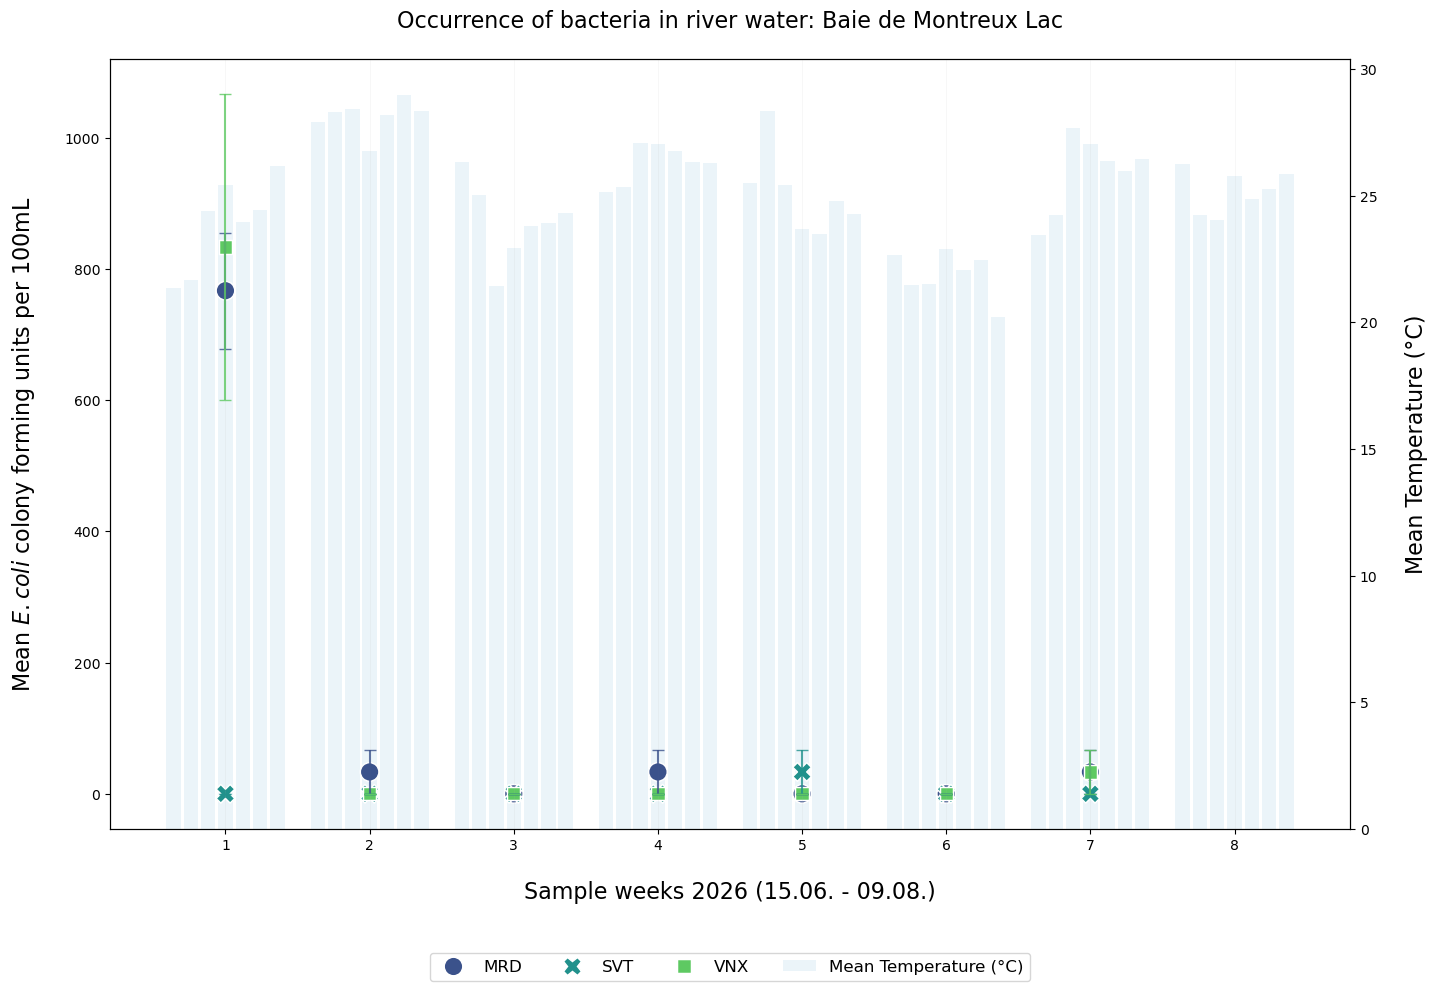

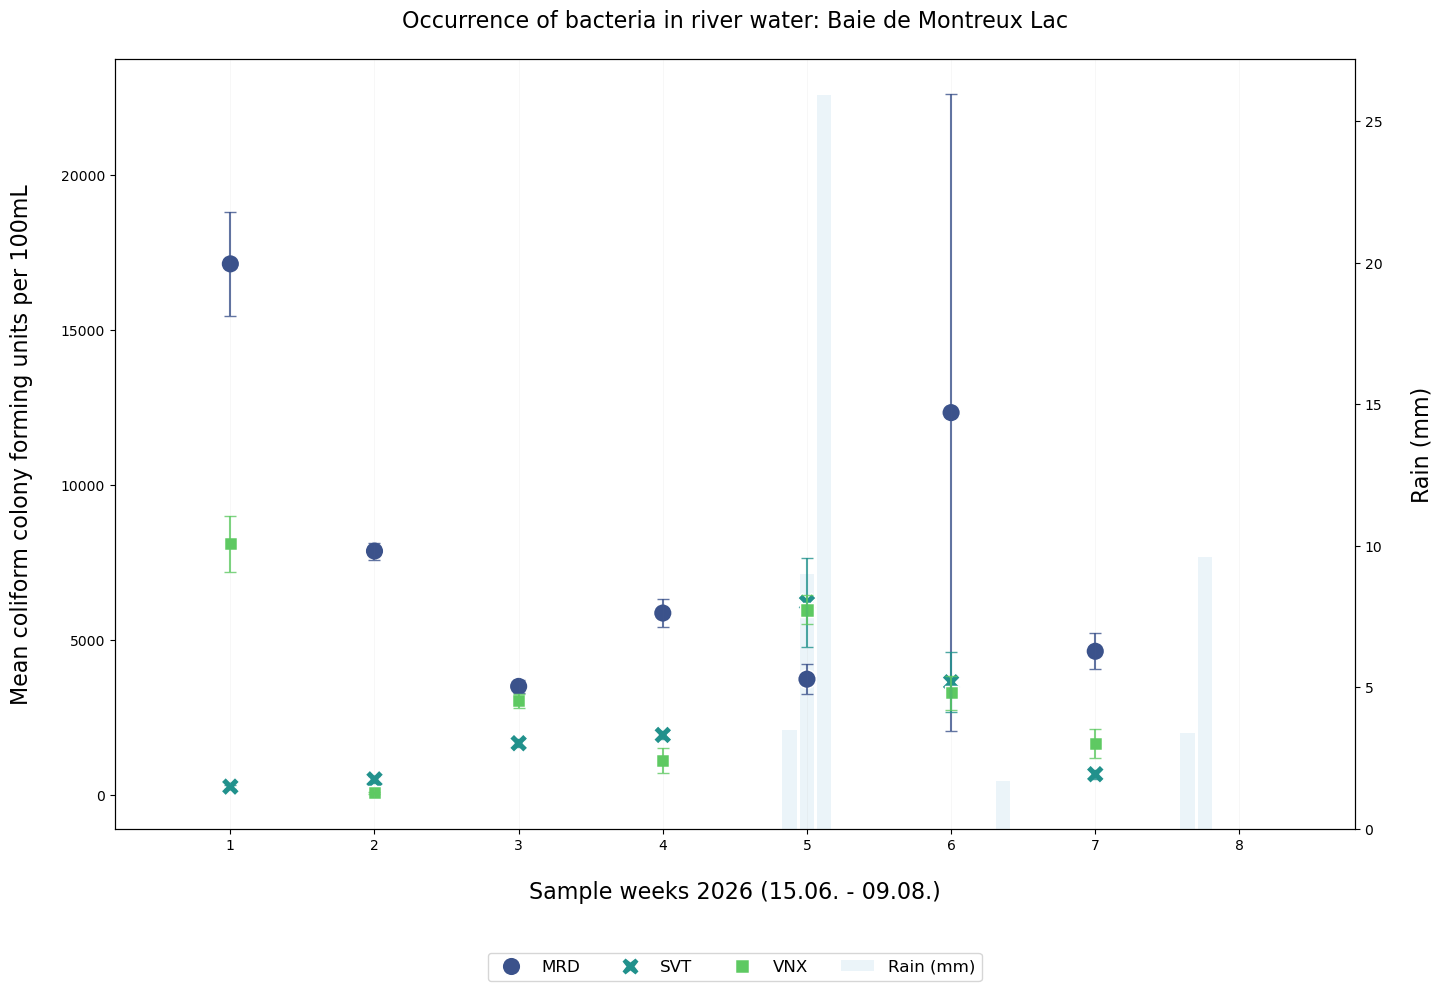

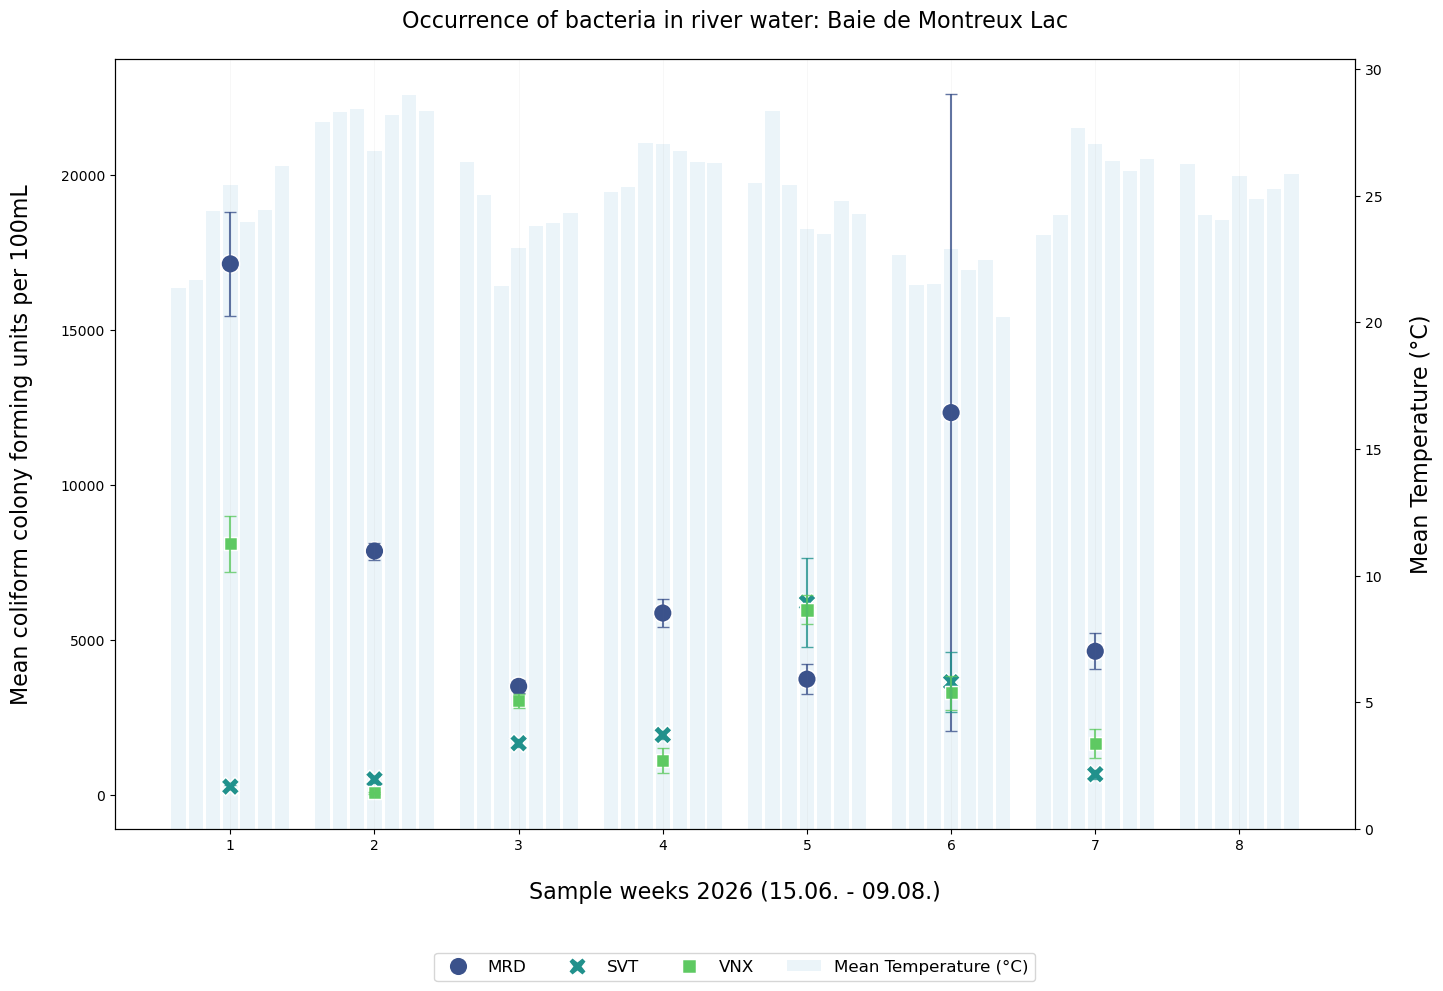

In [39]:
generate_plots_for_rivers(lakes)

#### 3.3.3. Rivers with High Concentration of Bioindicators

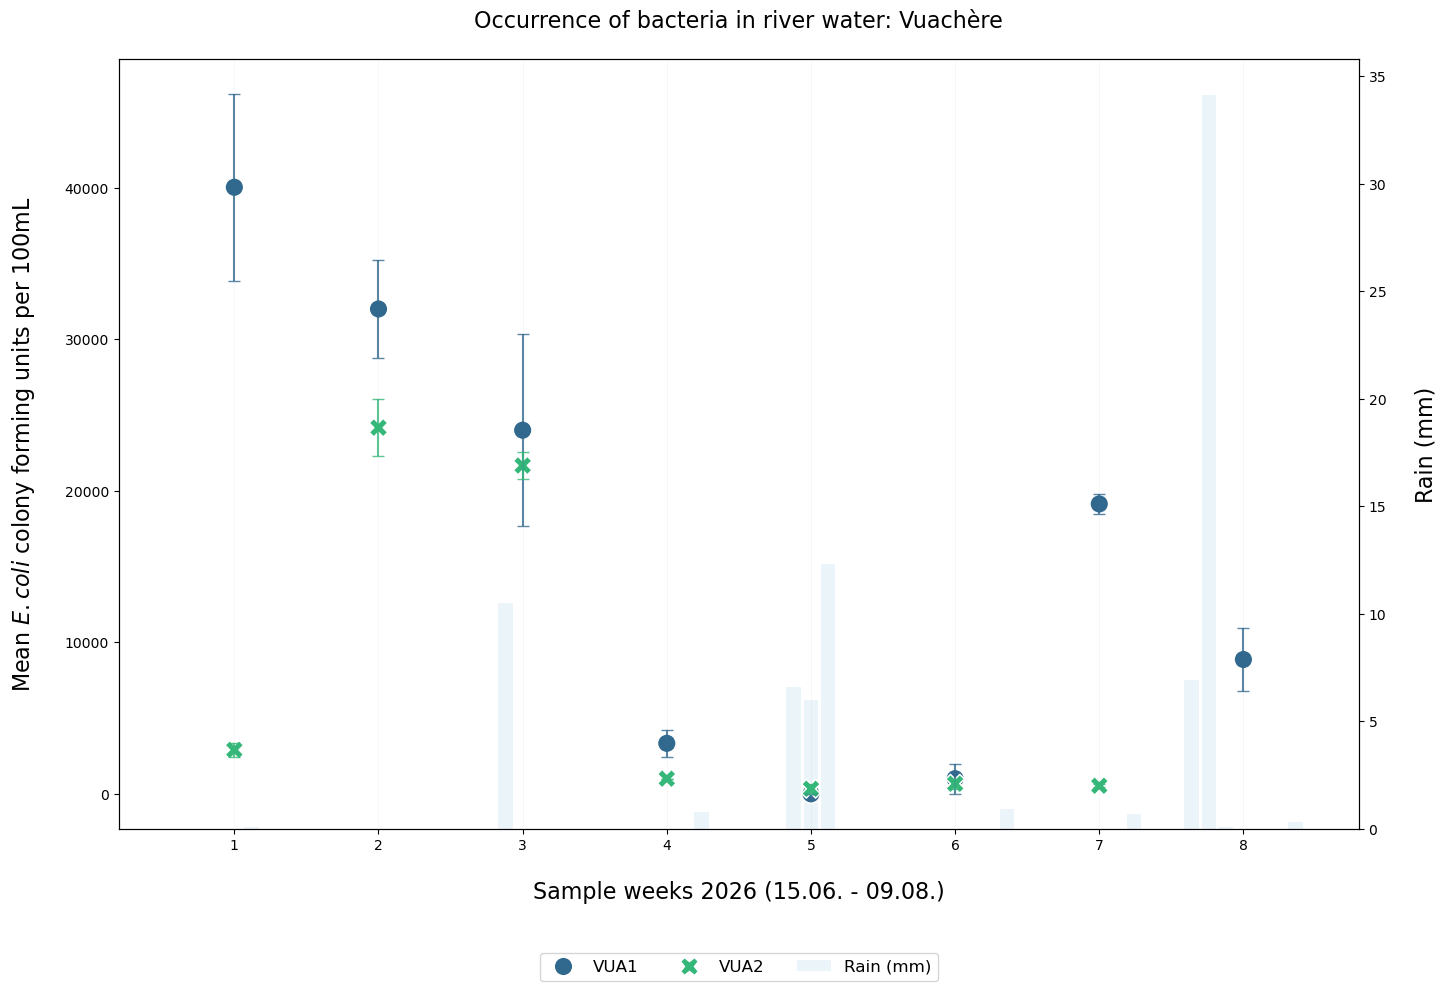

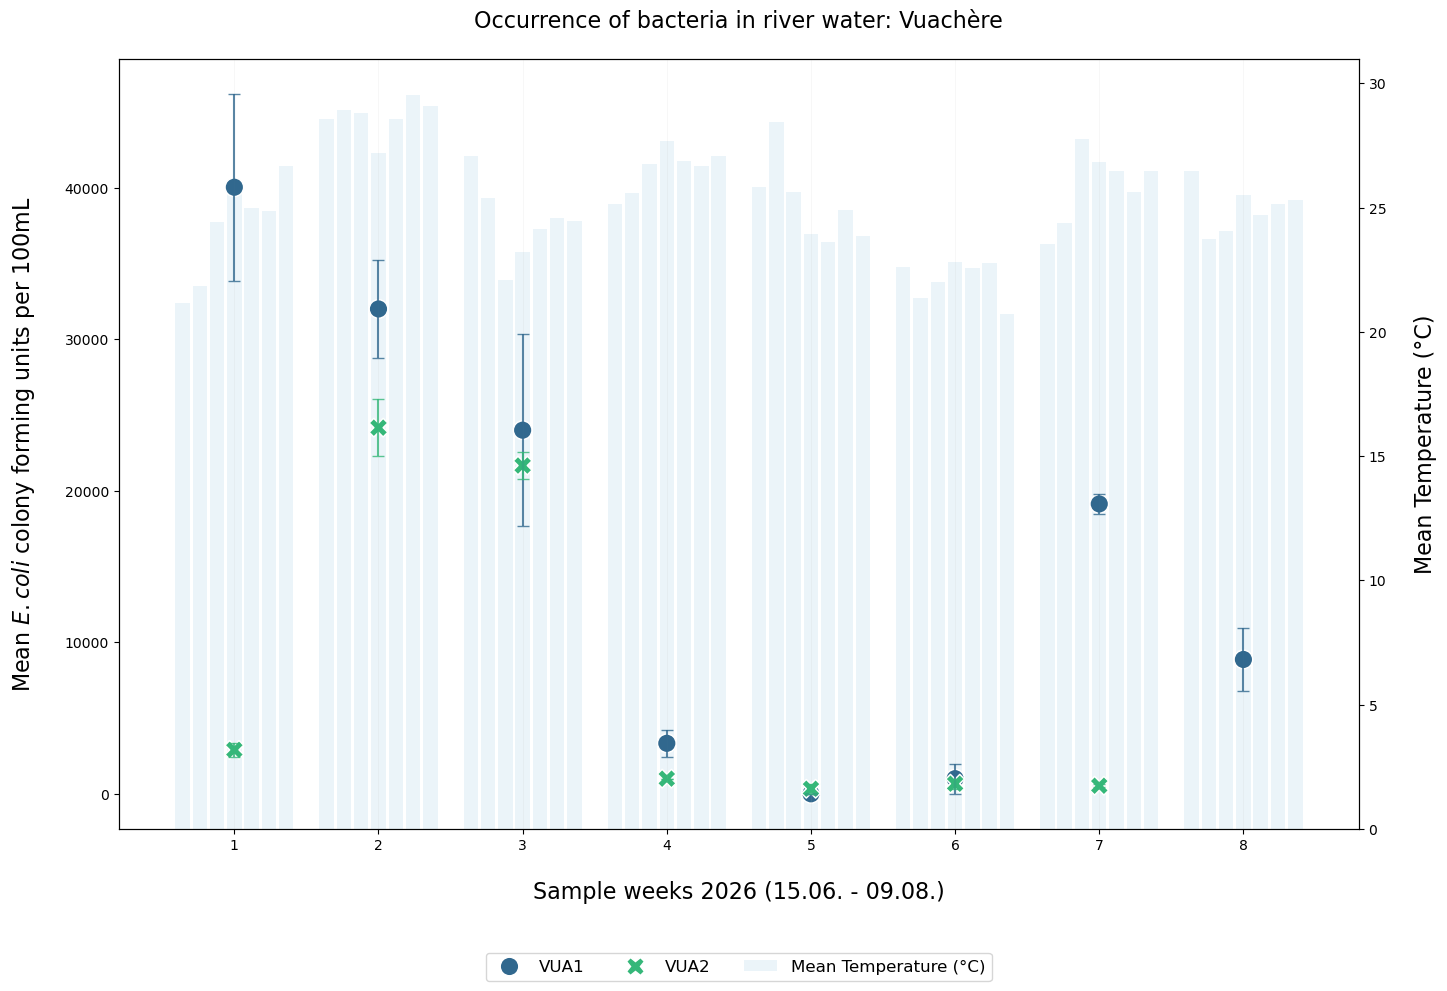

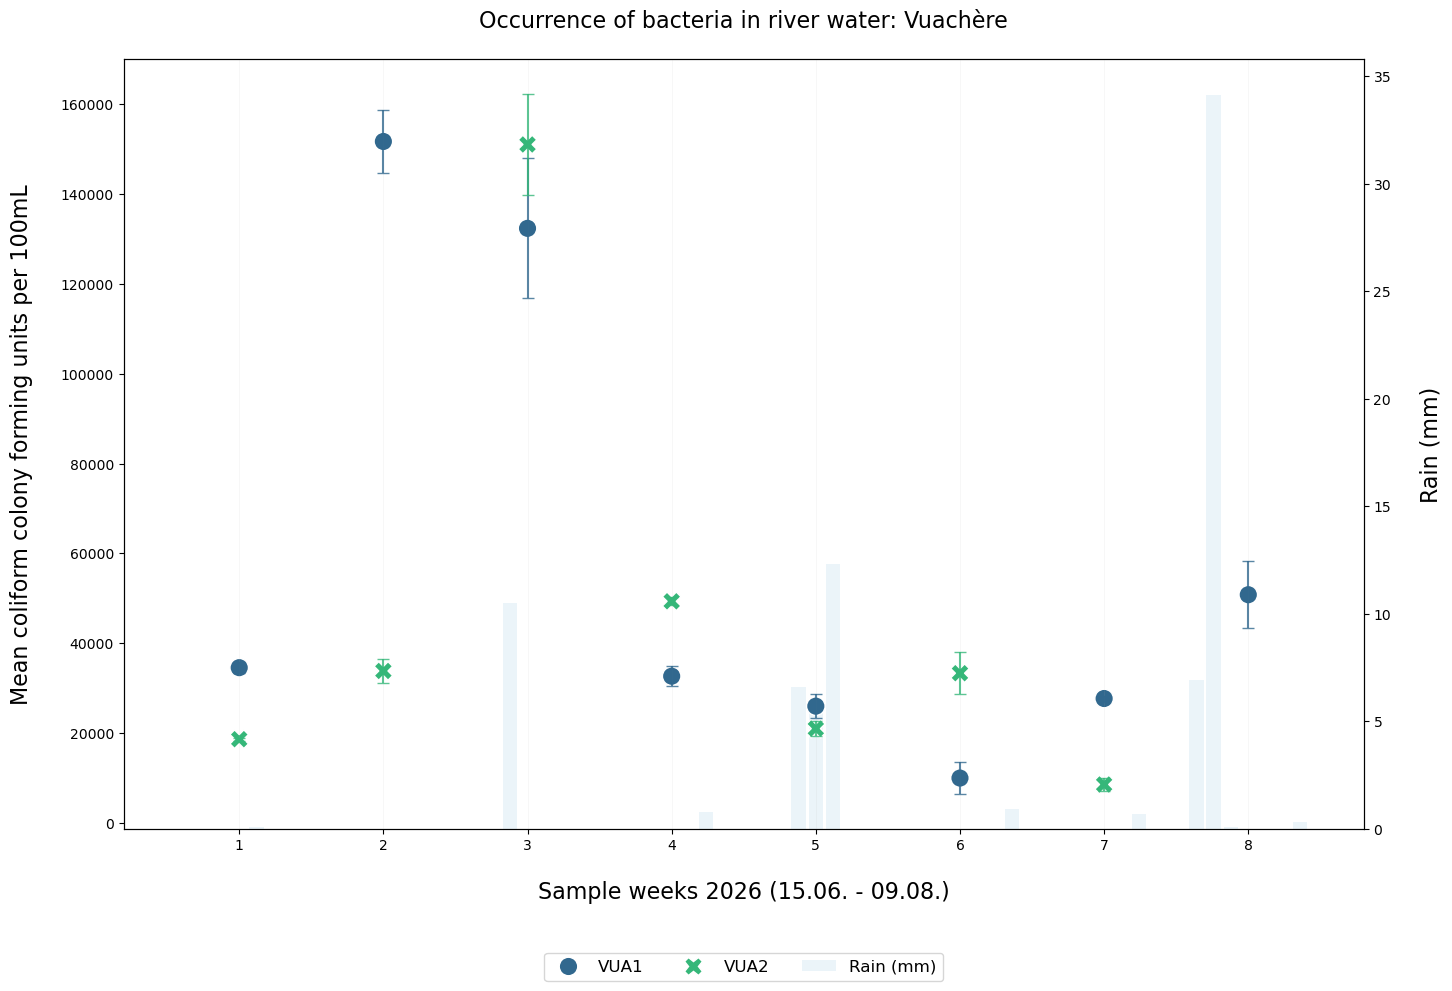

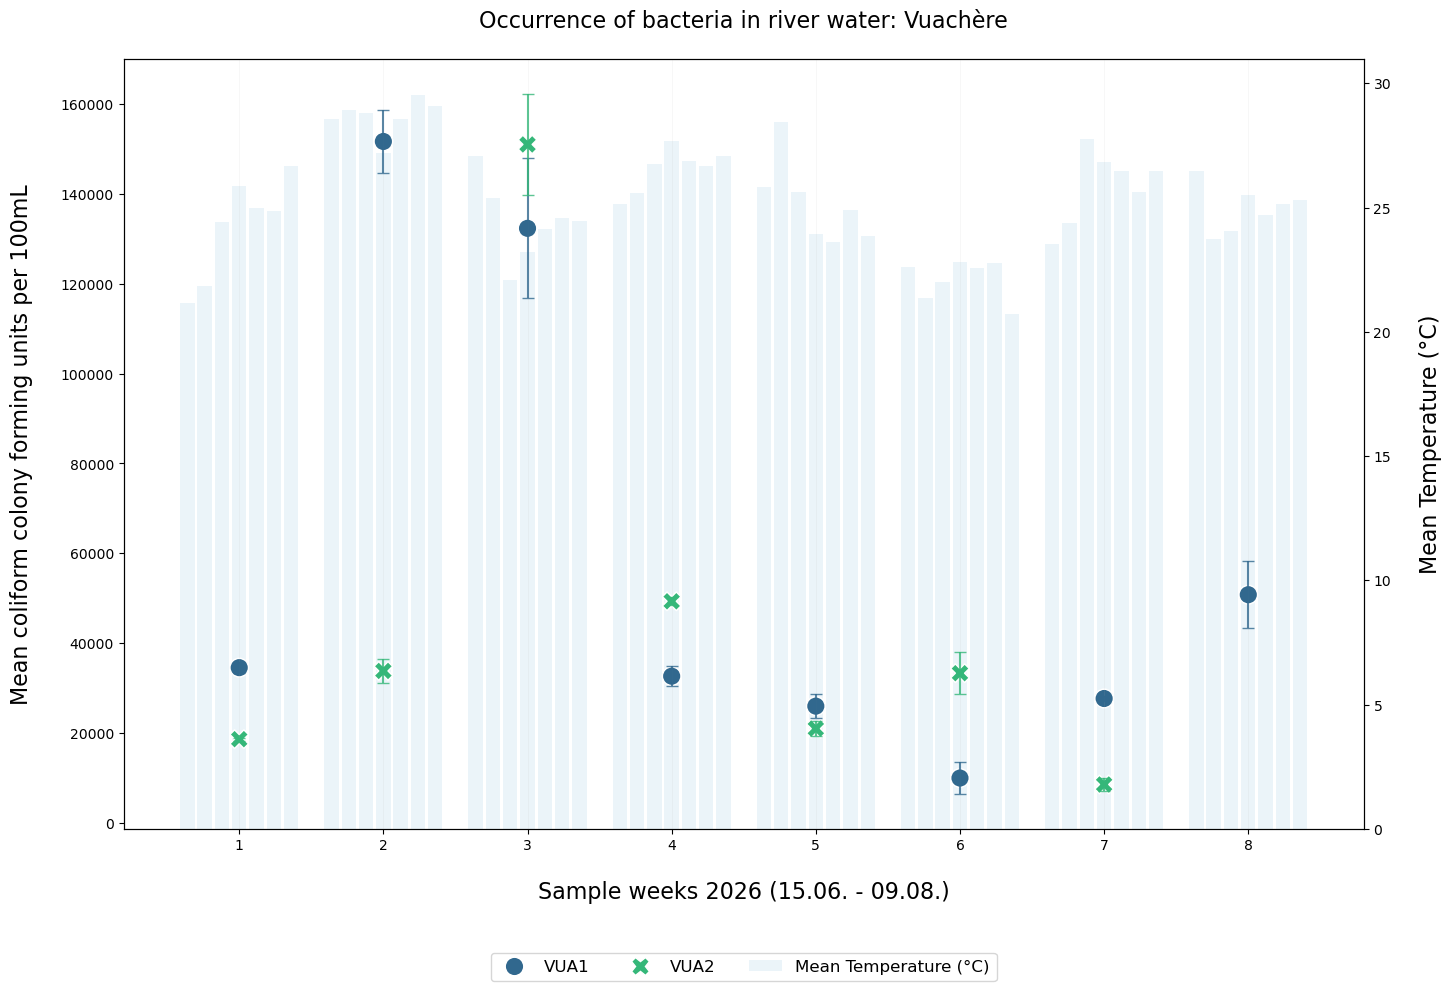

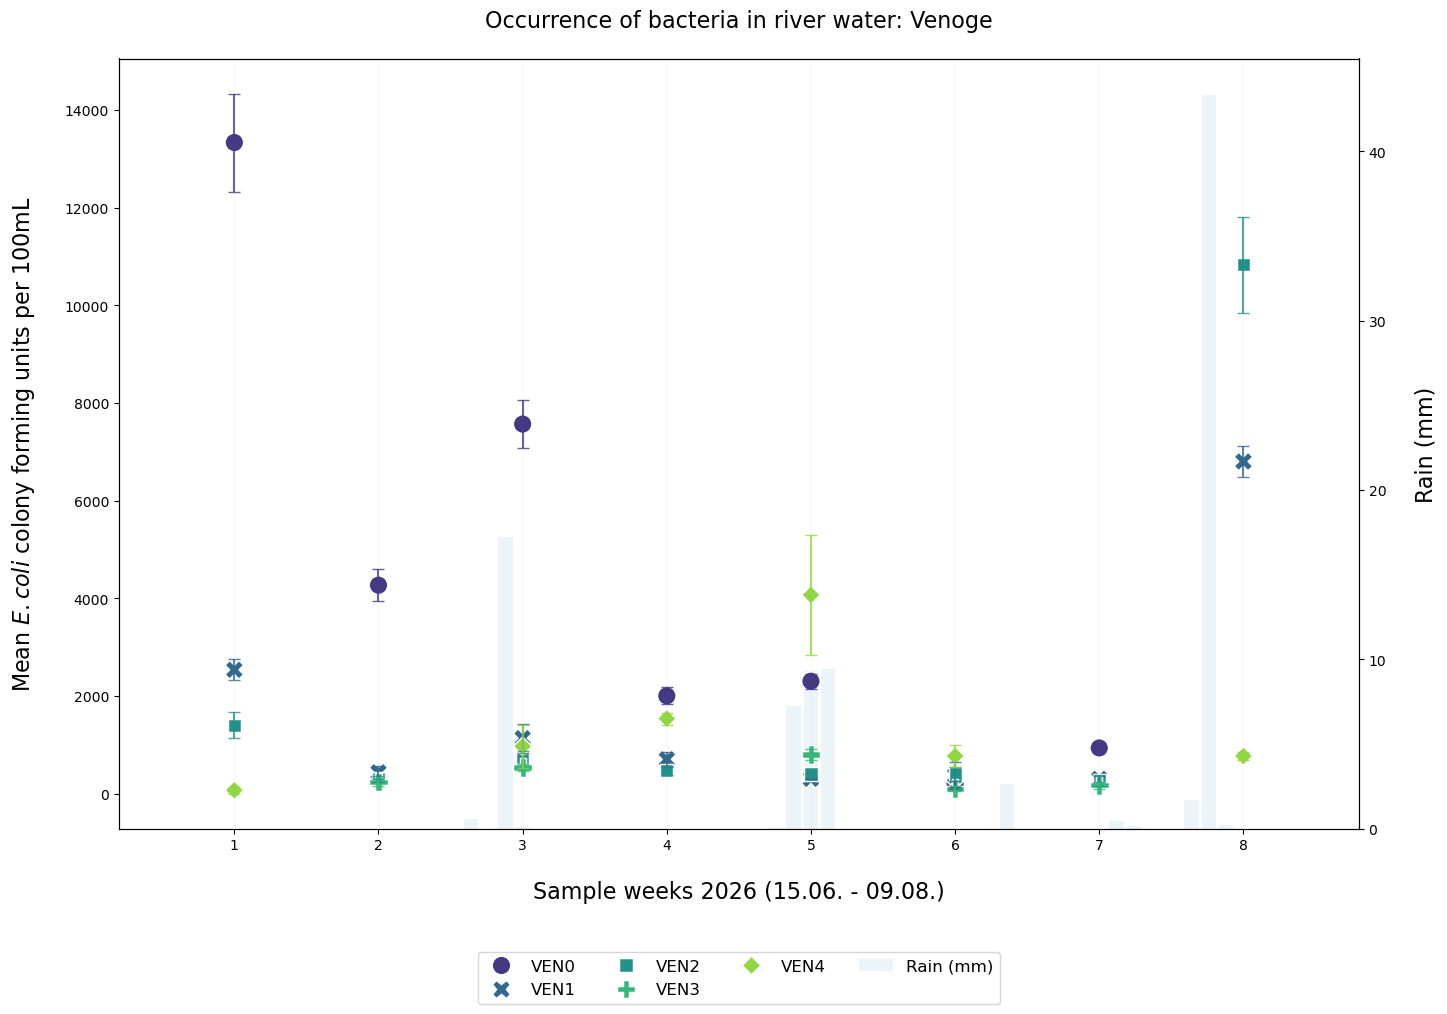

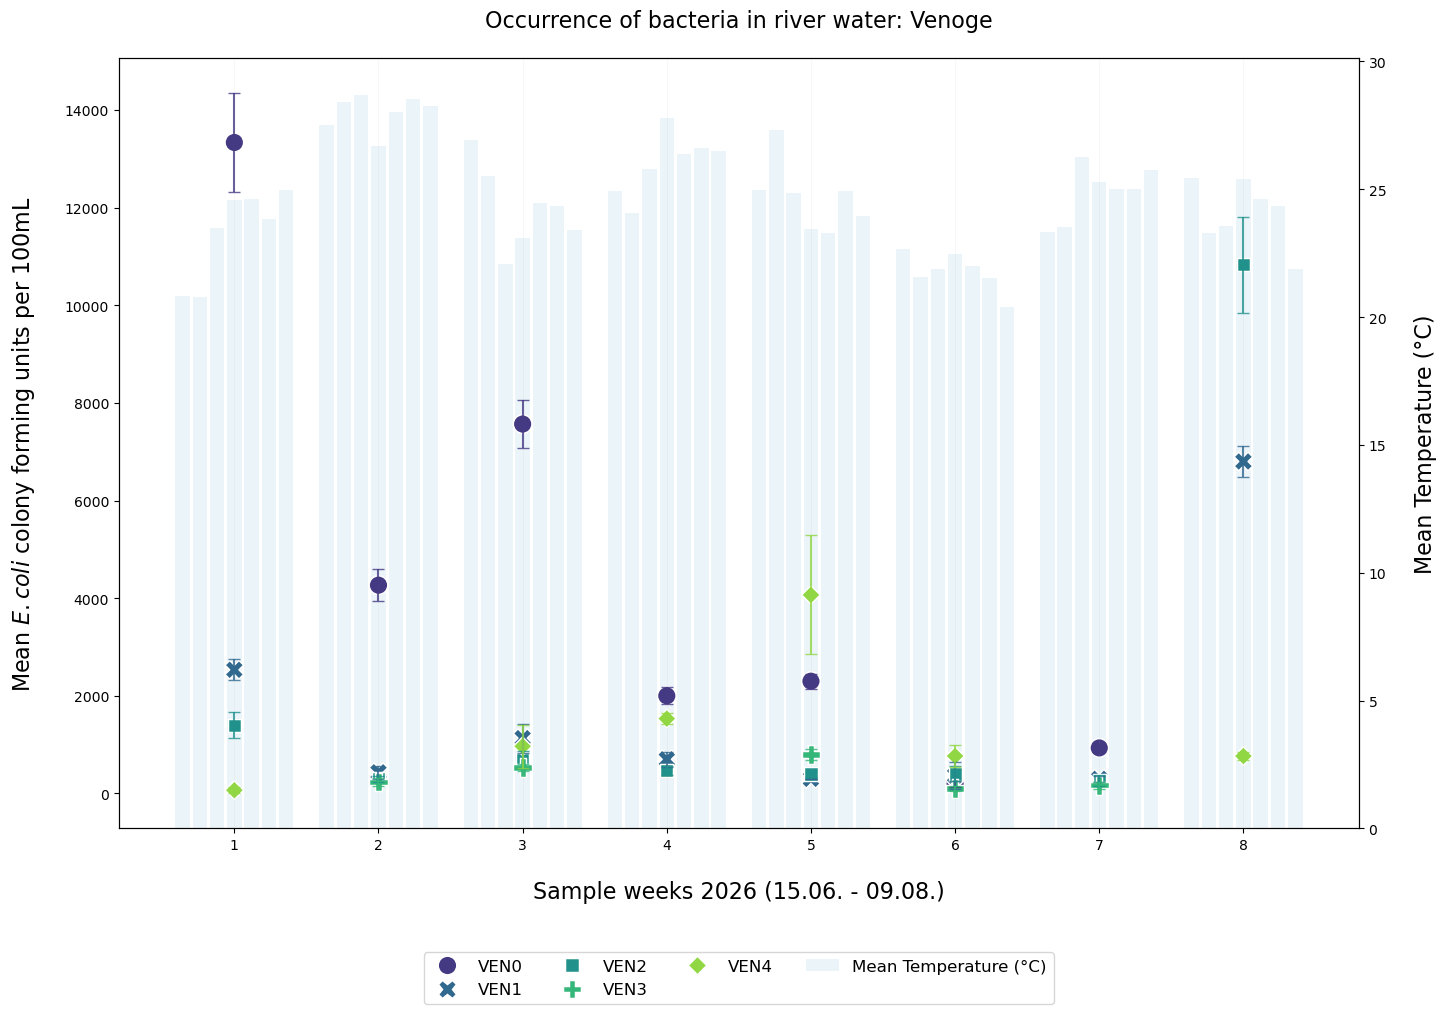

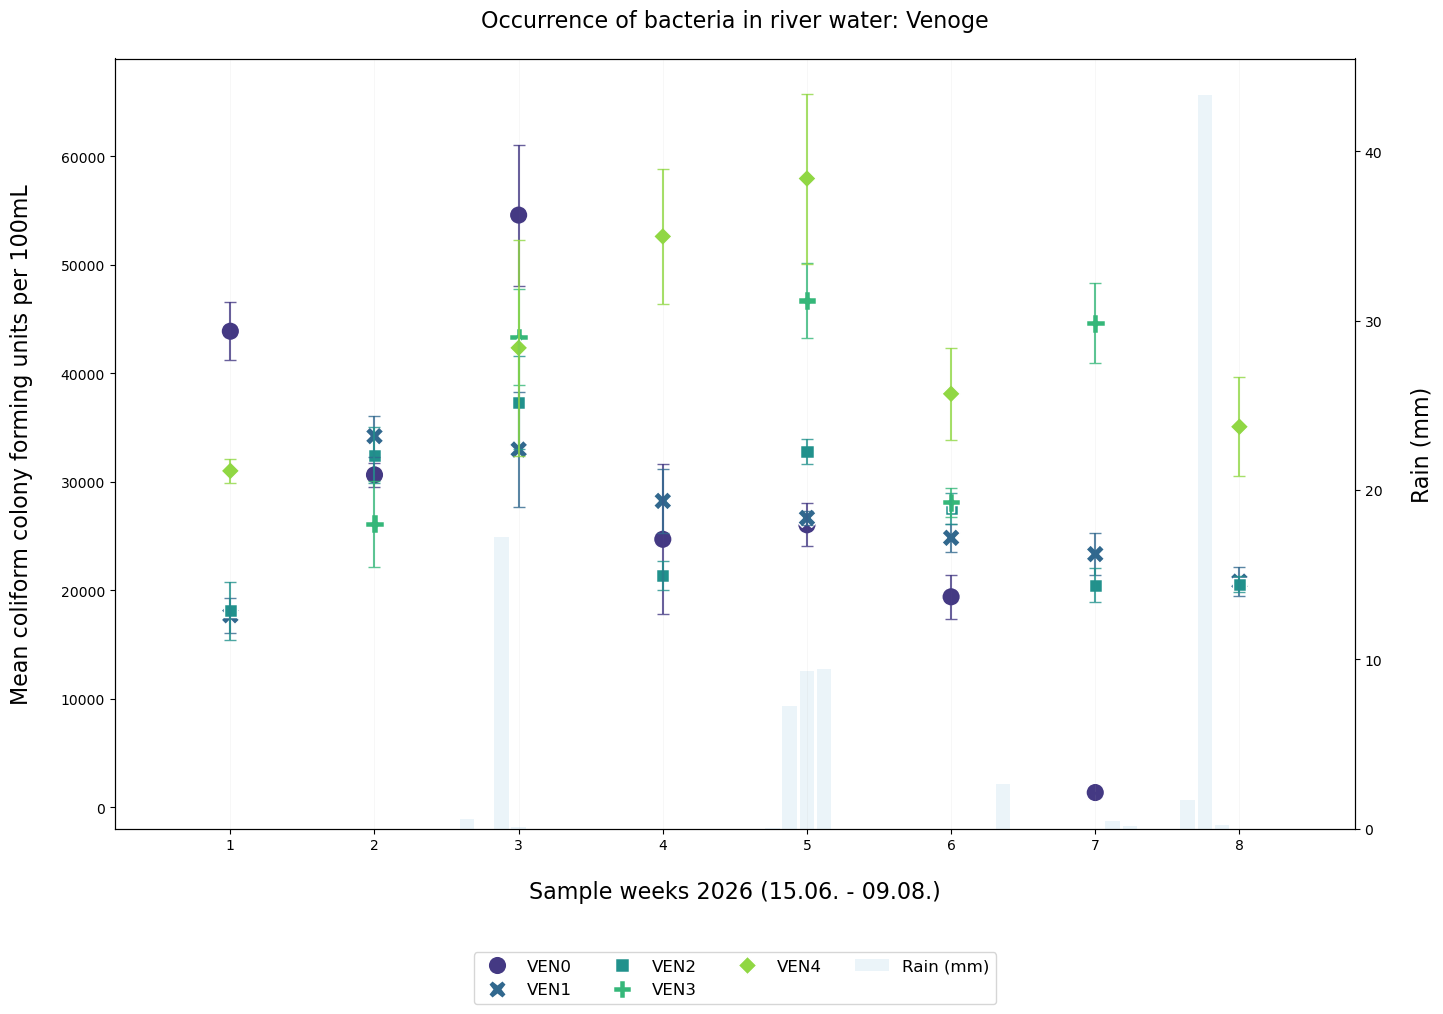

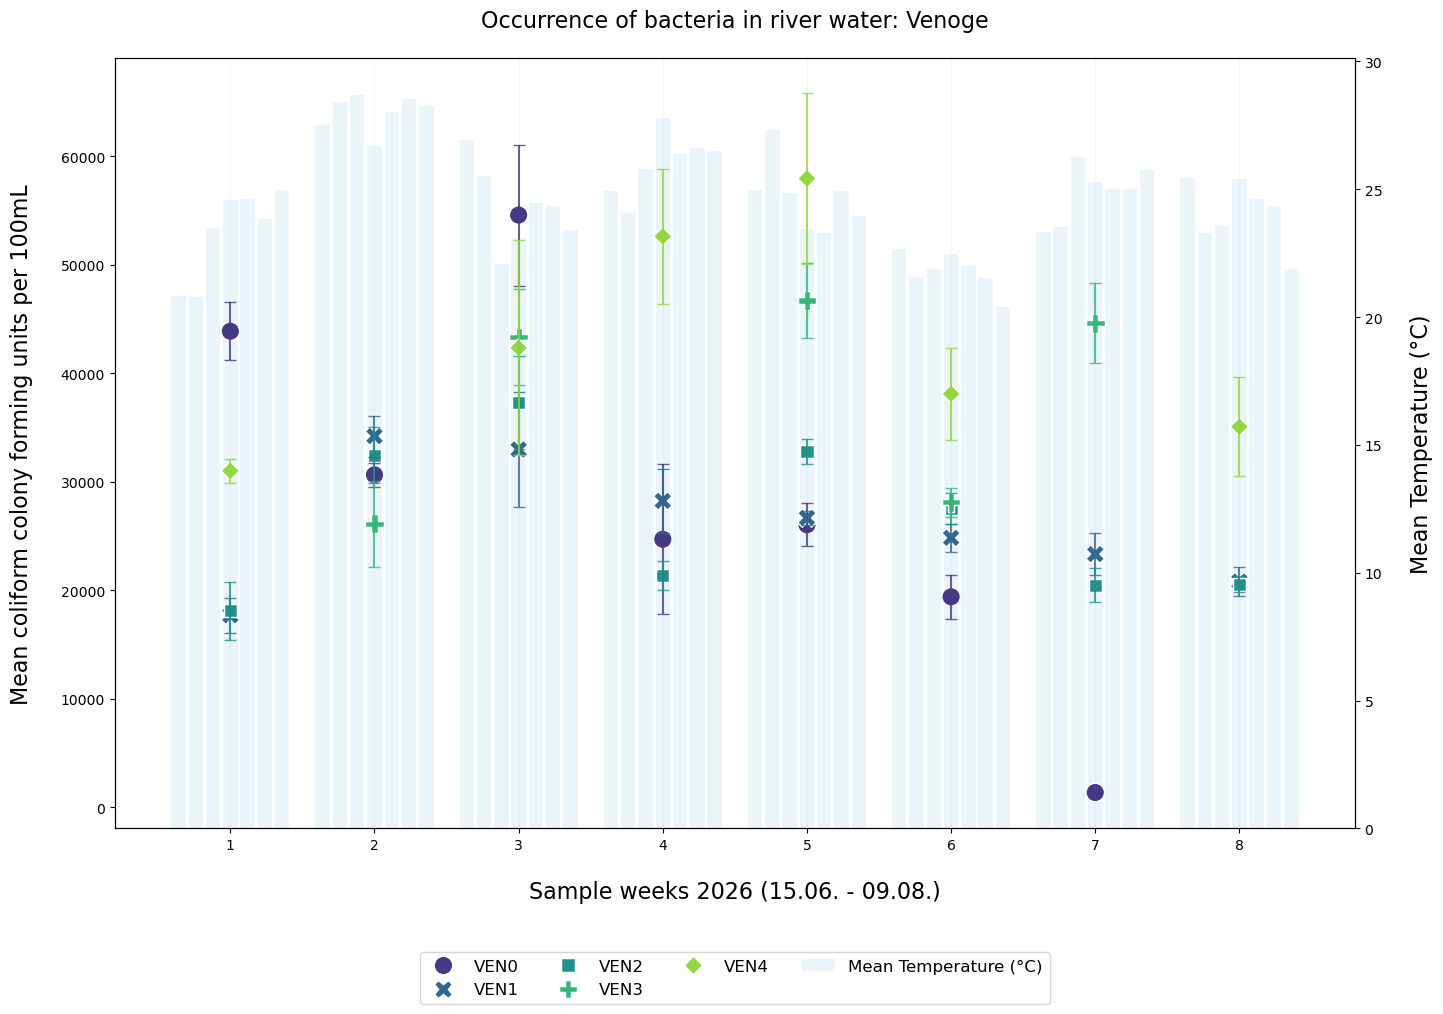

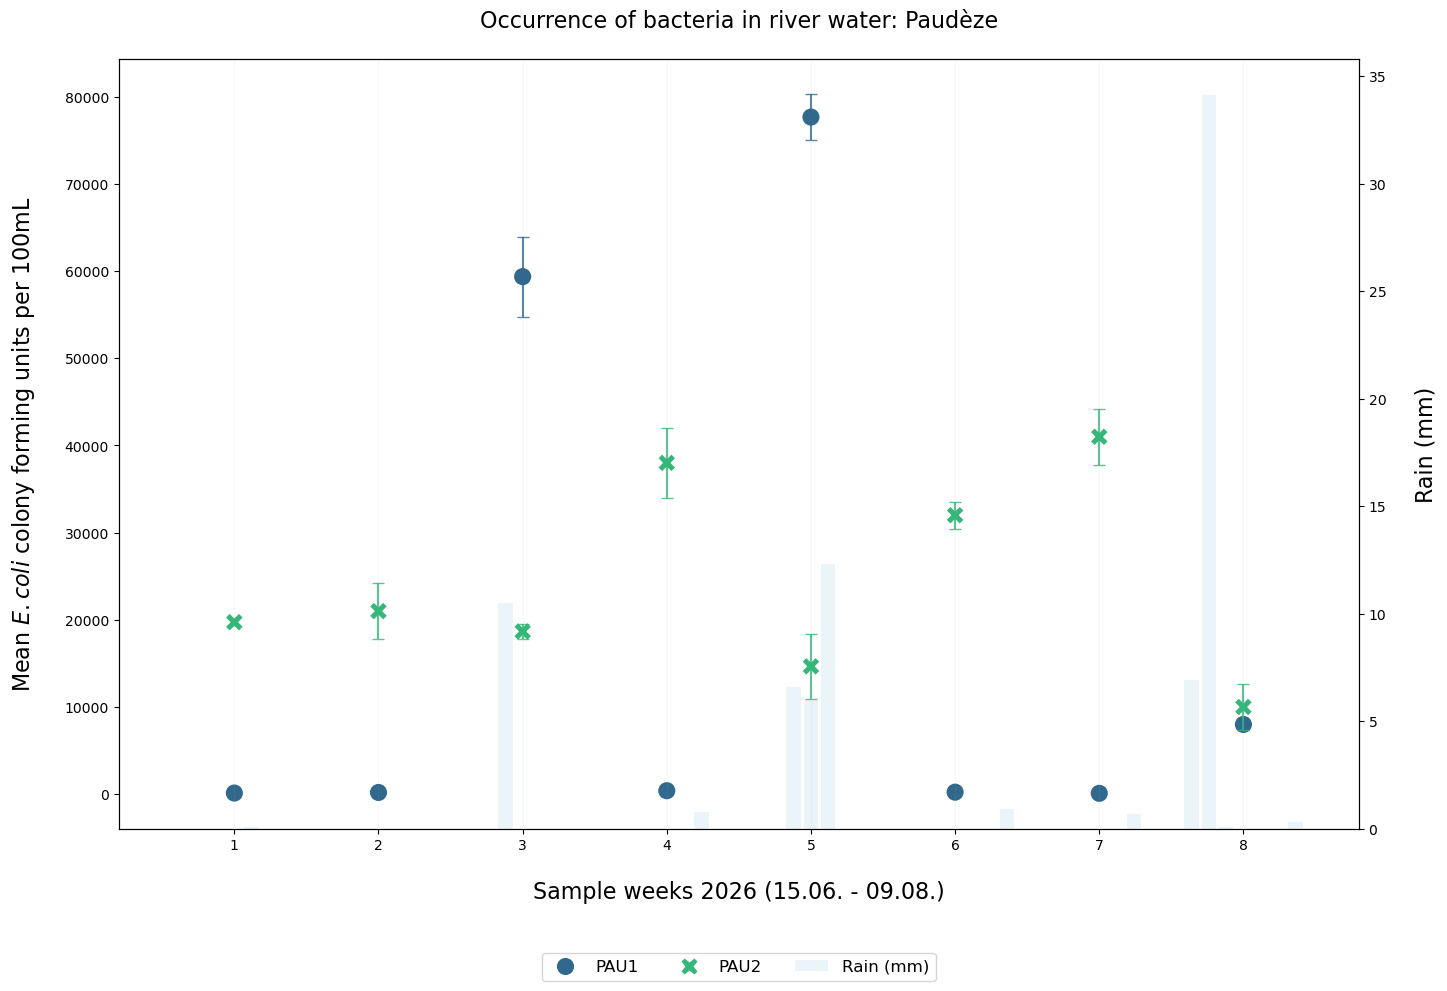

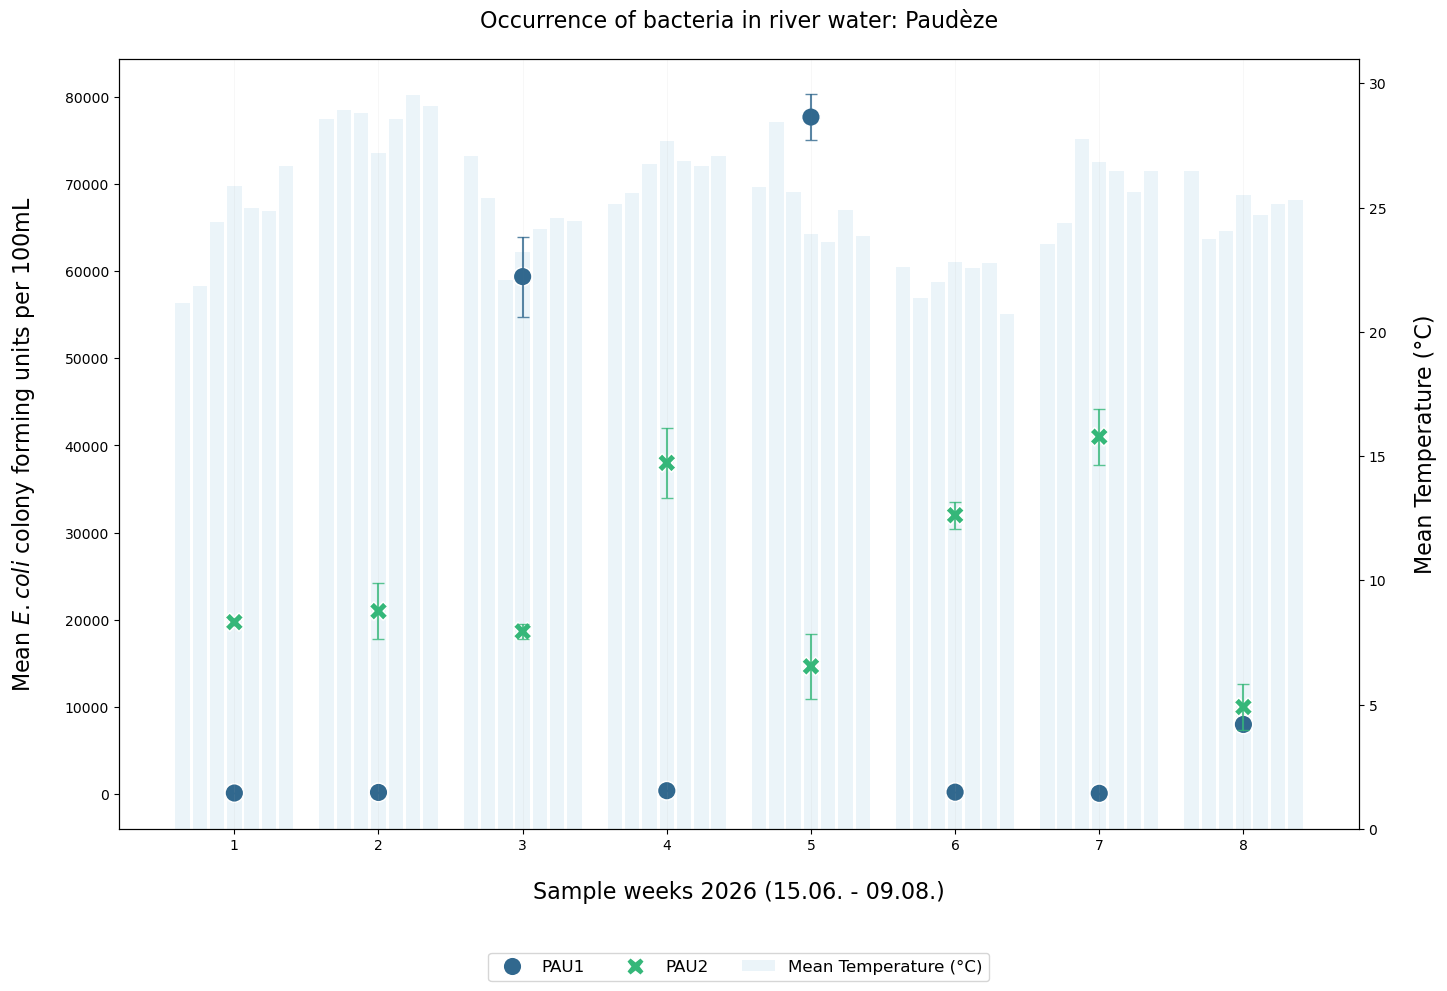

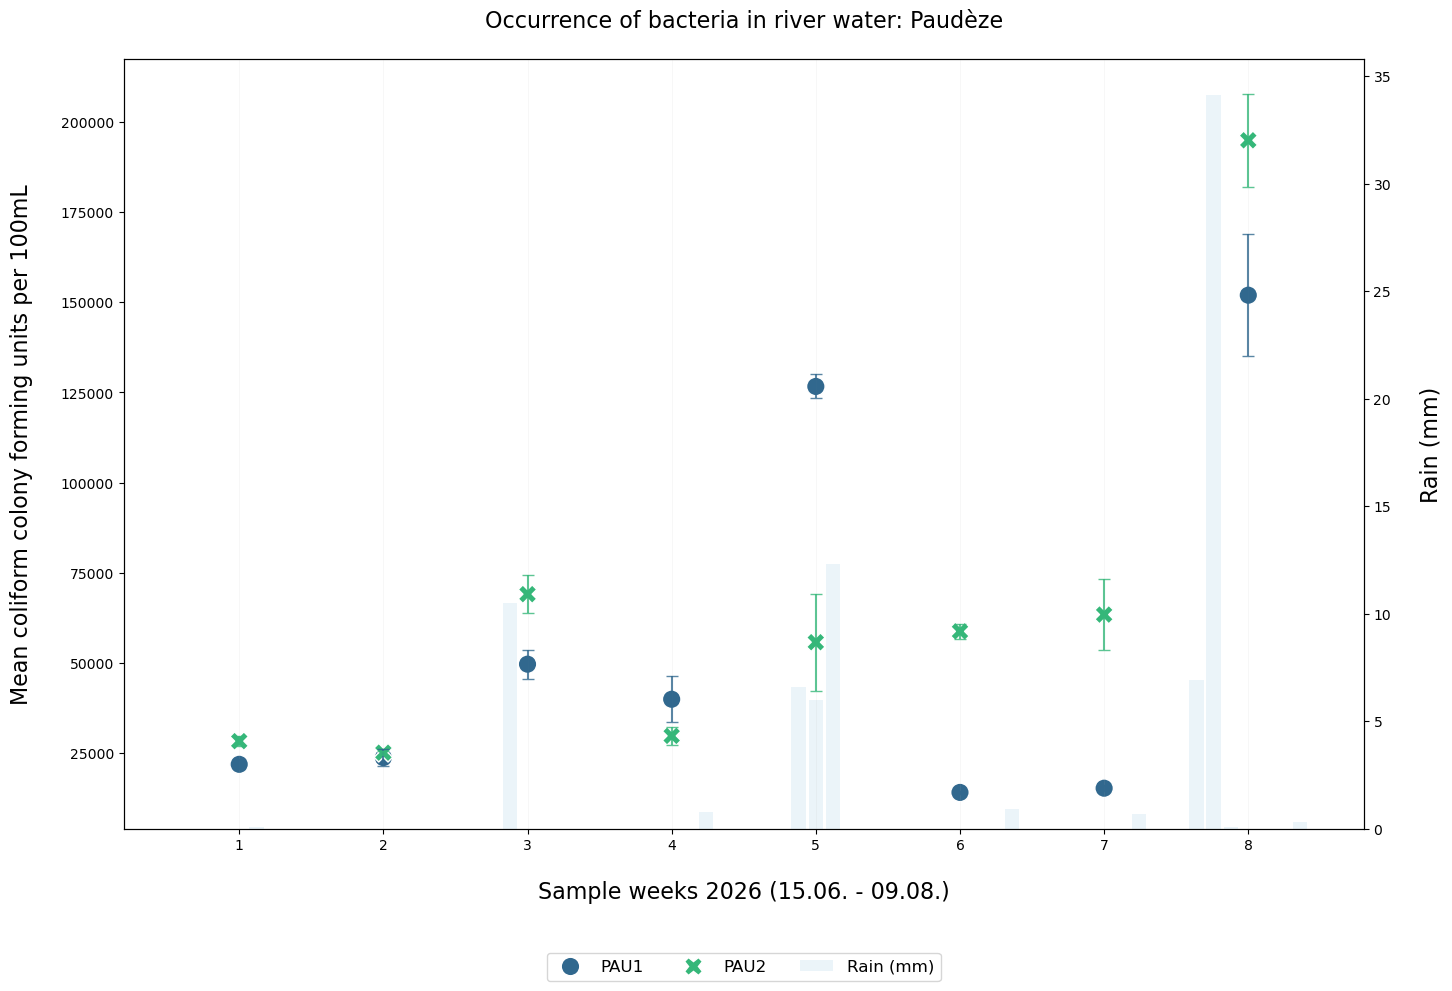

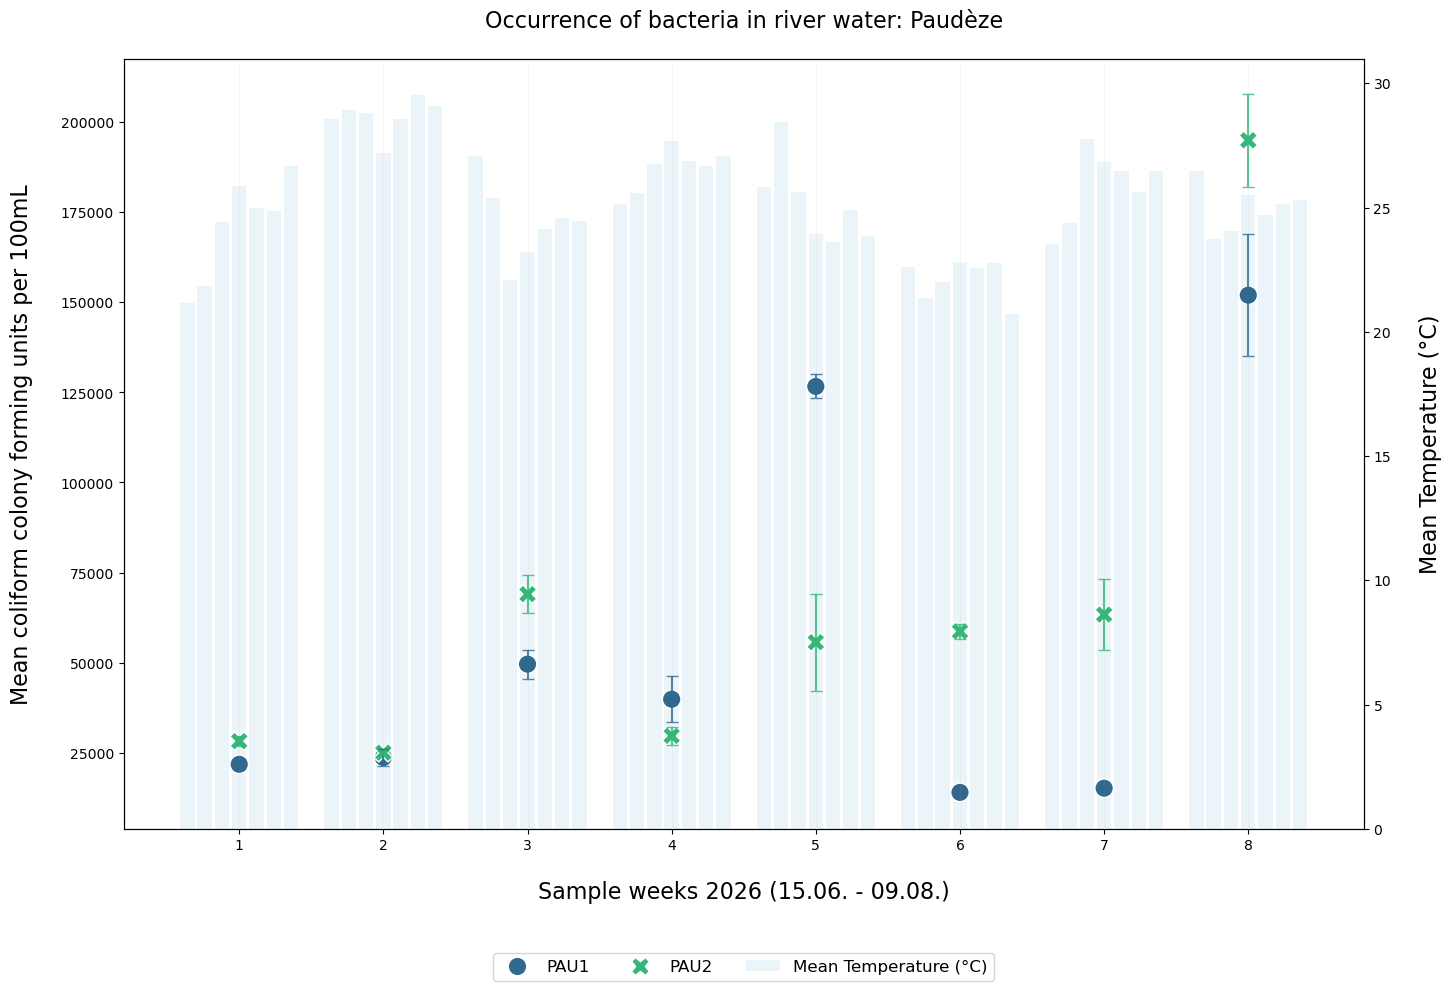

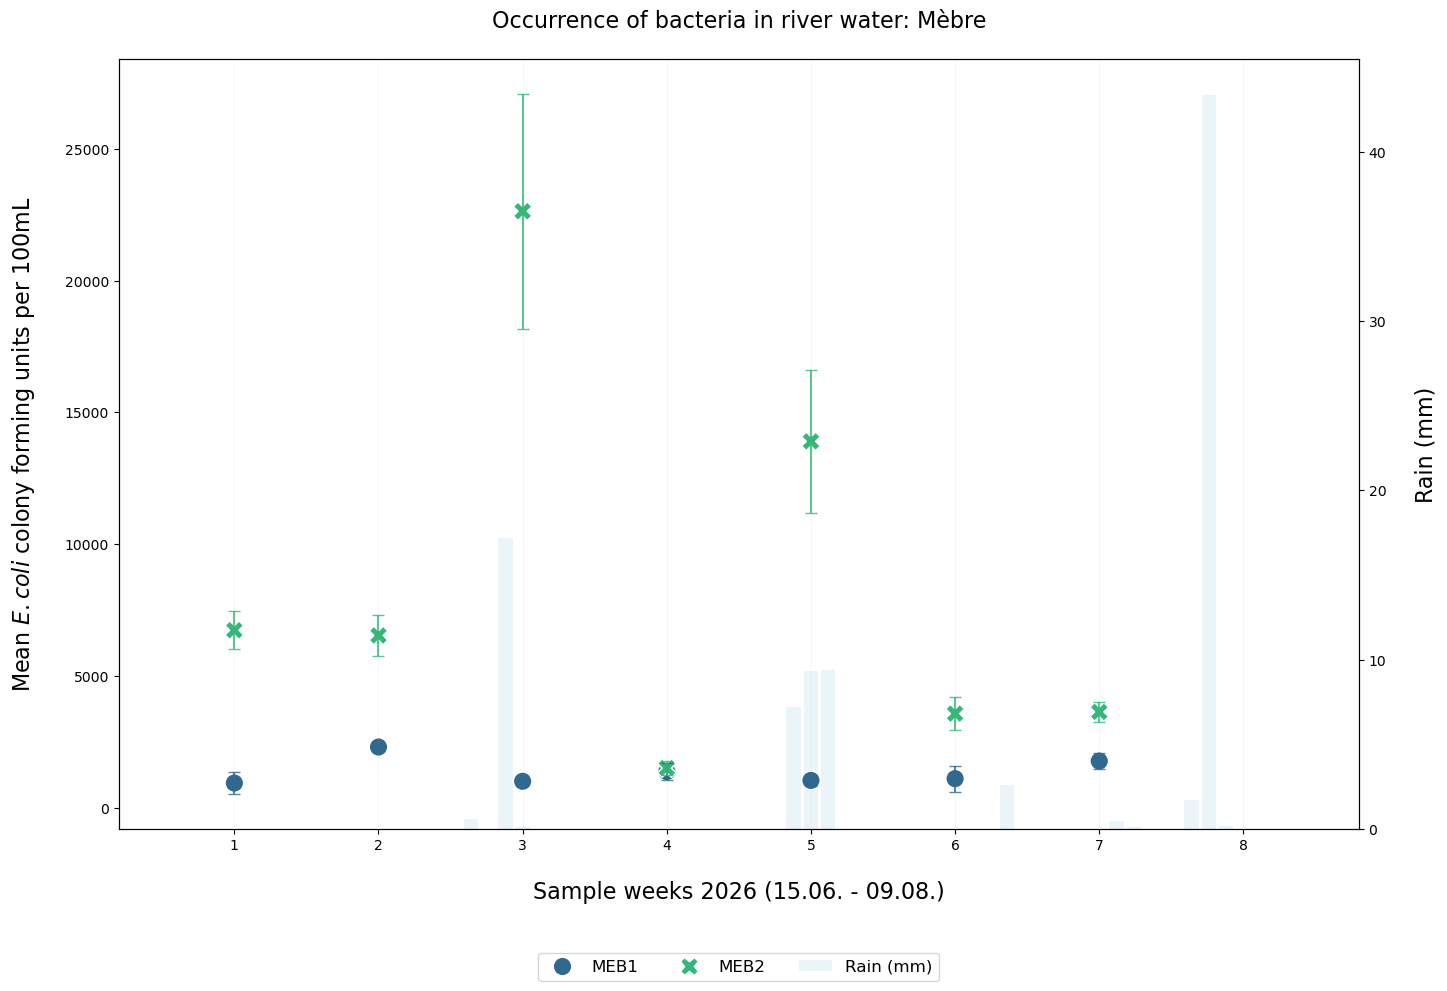

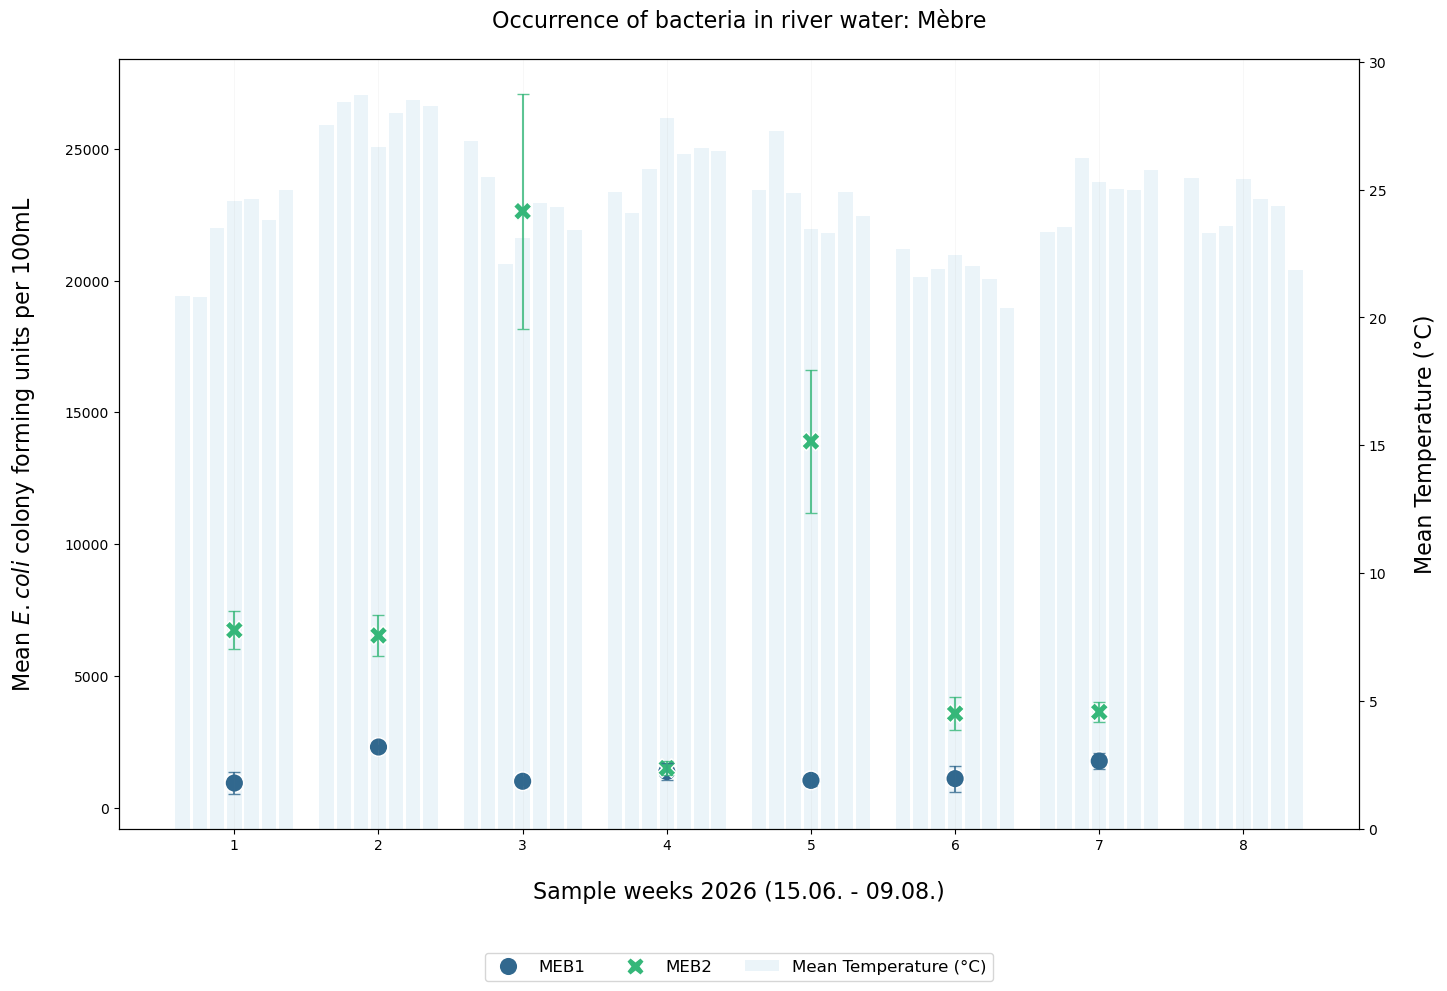

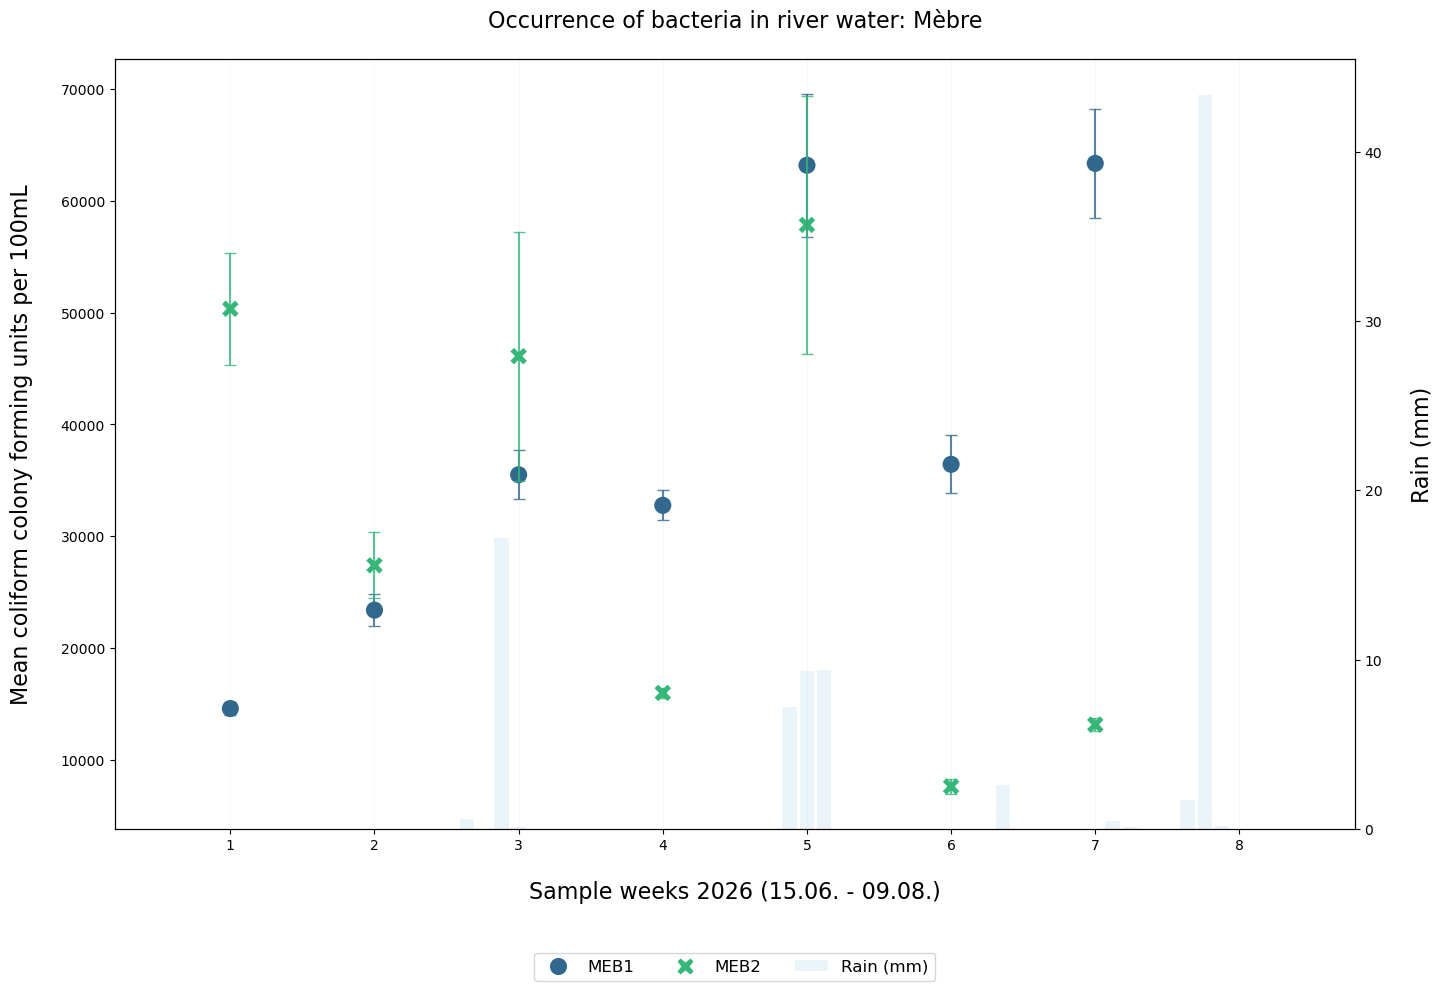

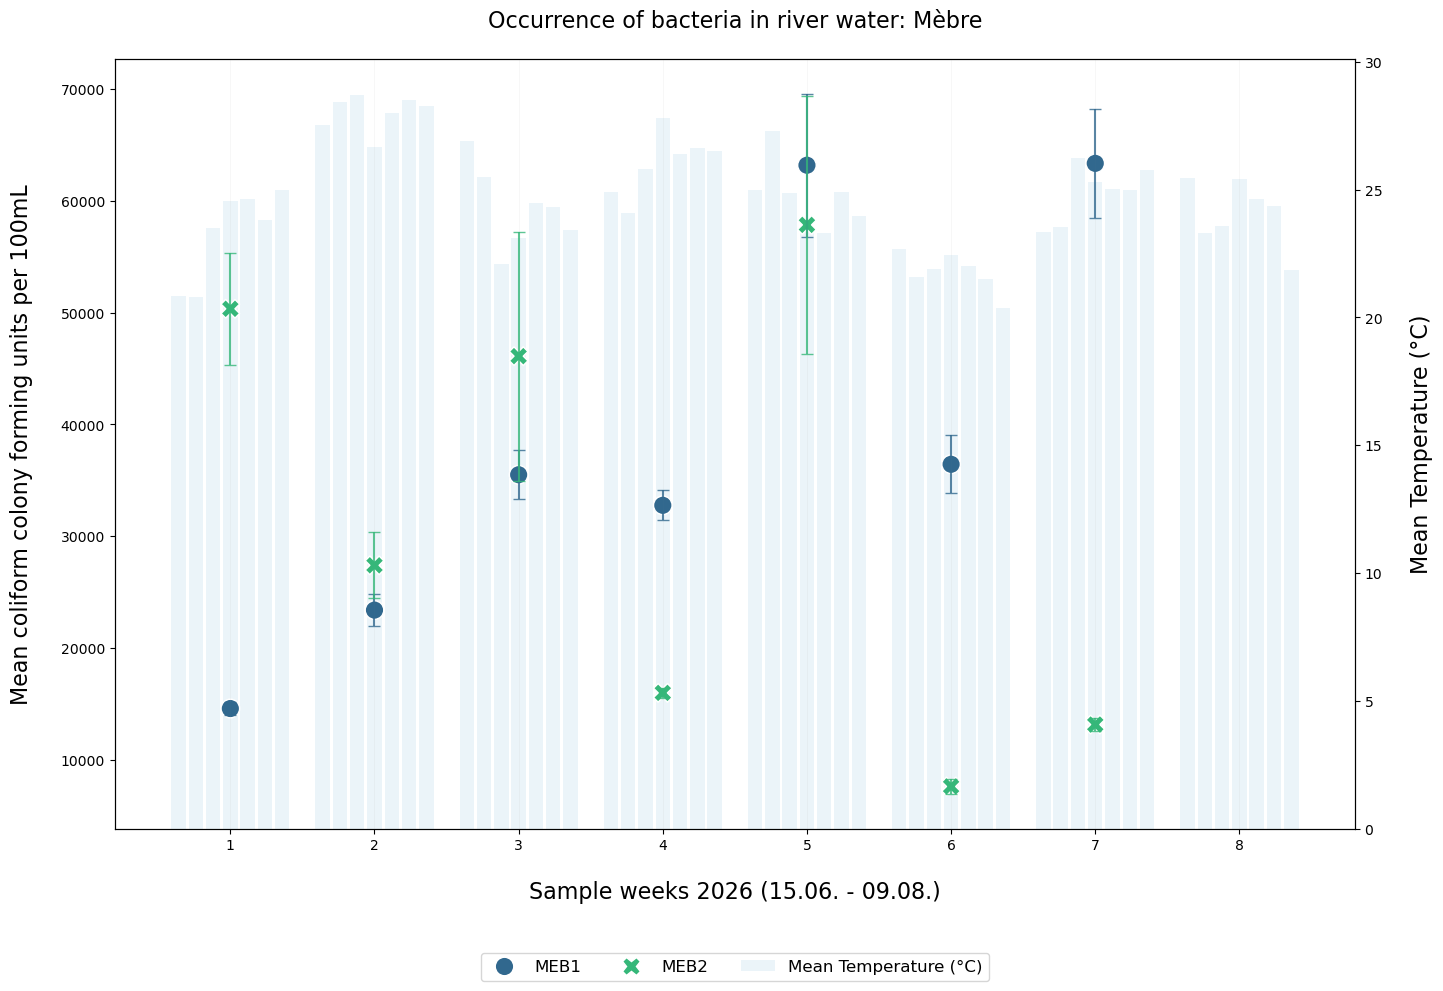

In [40]:
generate_plots_for_rivers(high_rivers)

#### 3.3.4. Other Rivers

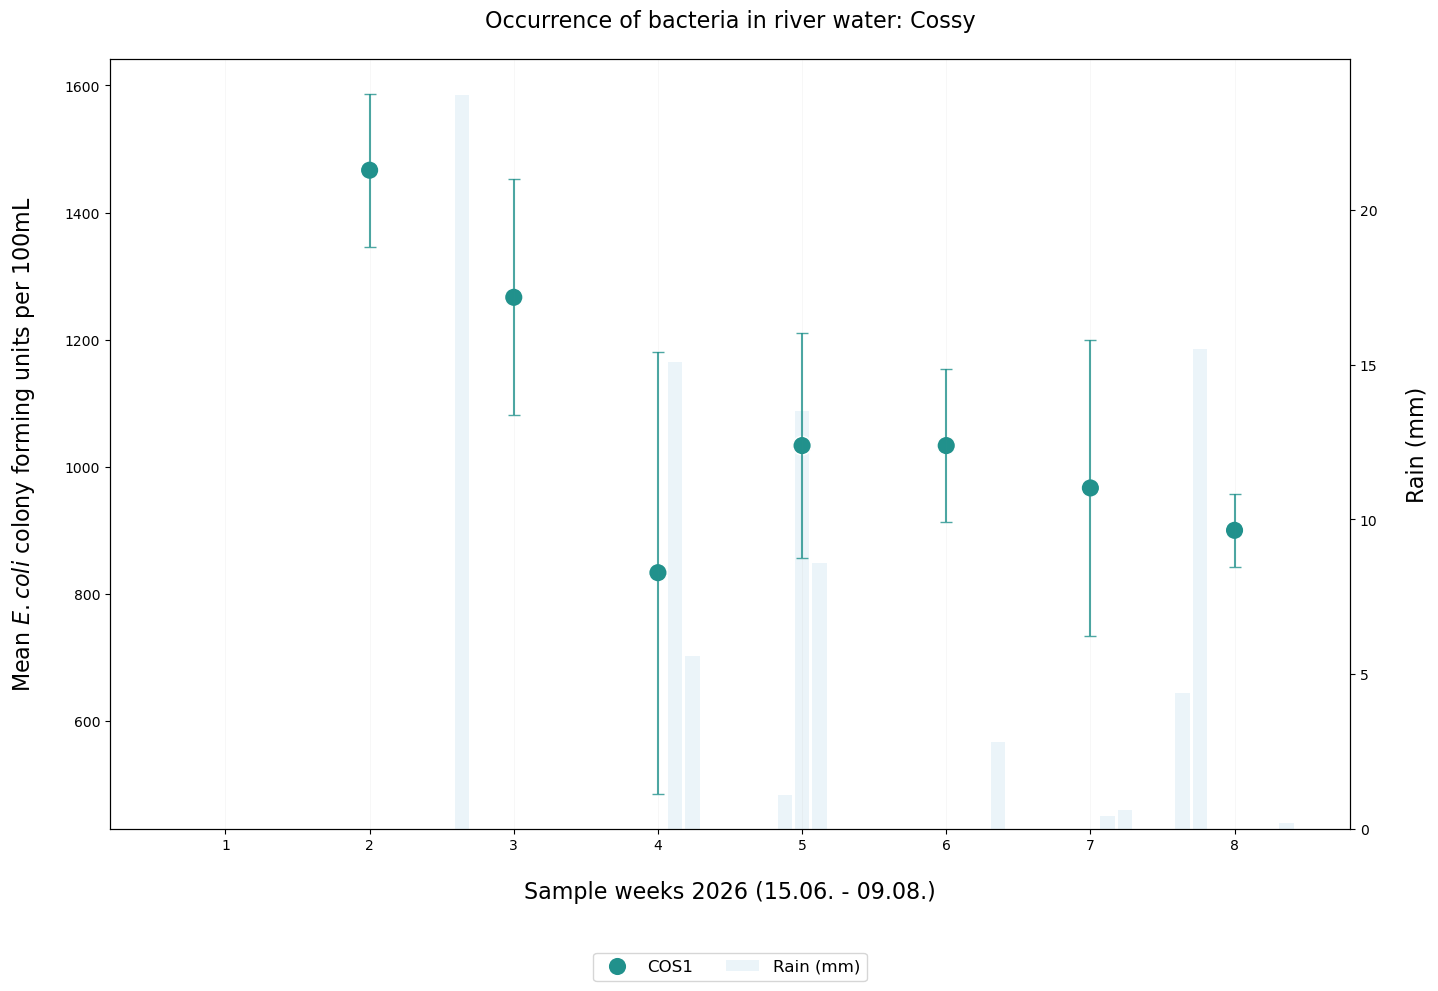

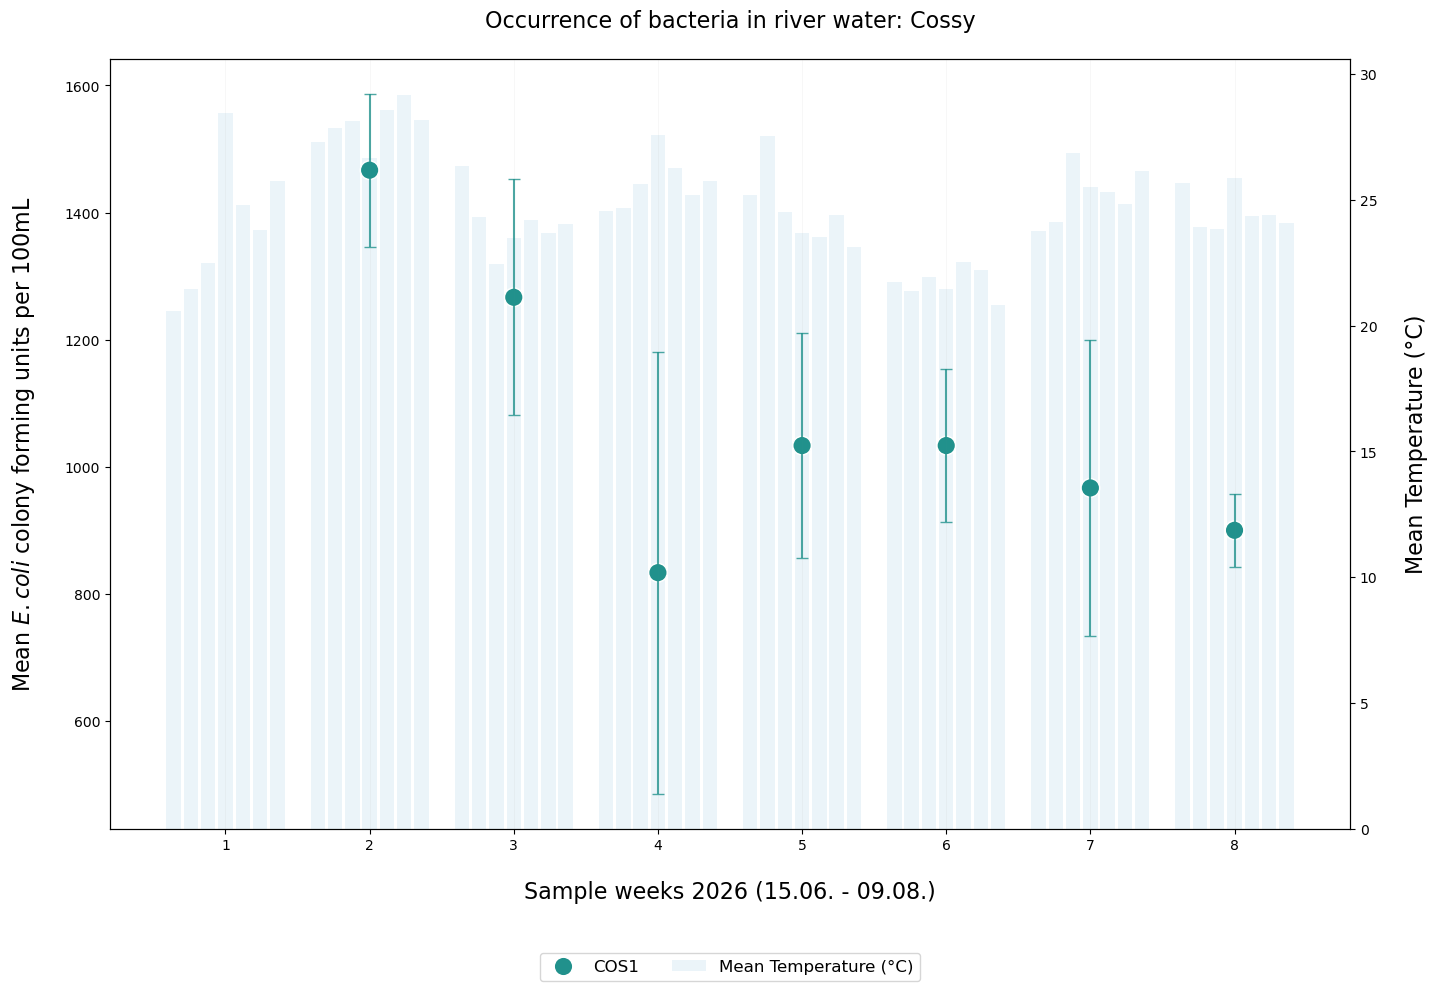

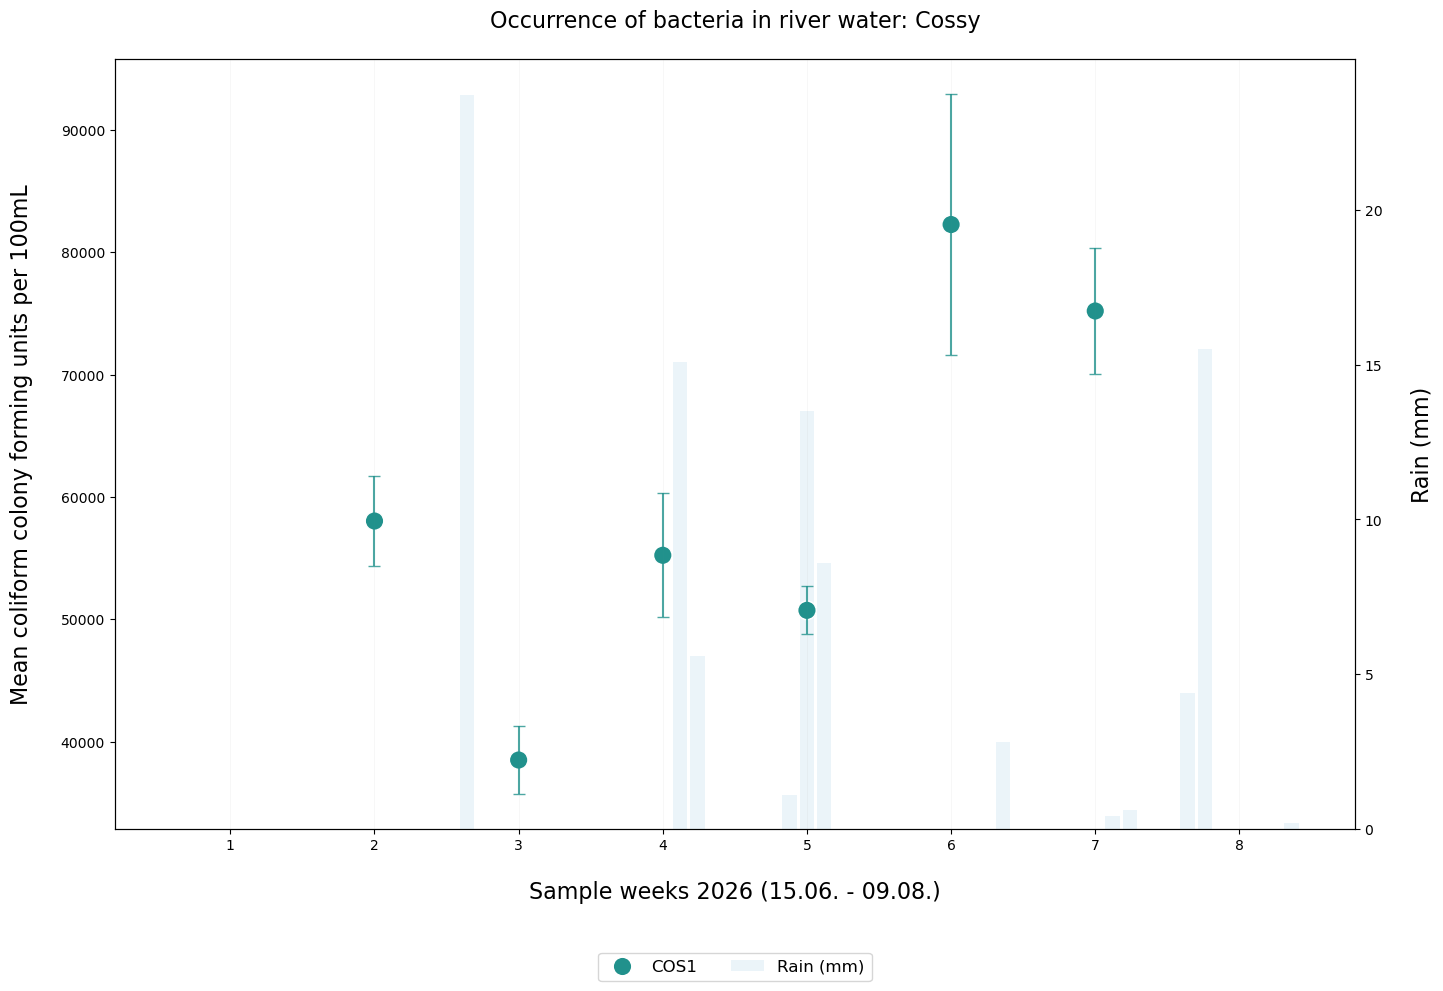

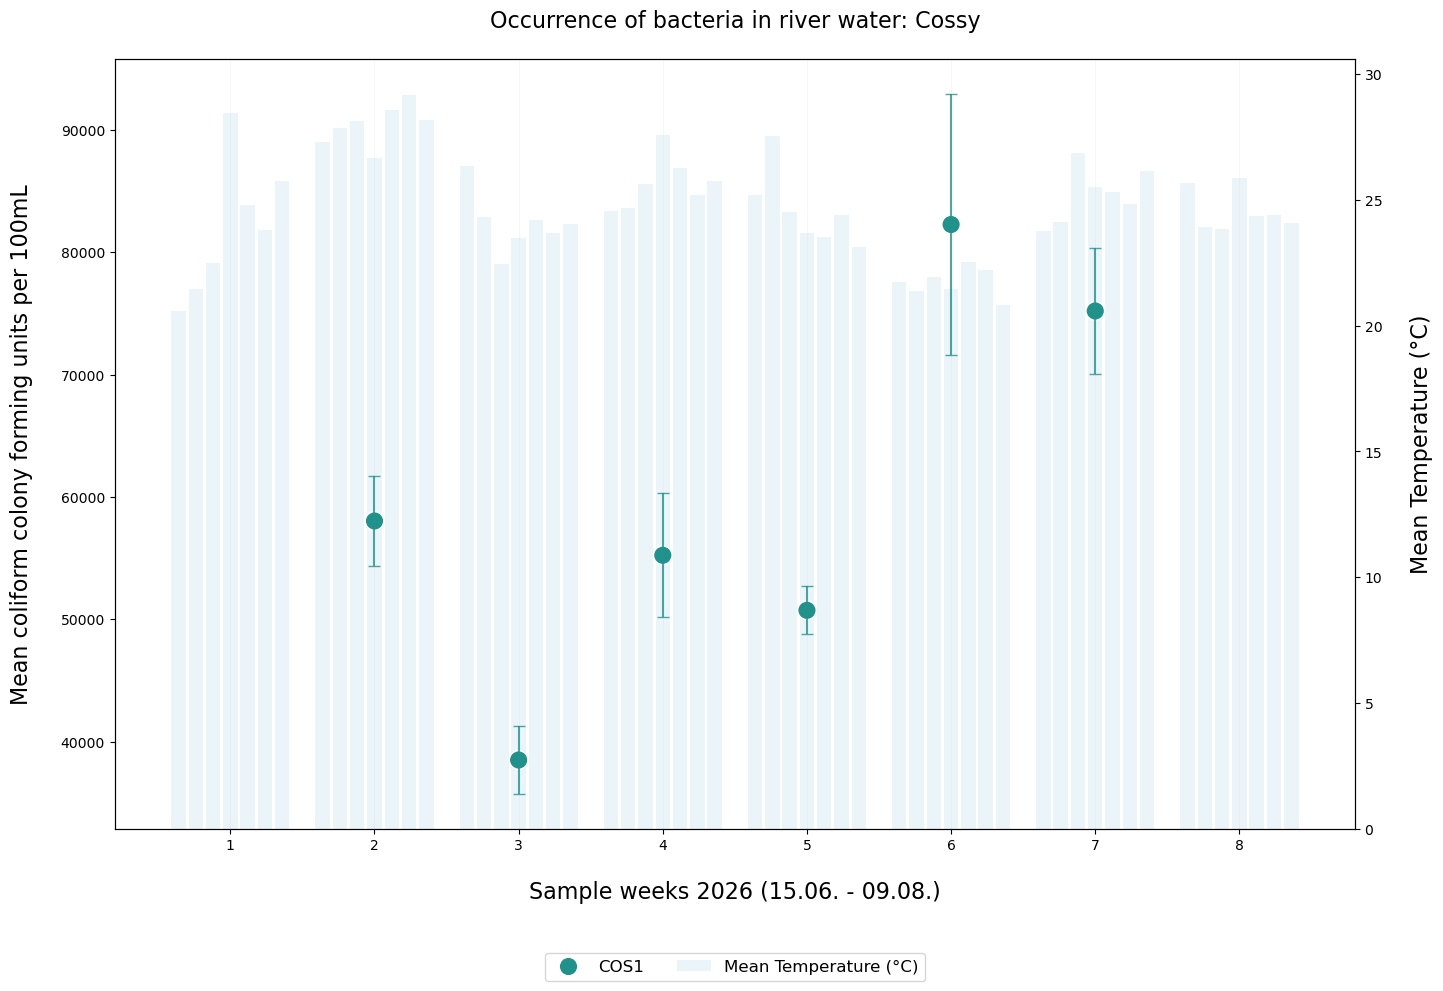

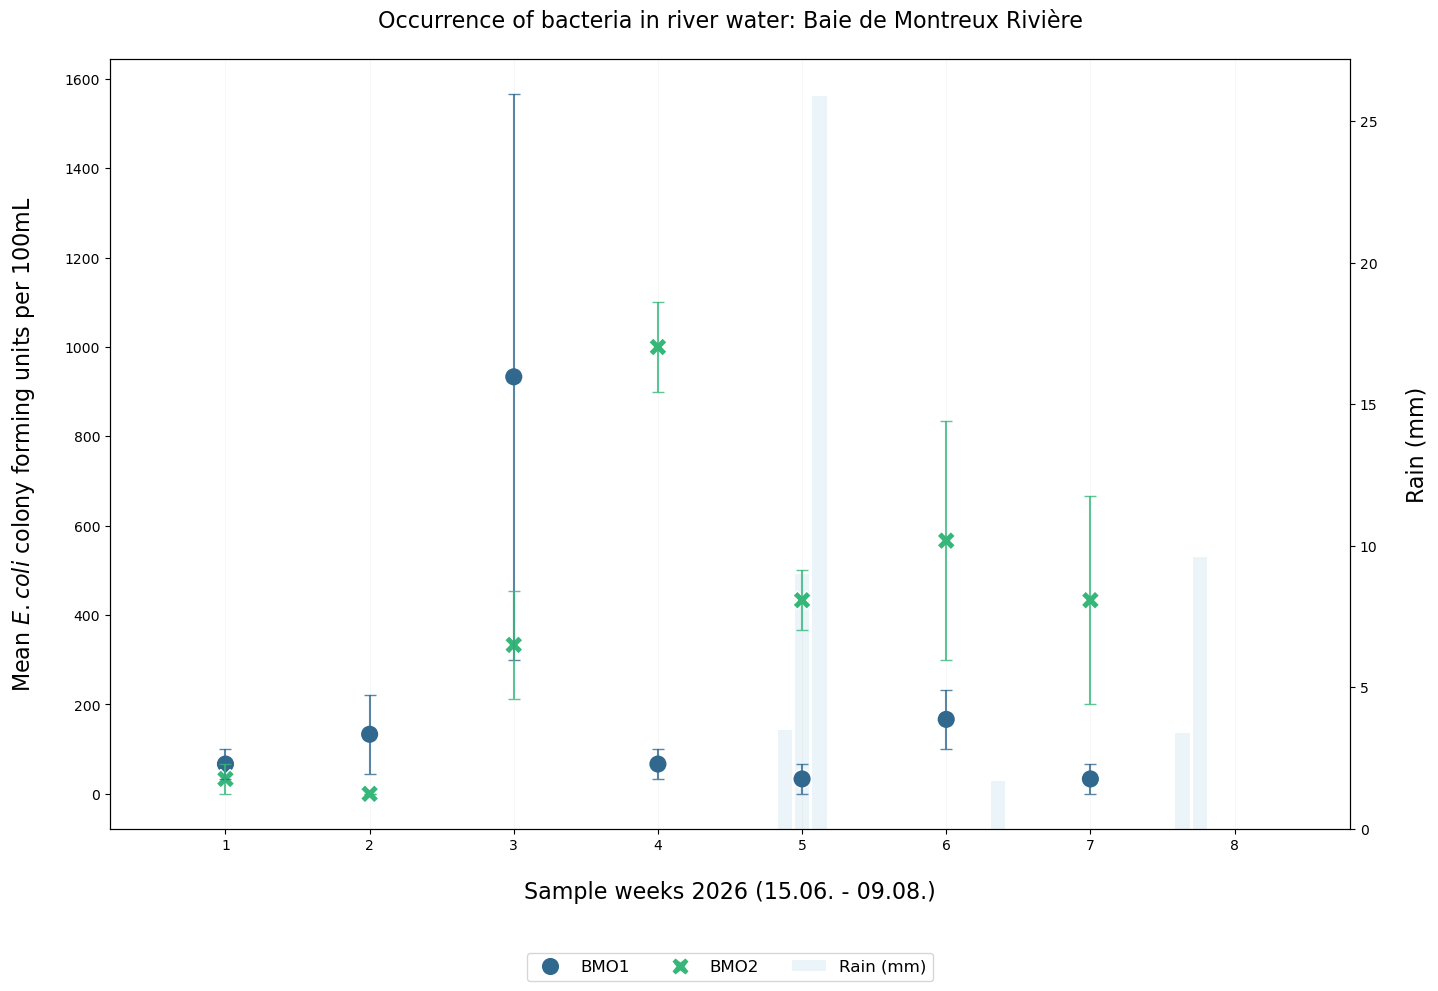

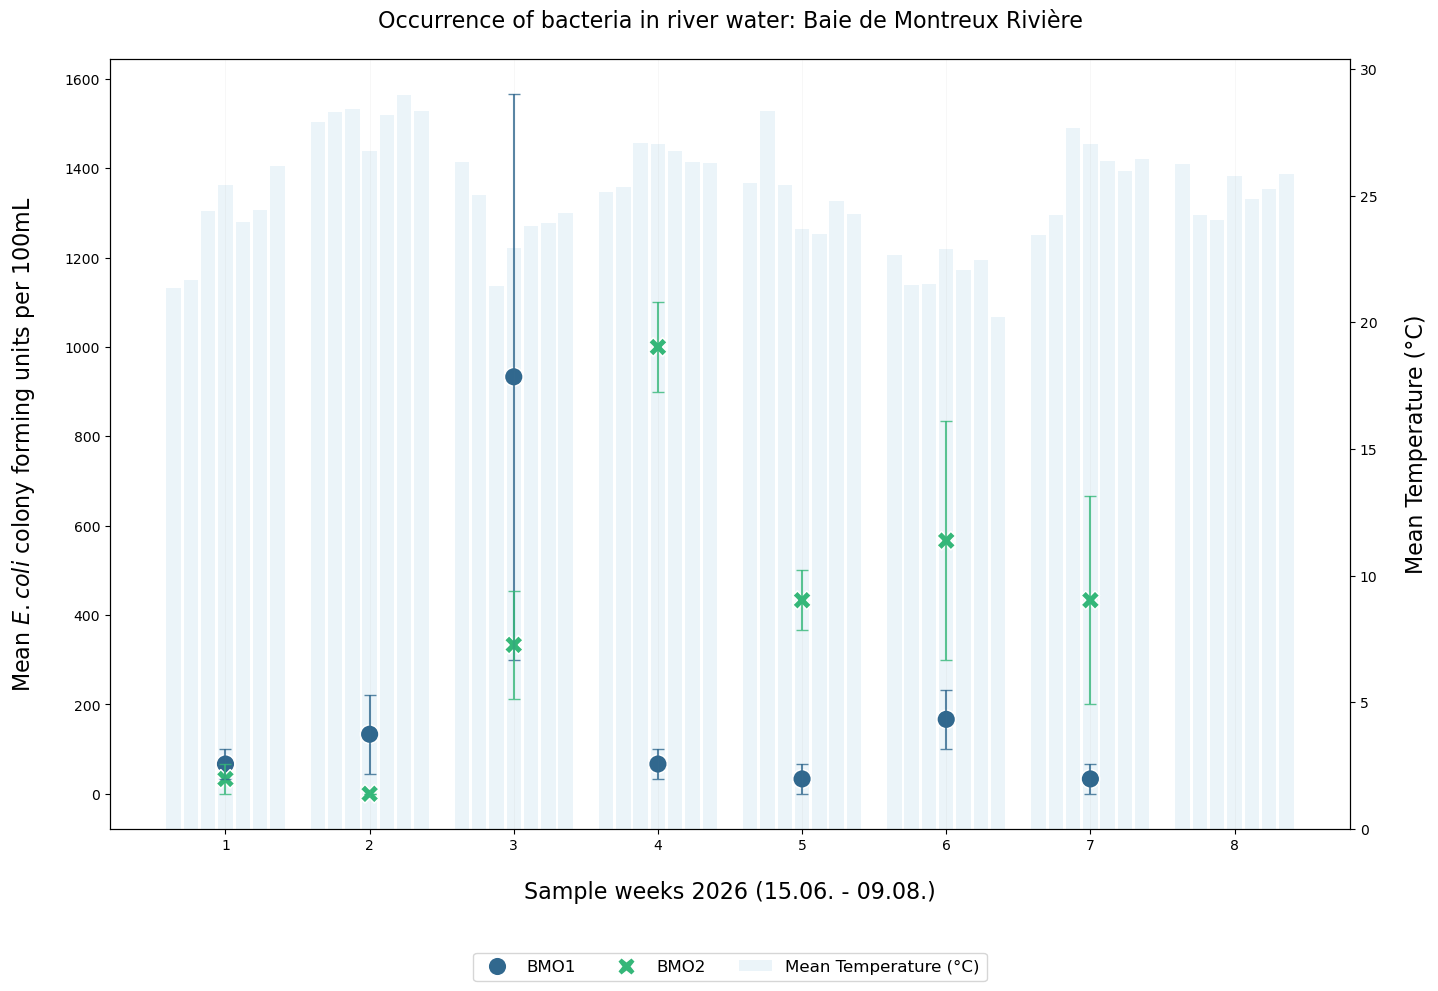

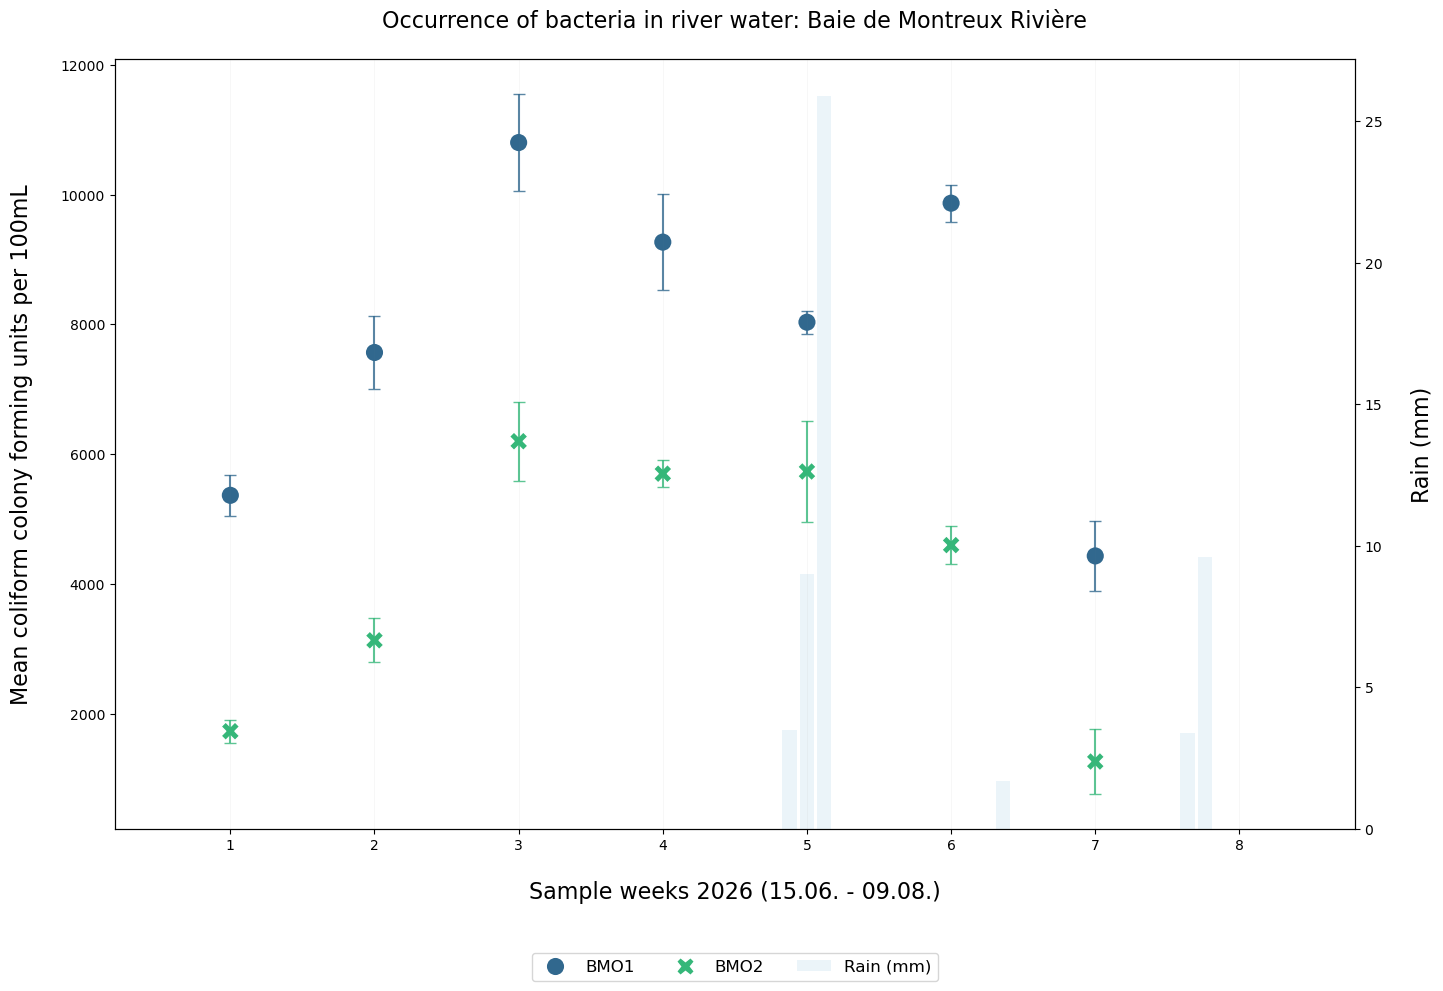

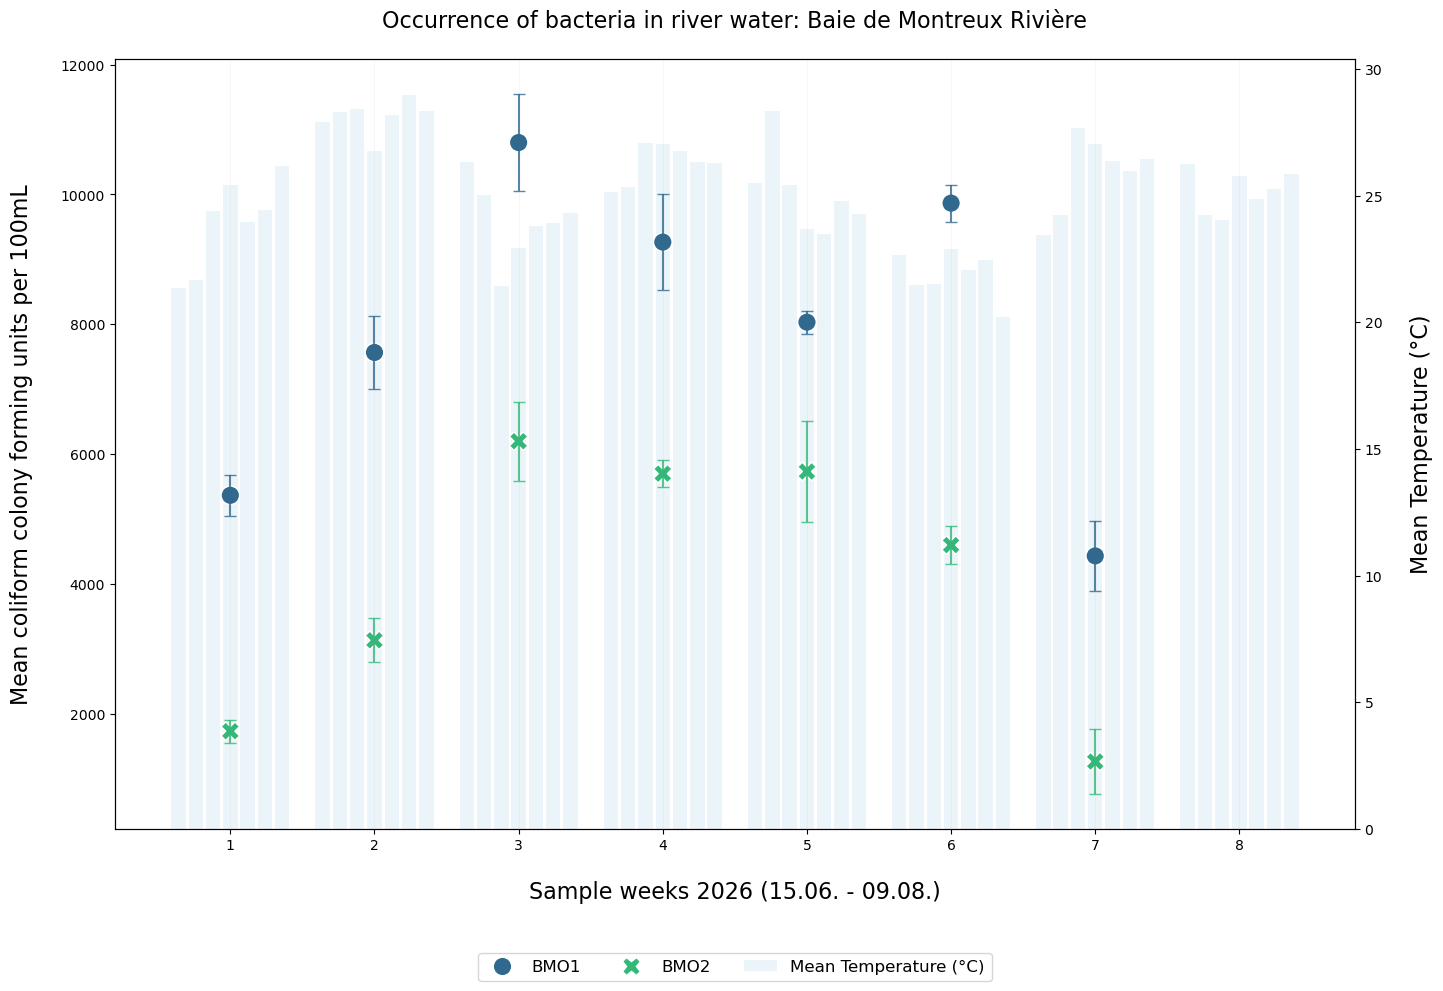

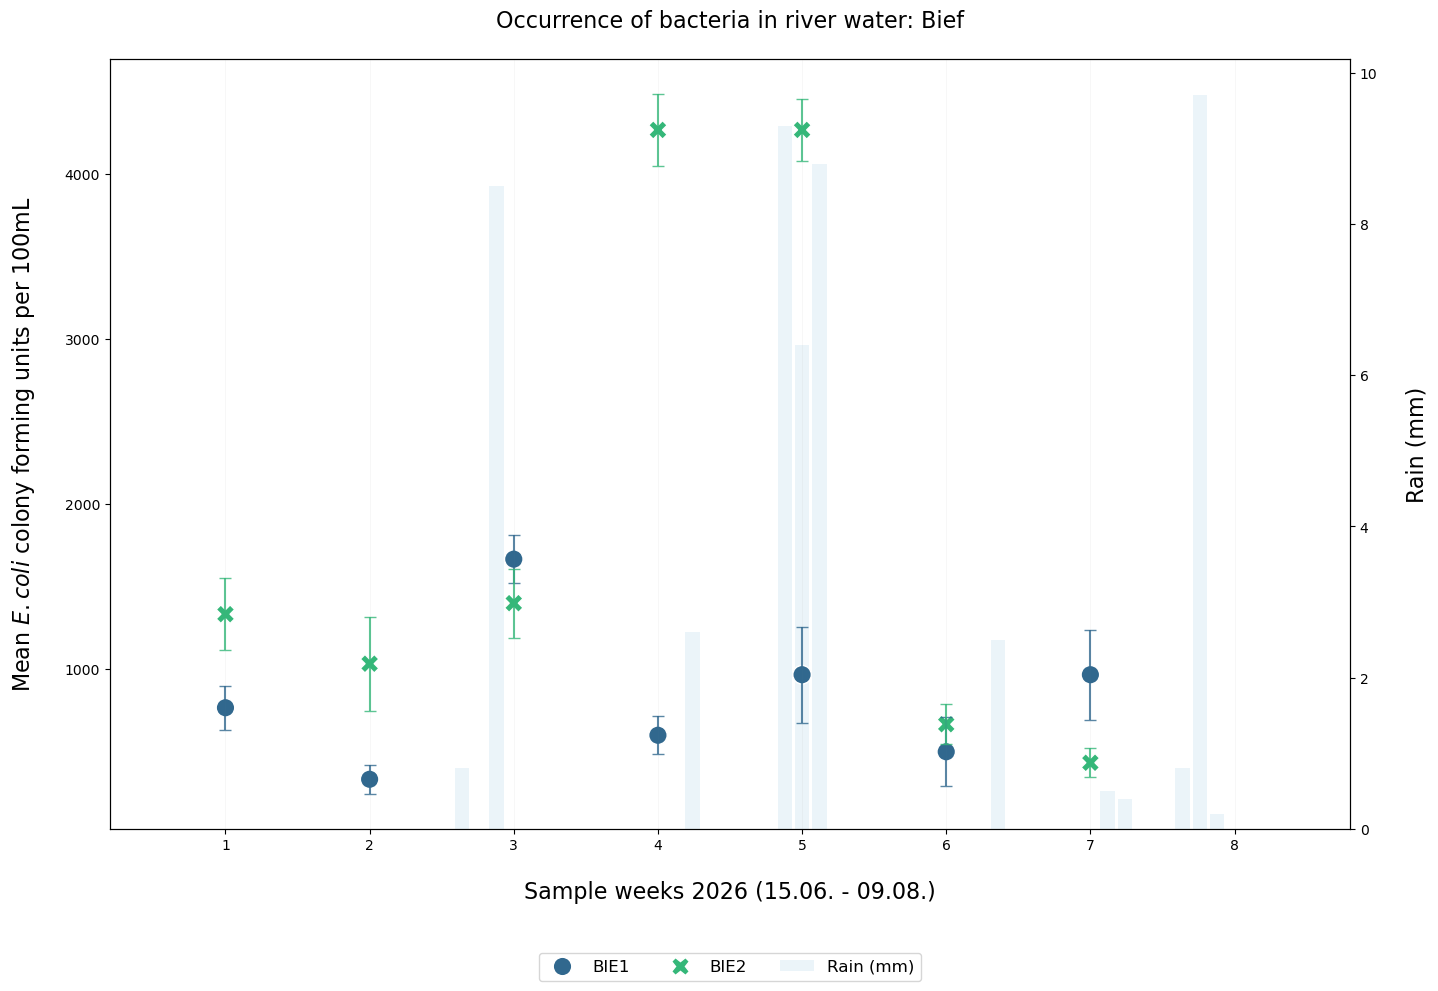

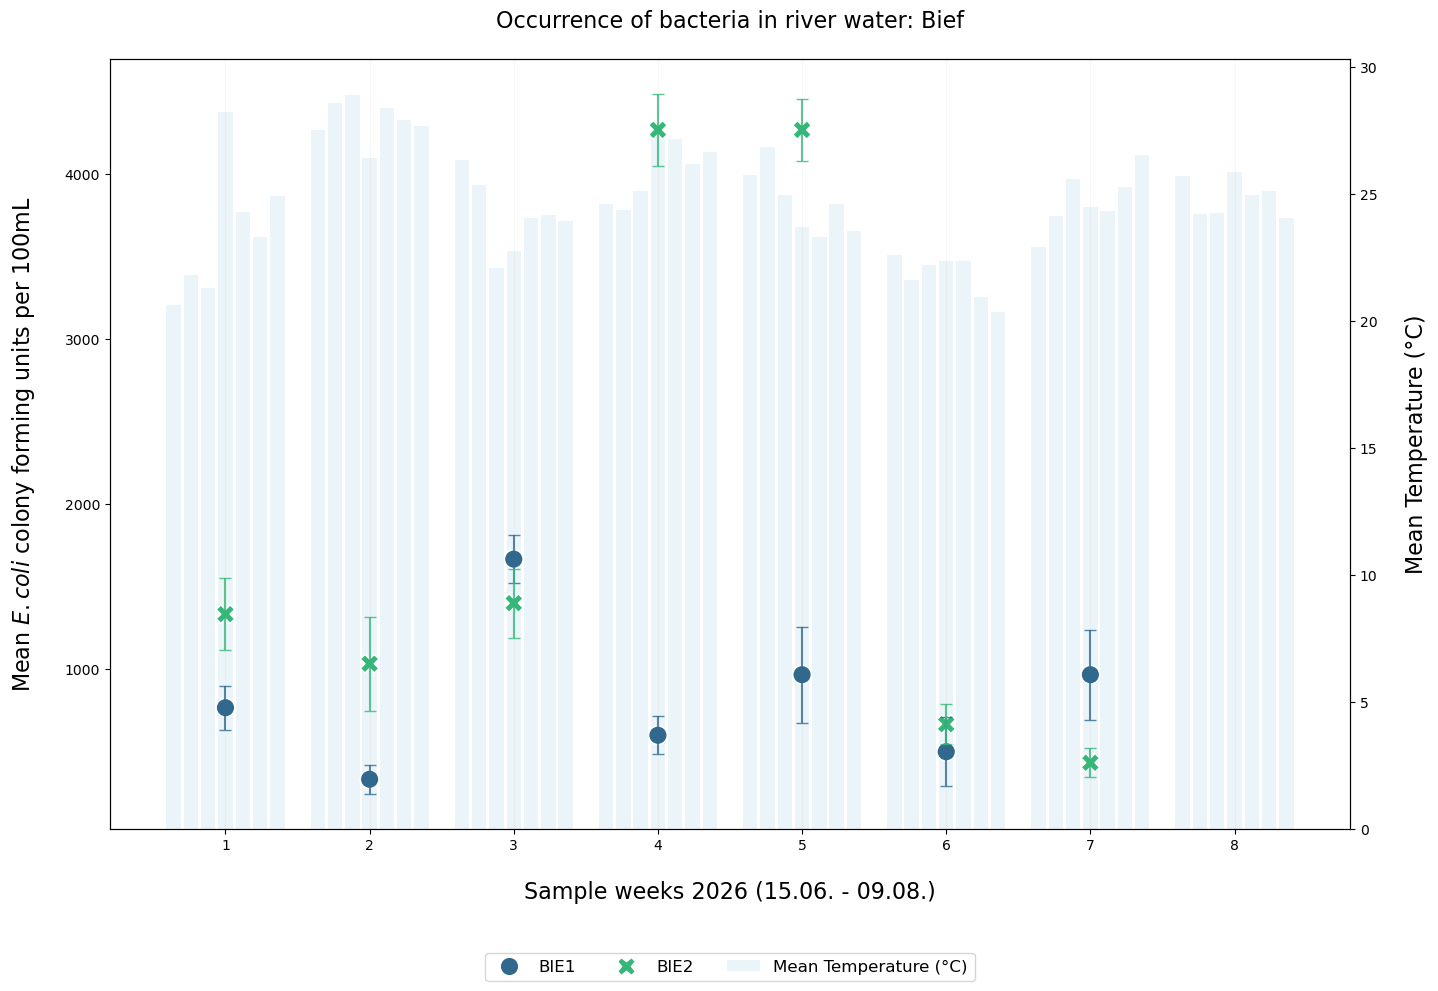

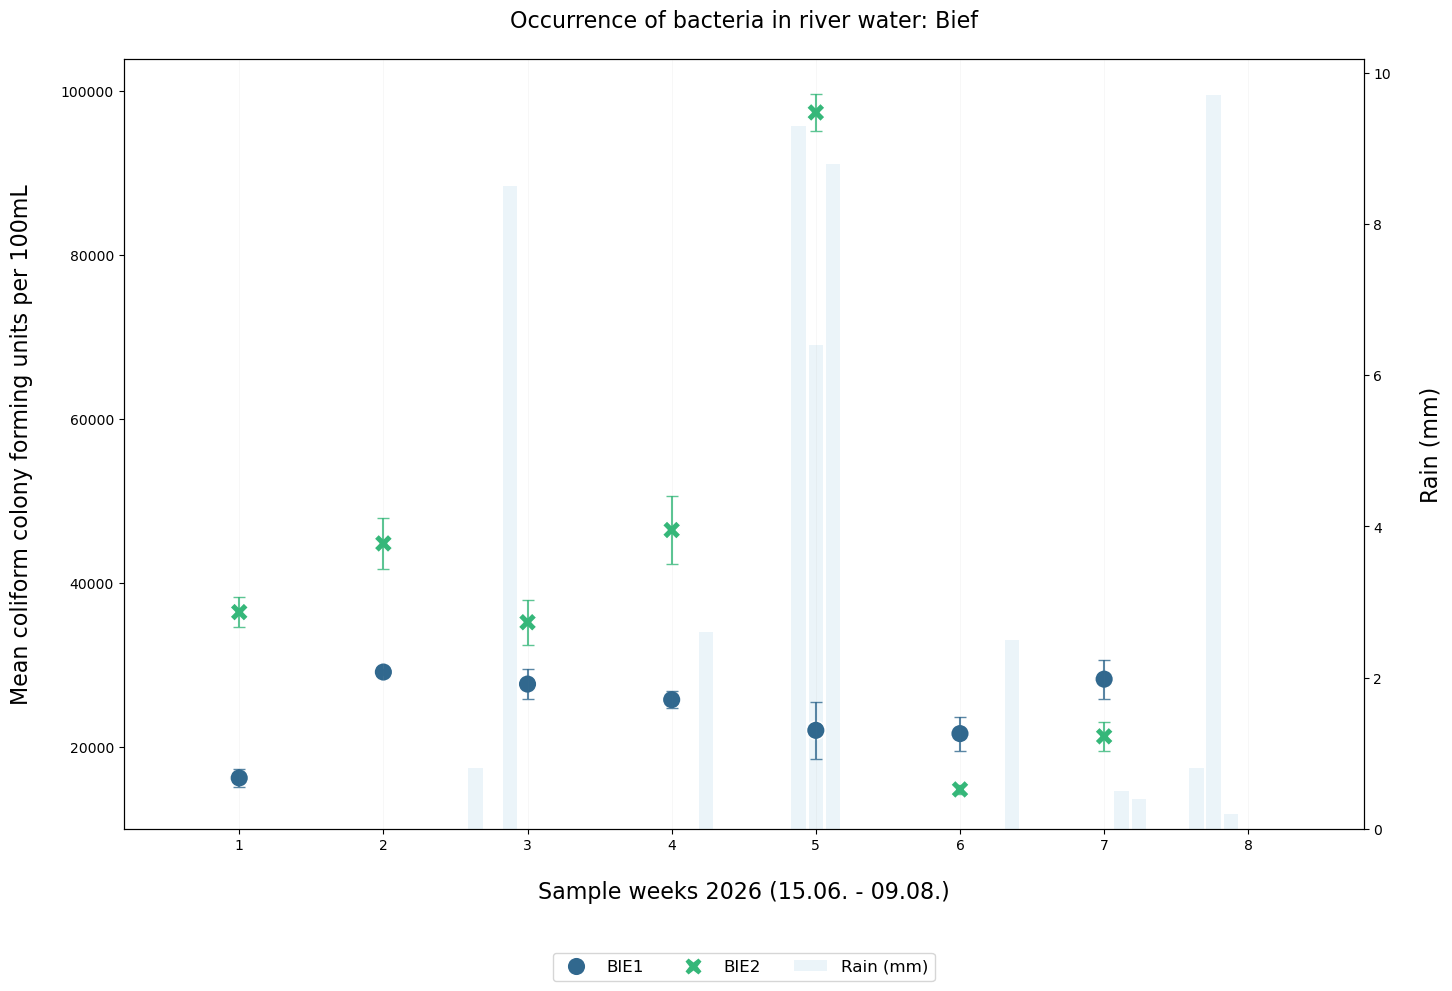

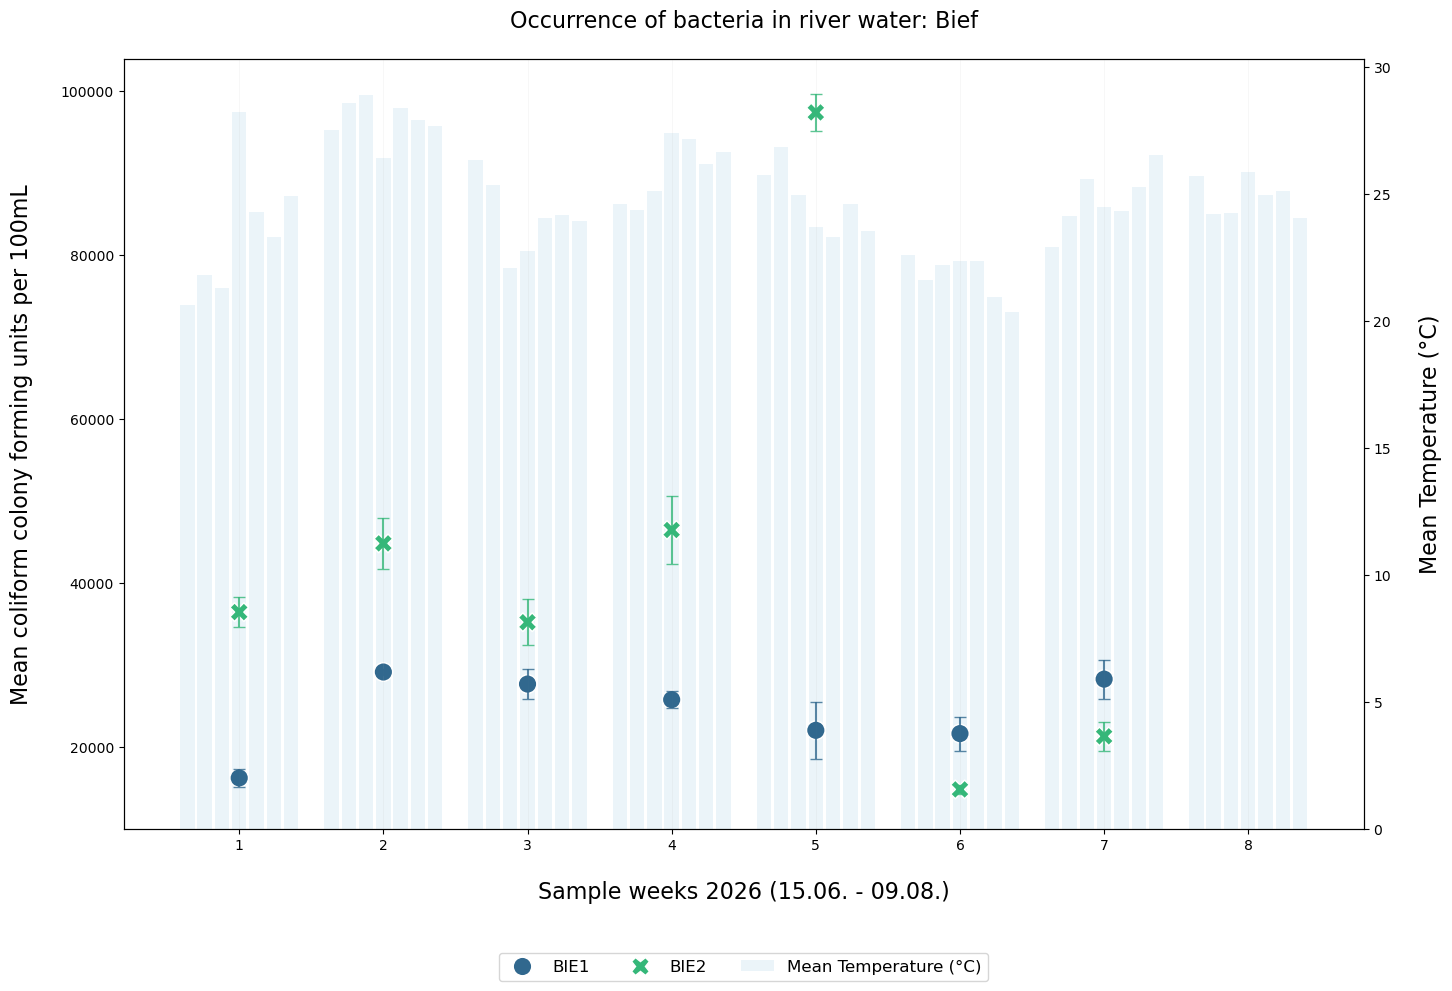

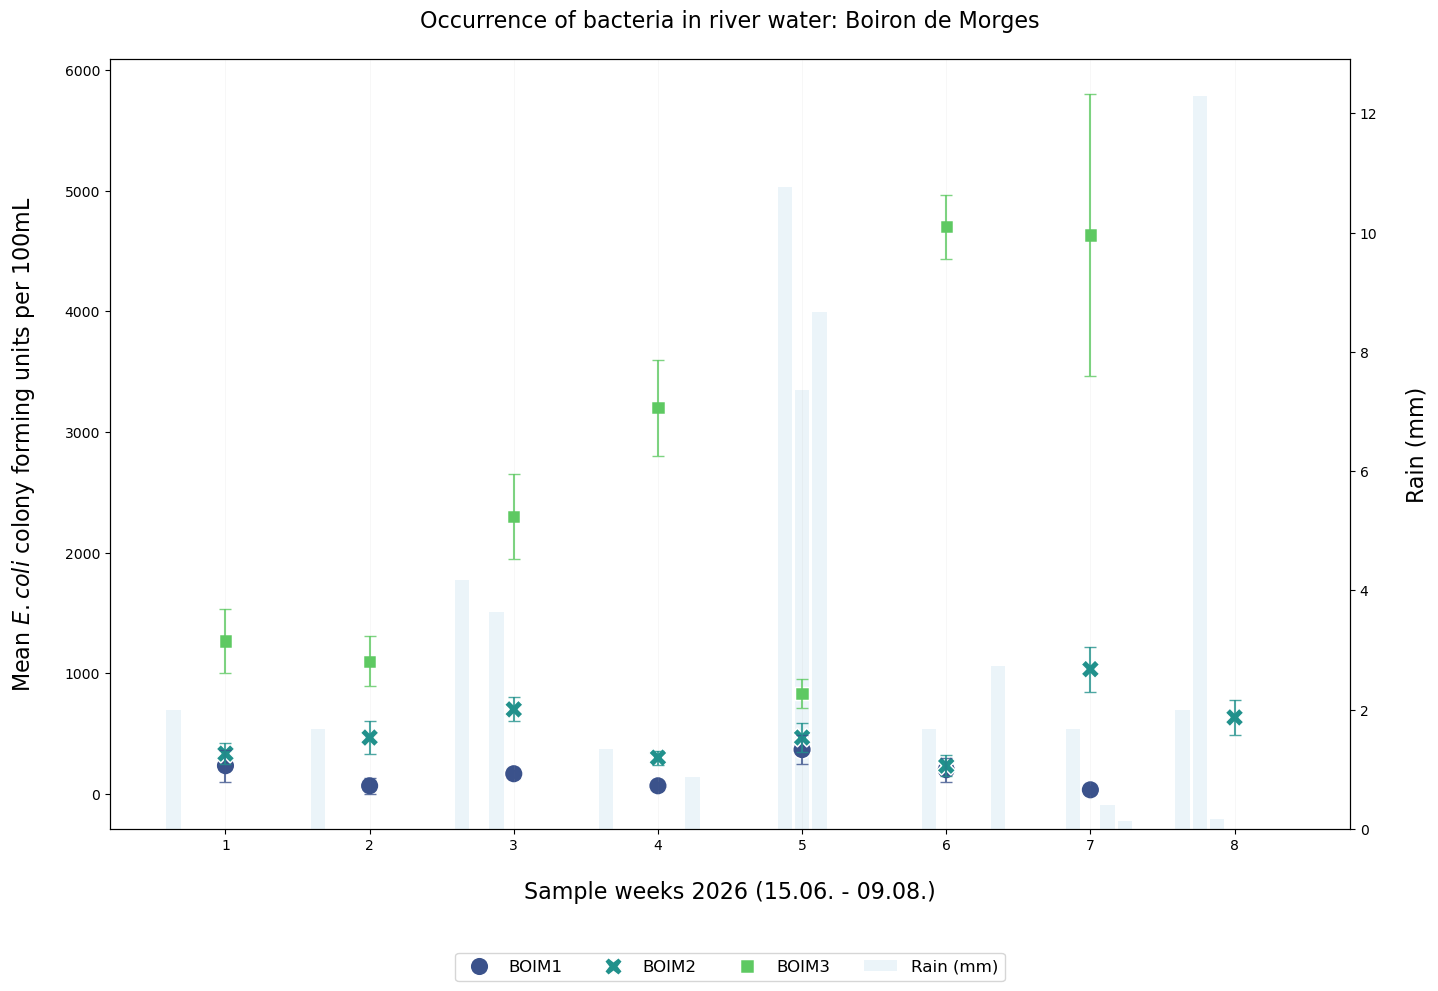

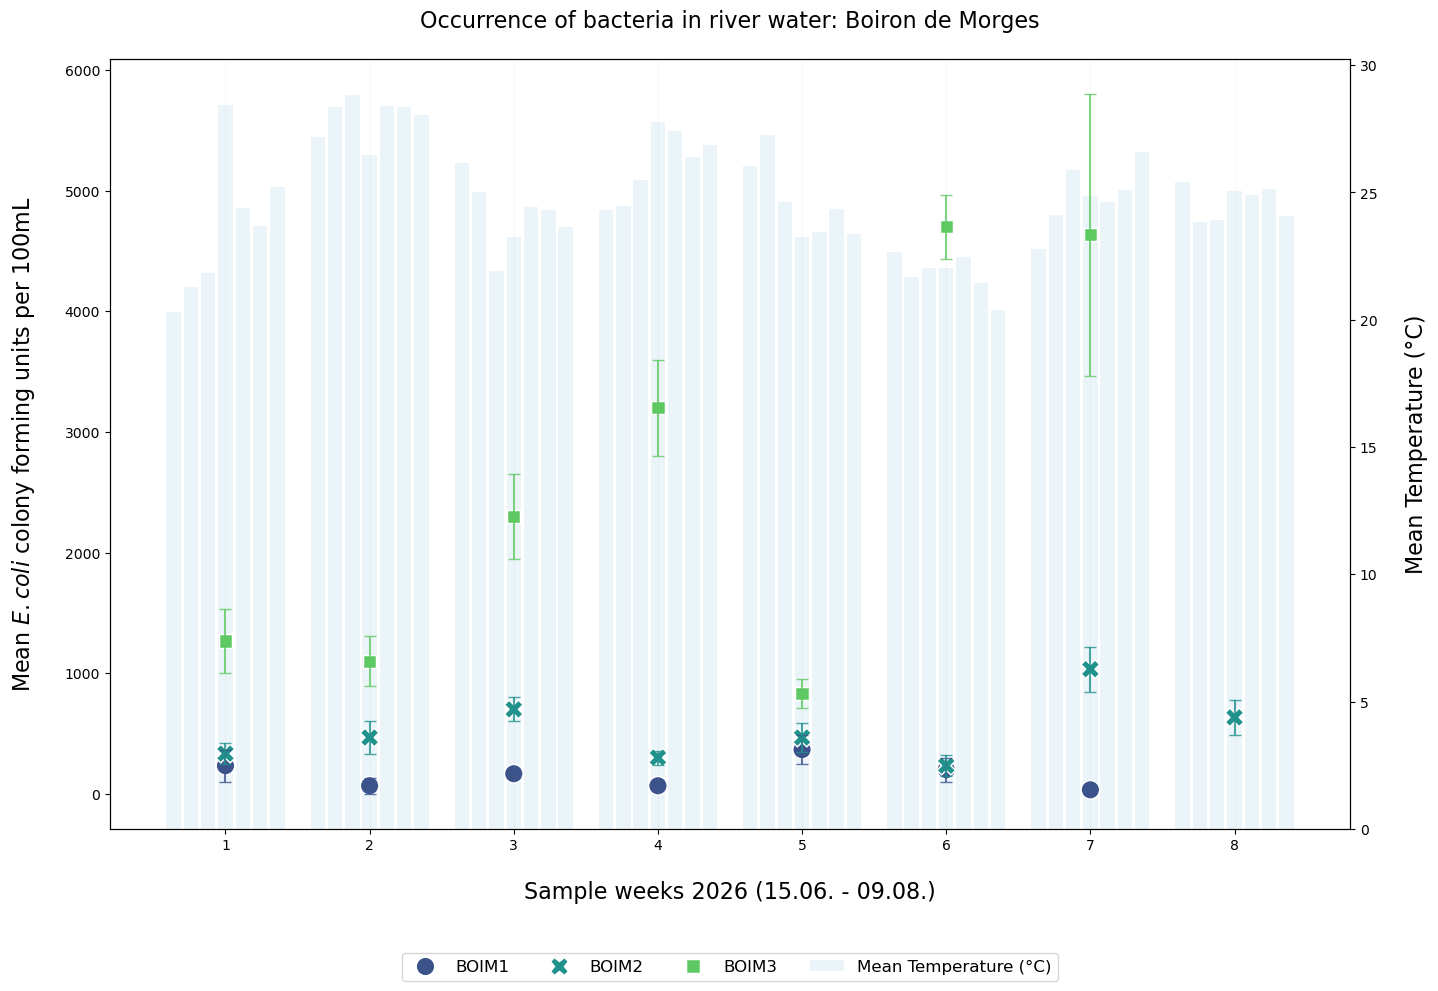

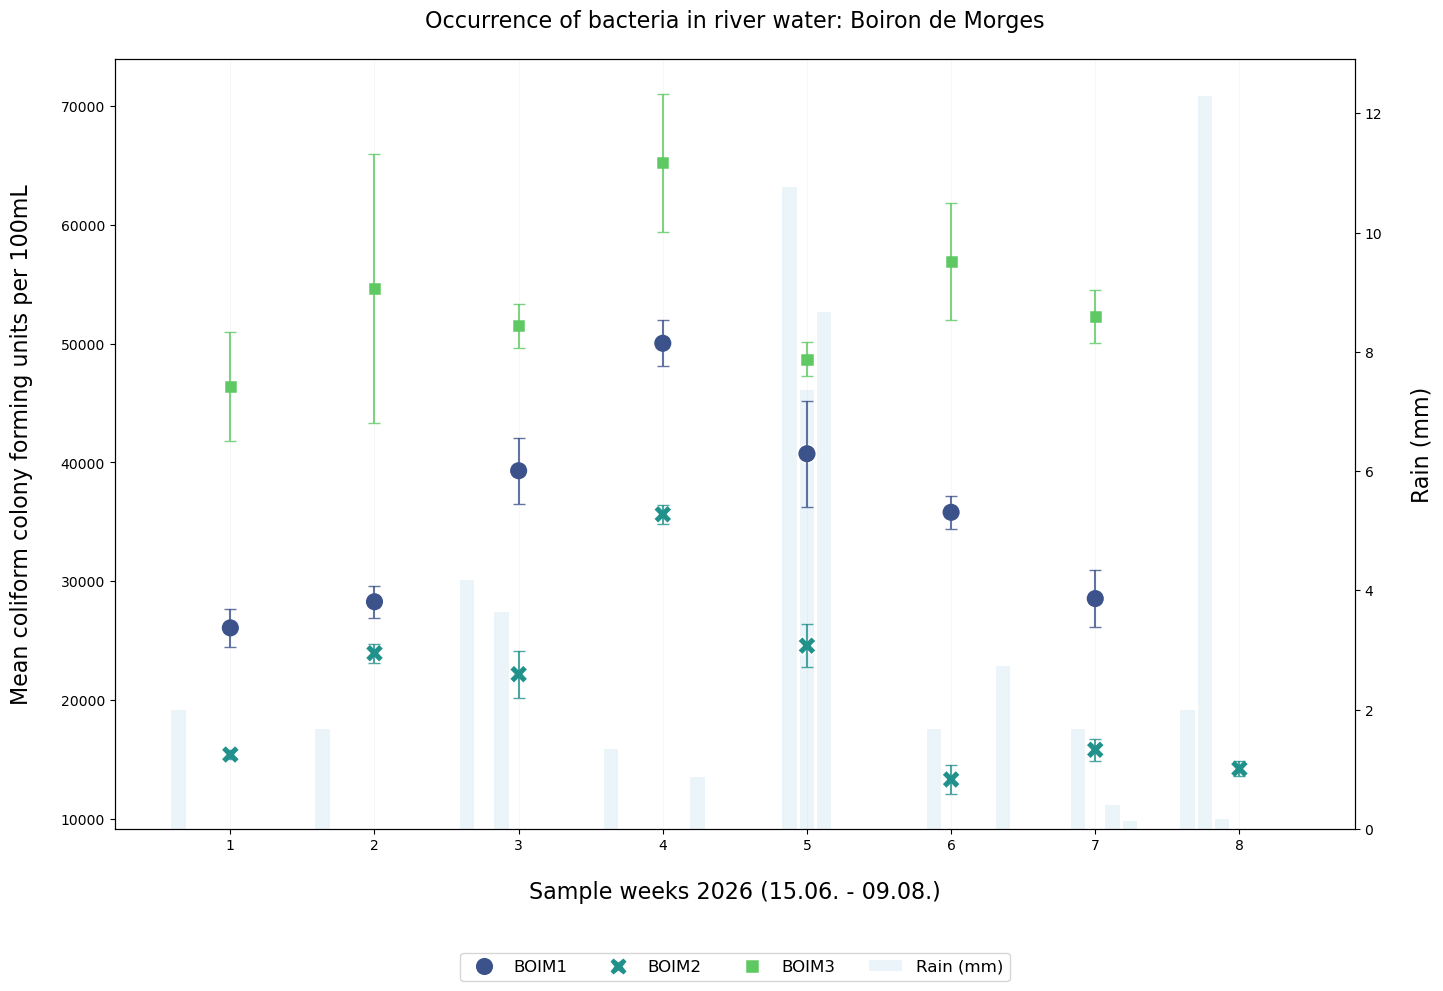

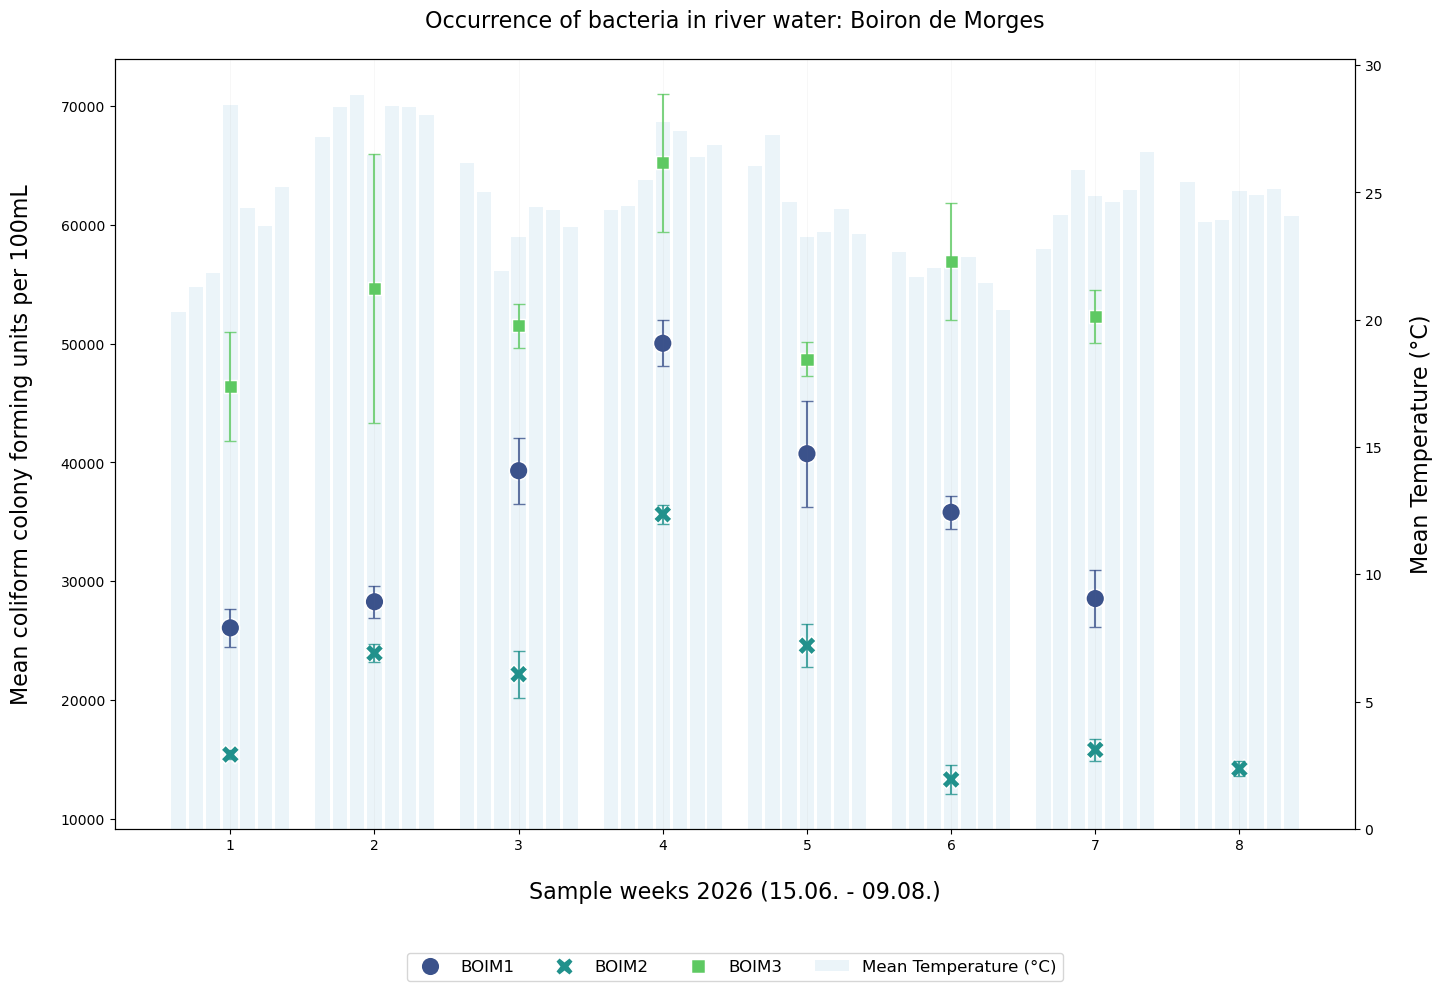

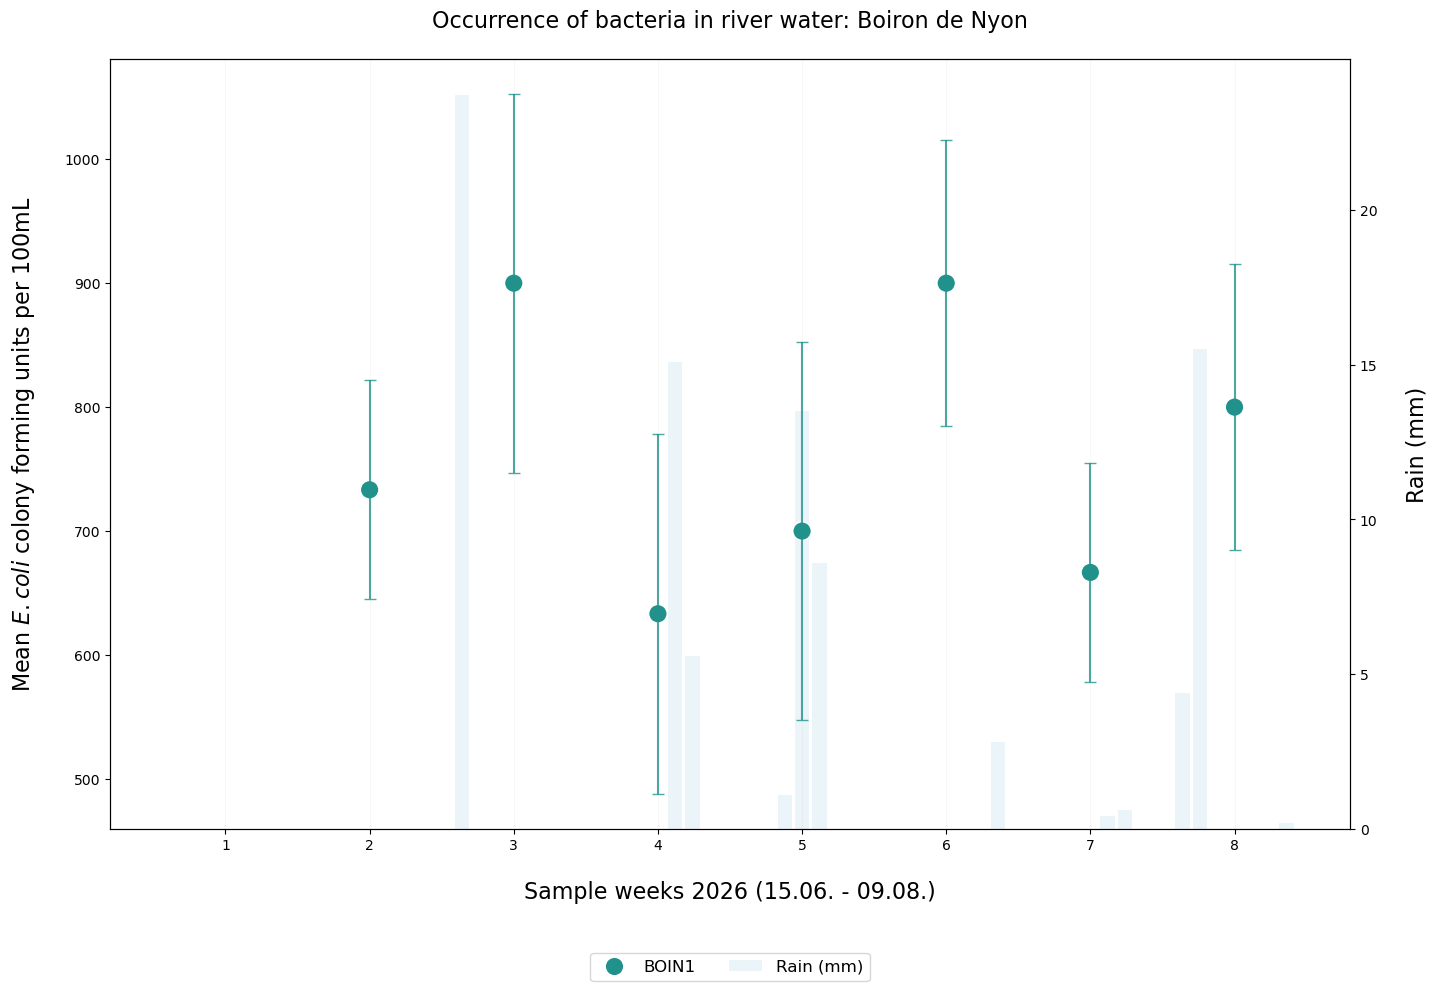

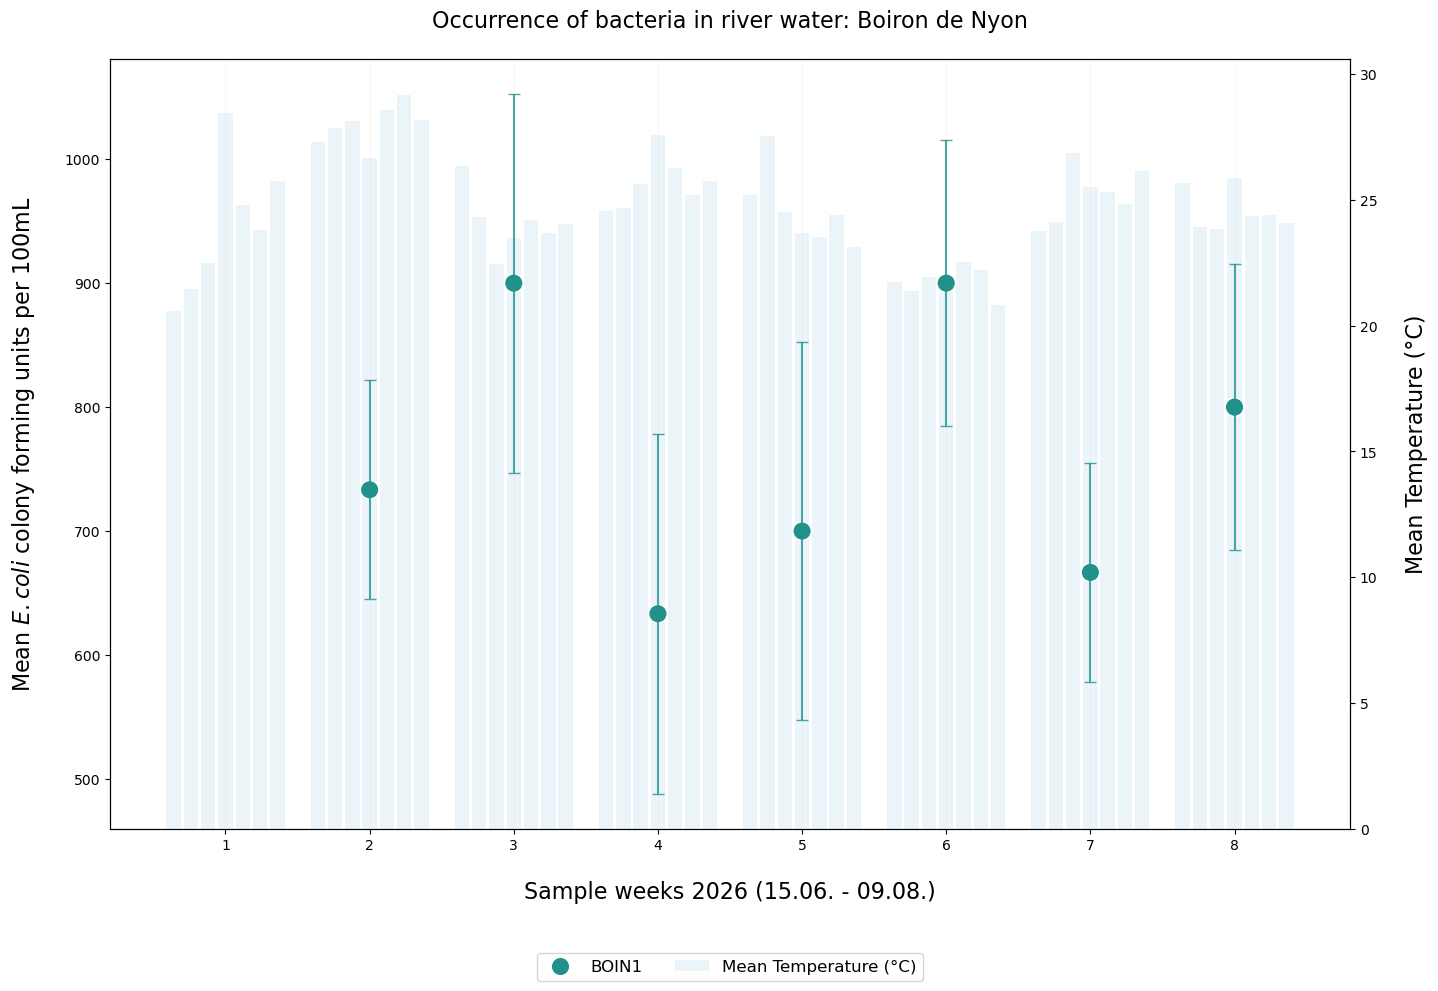

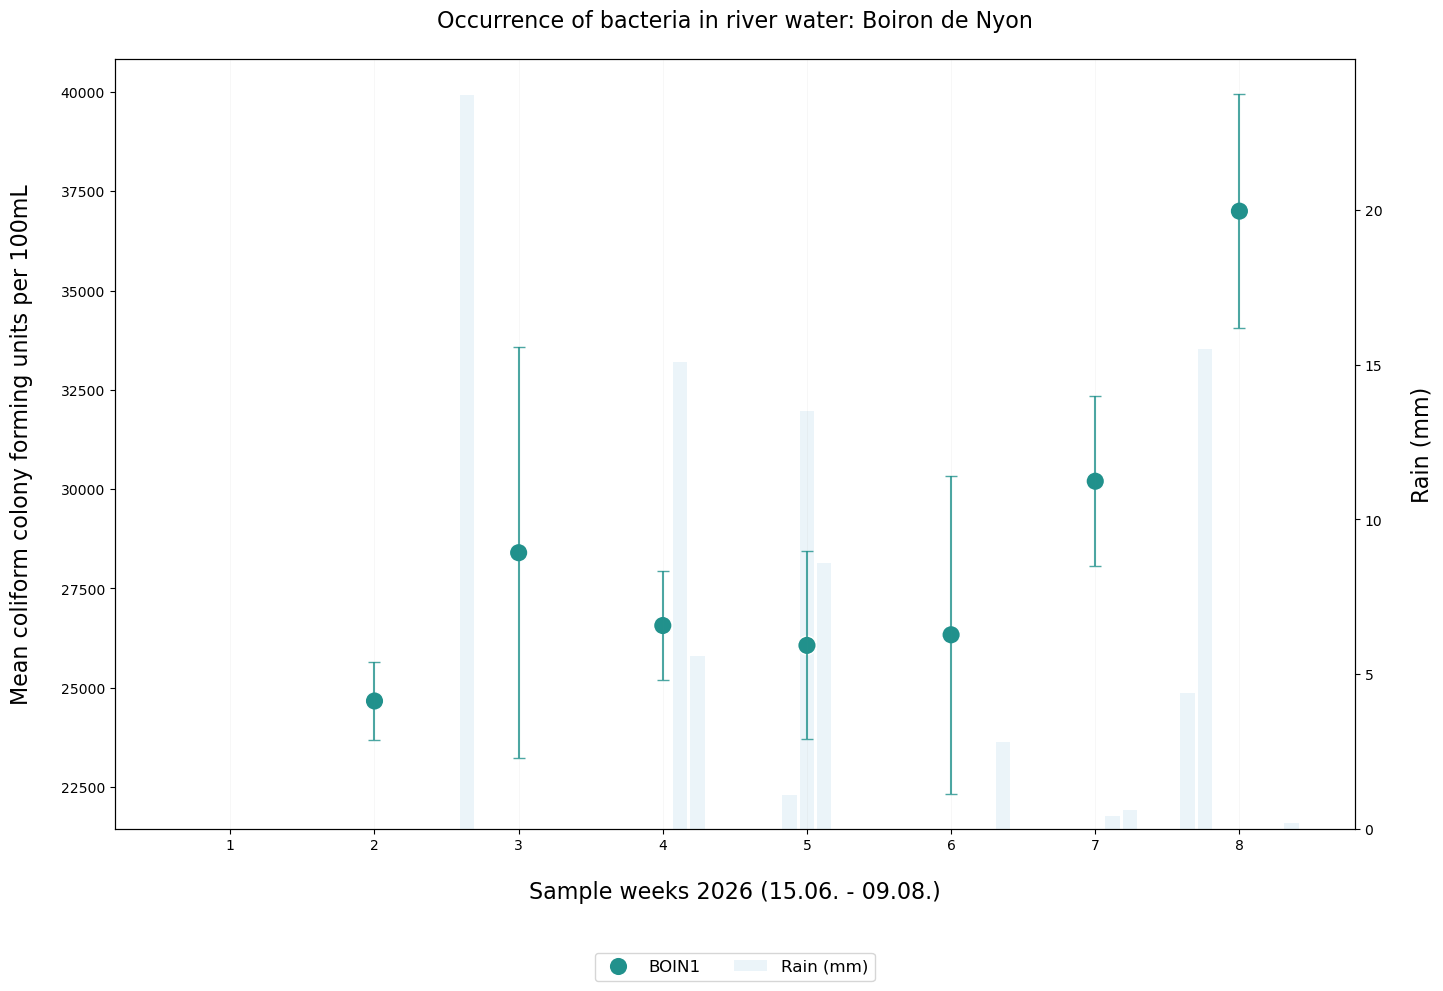

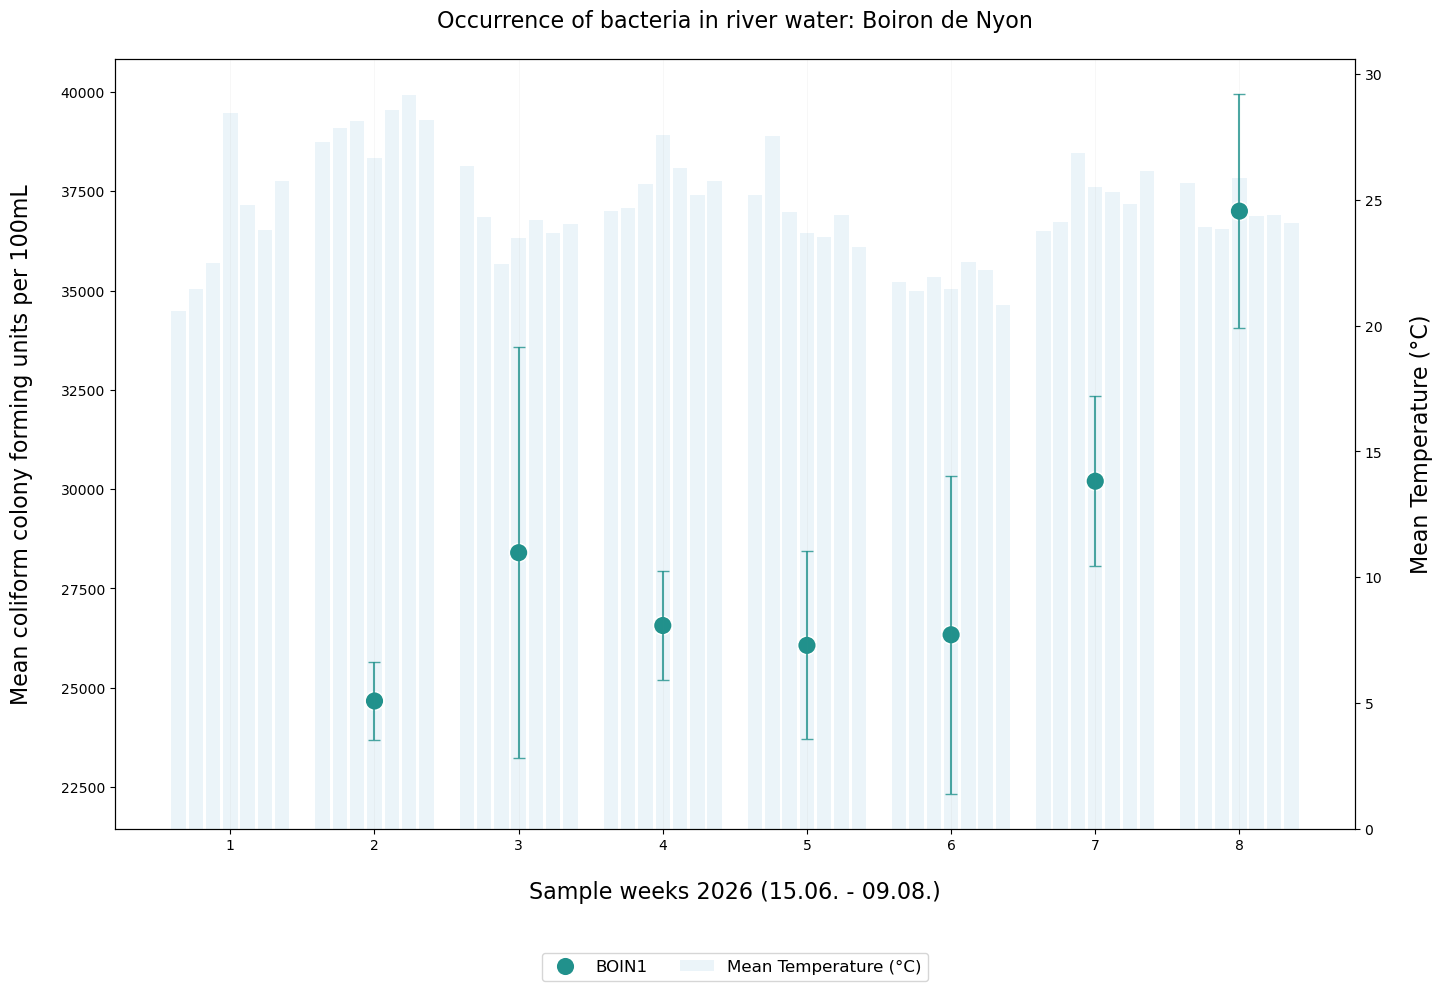

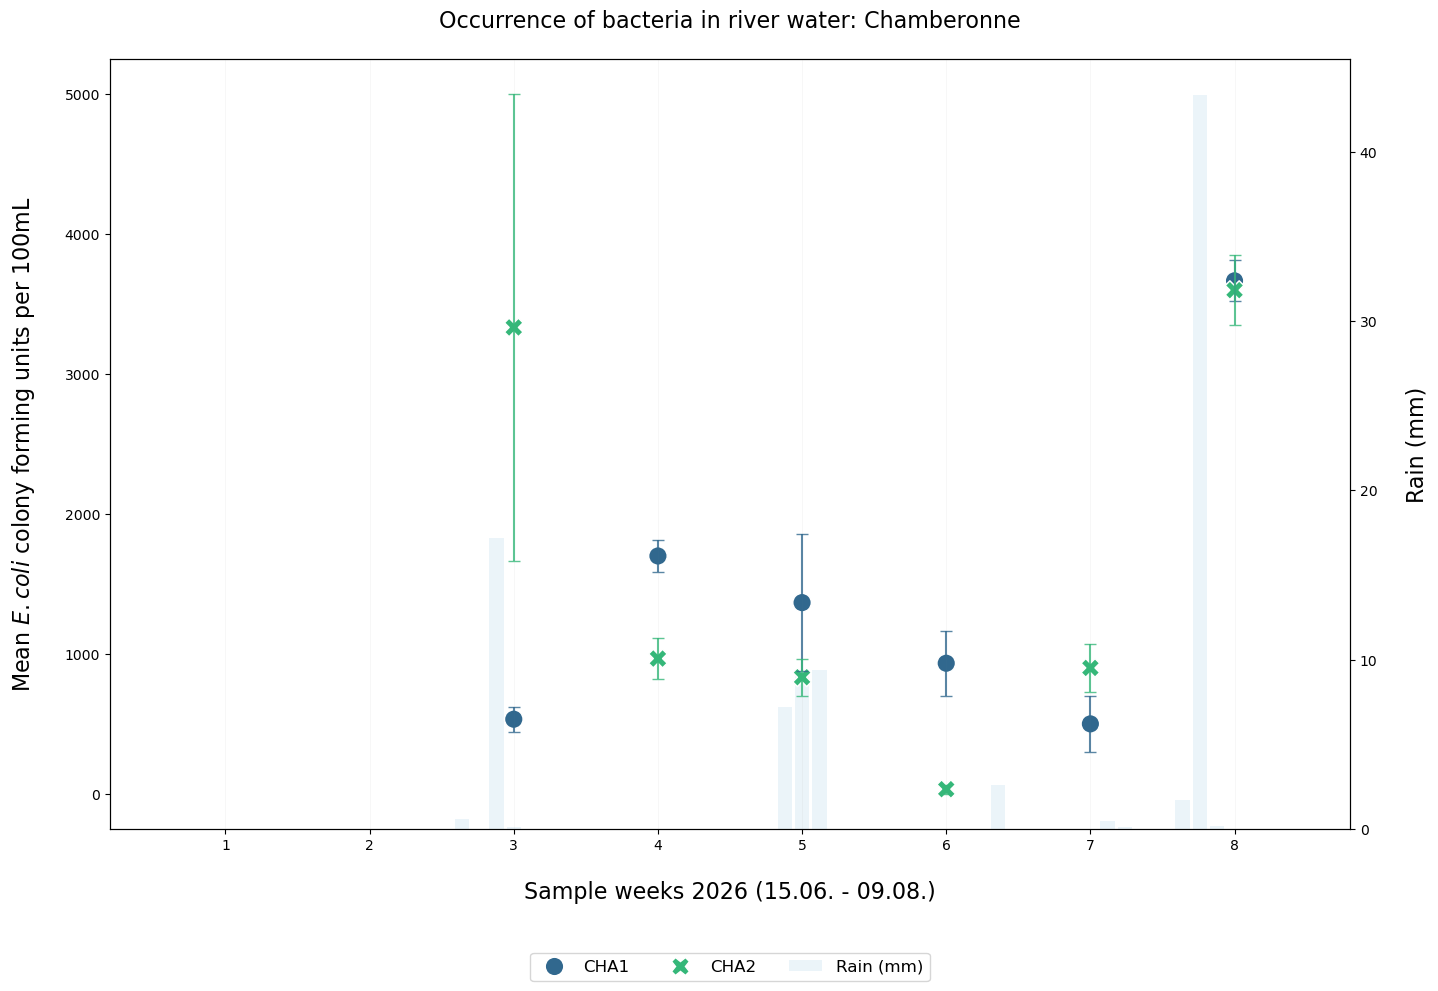

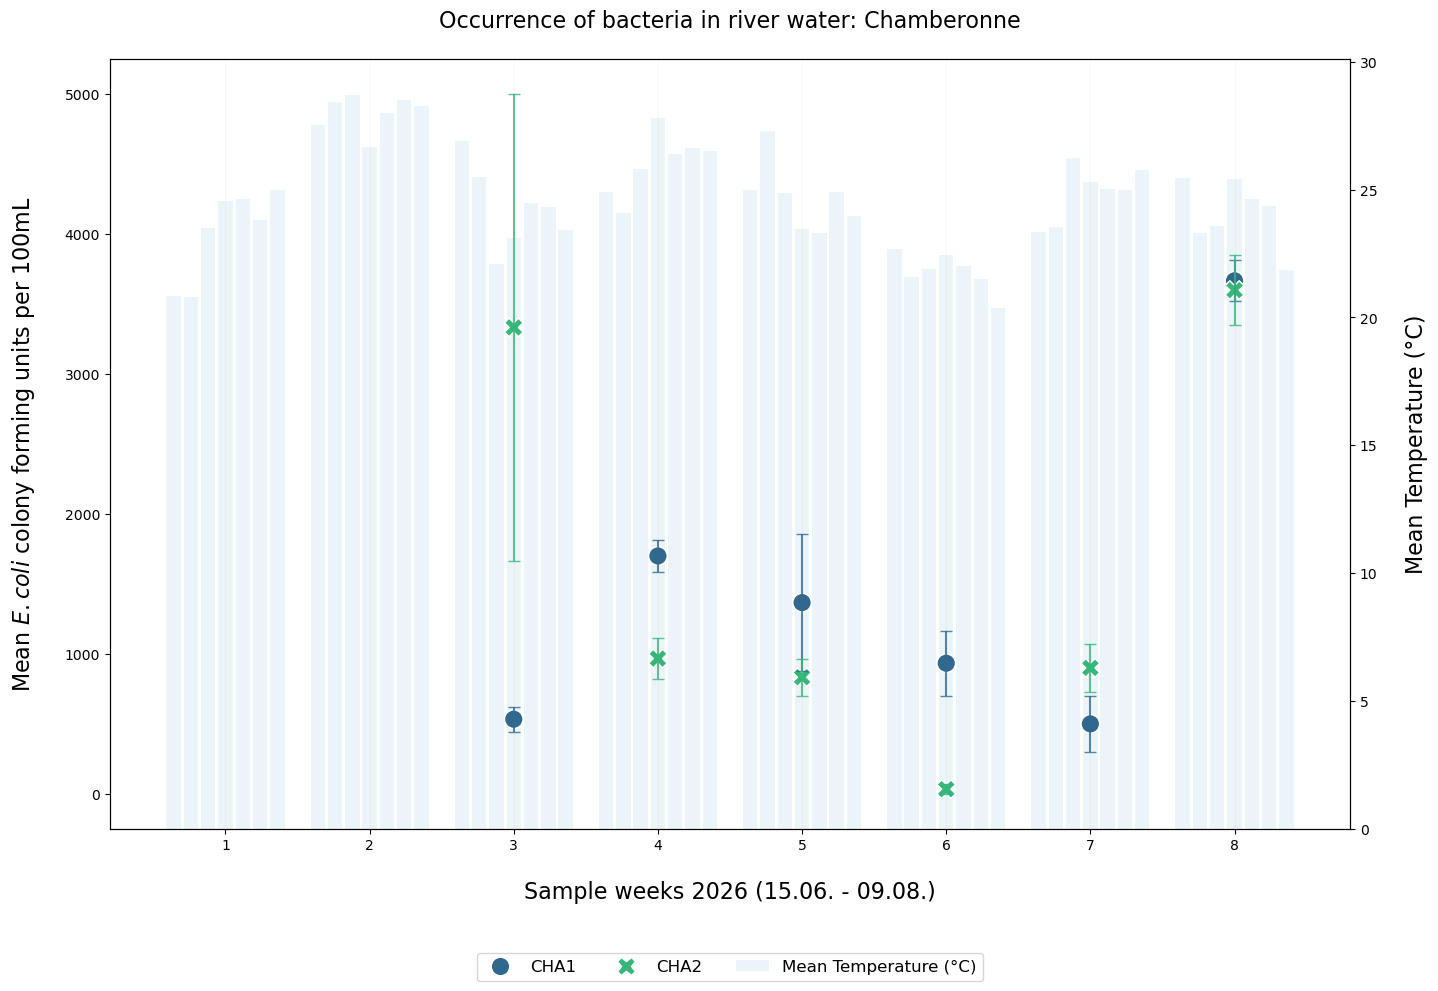

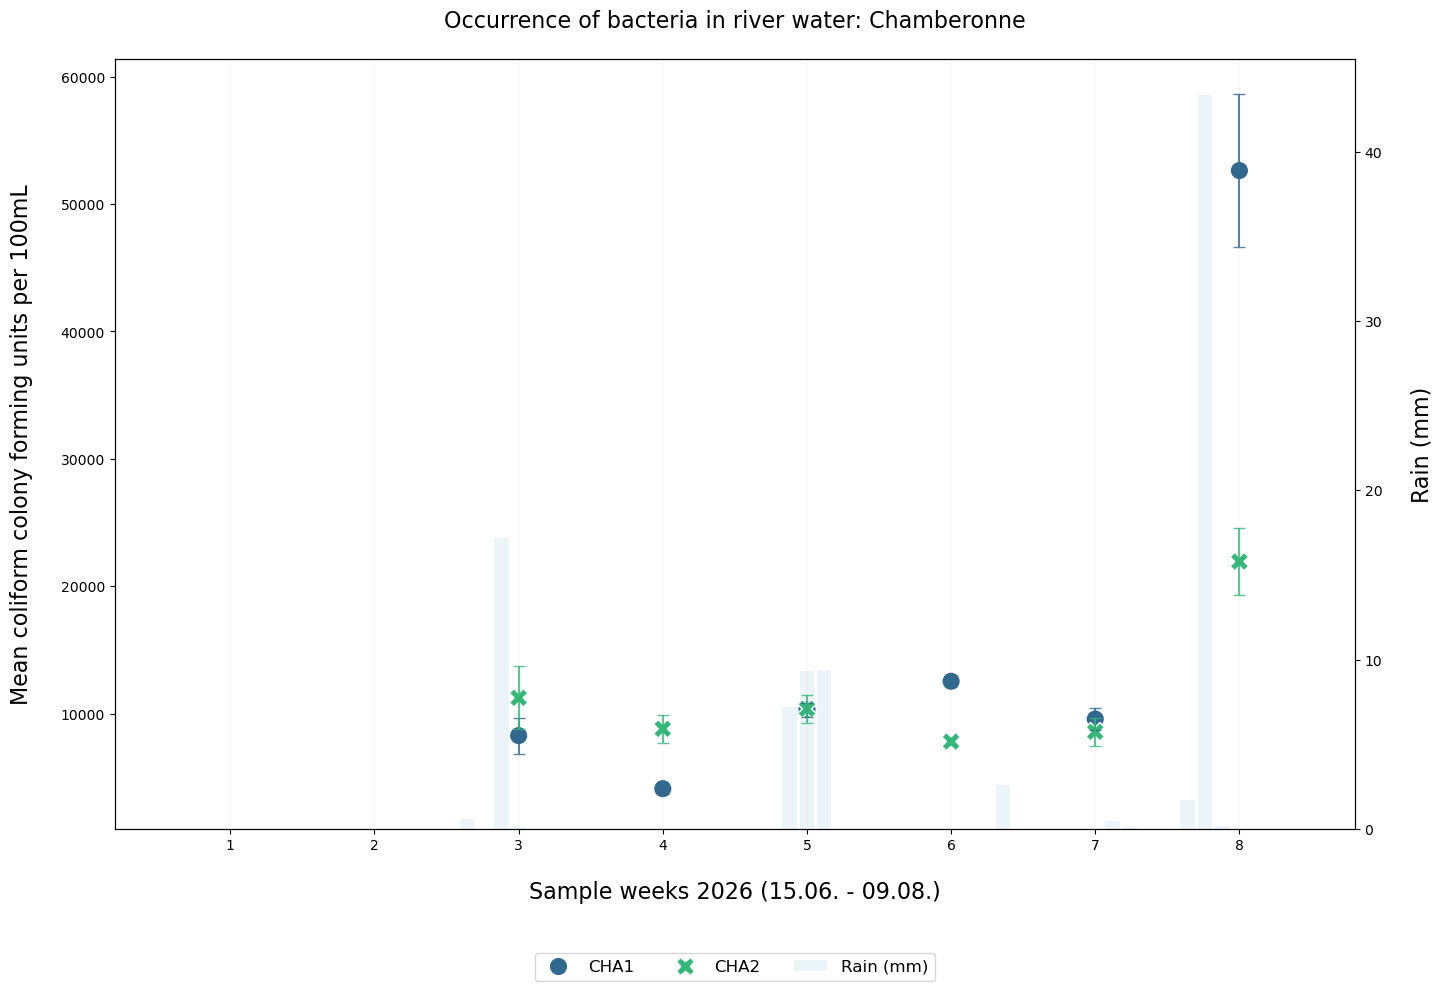

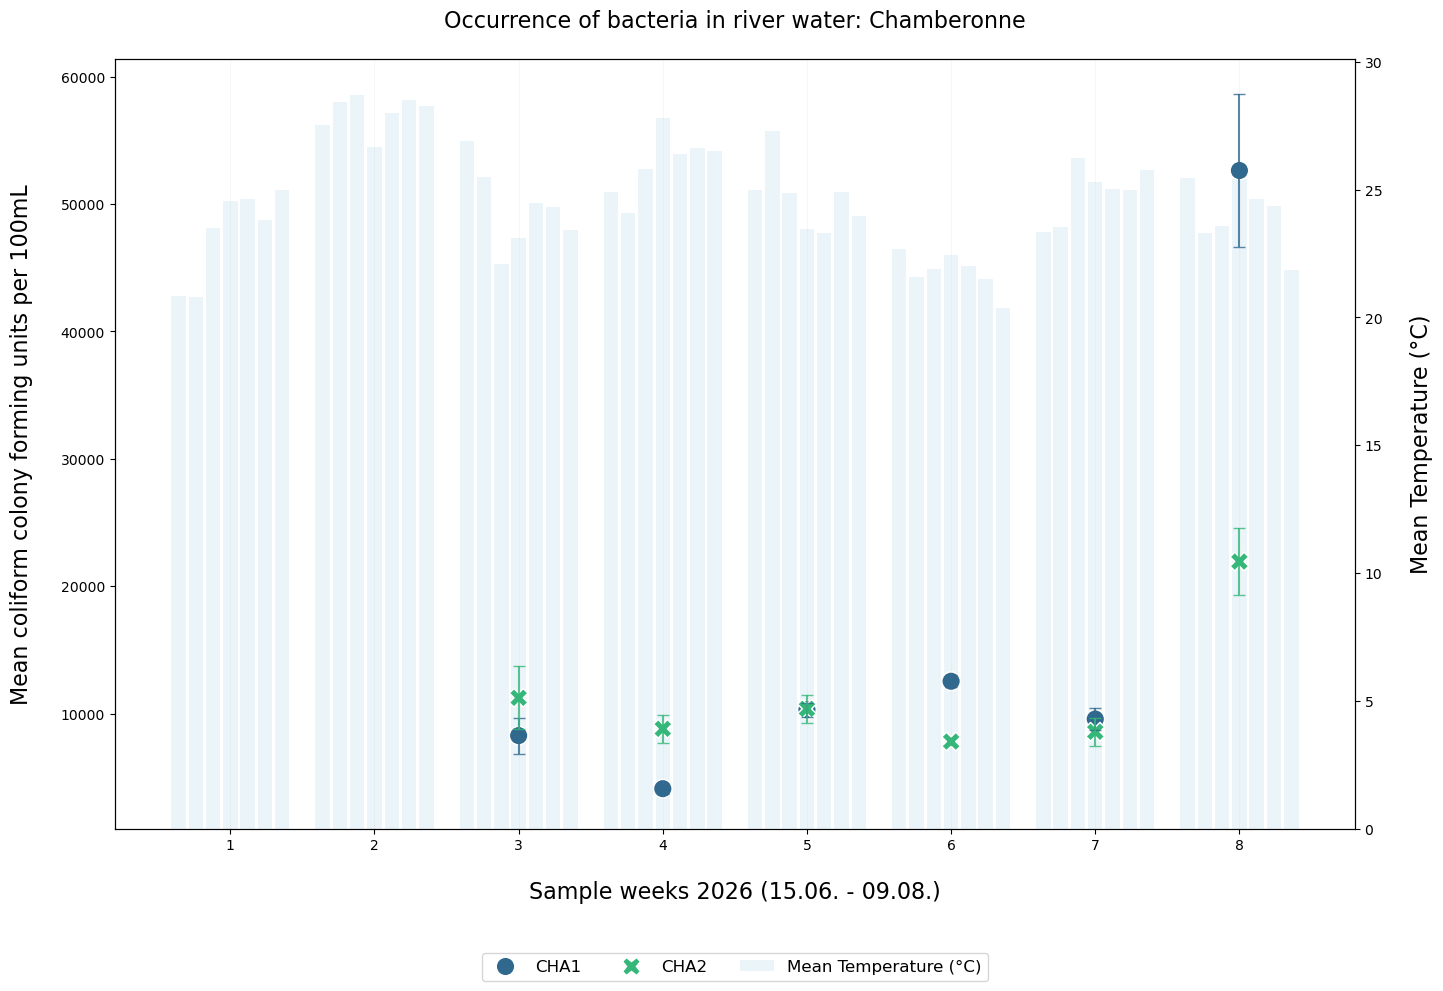

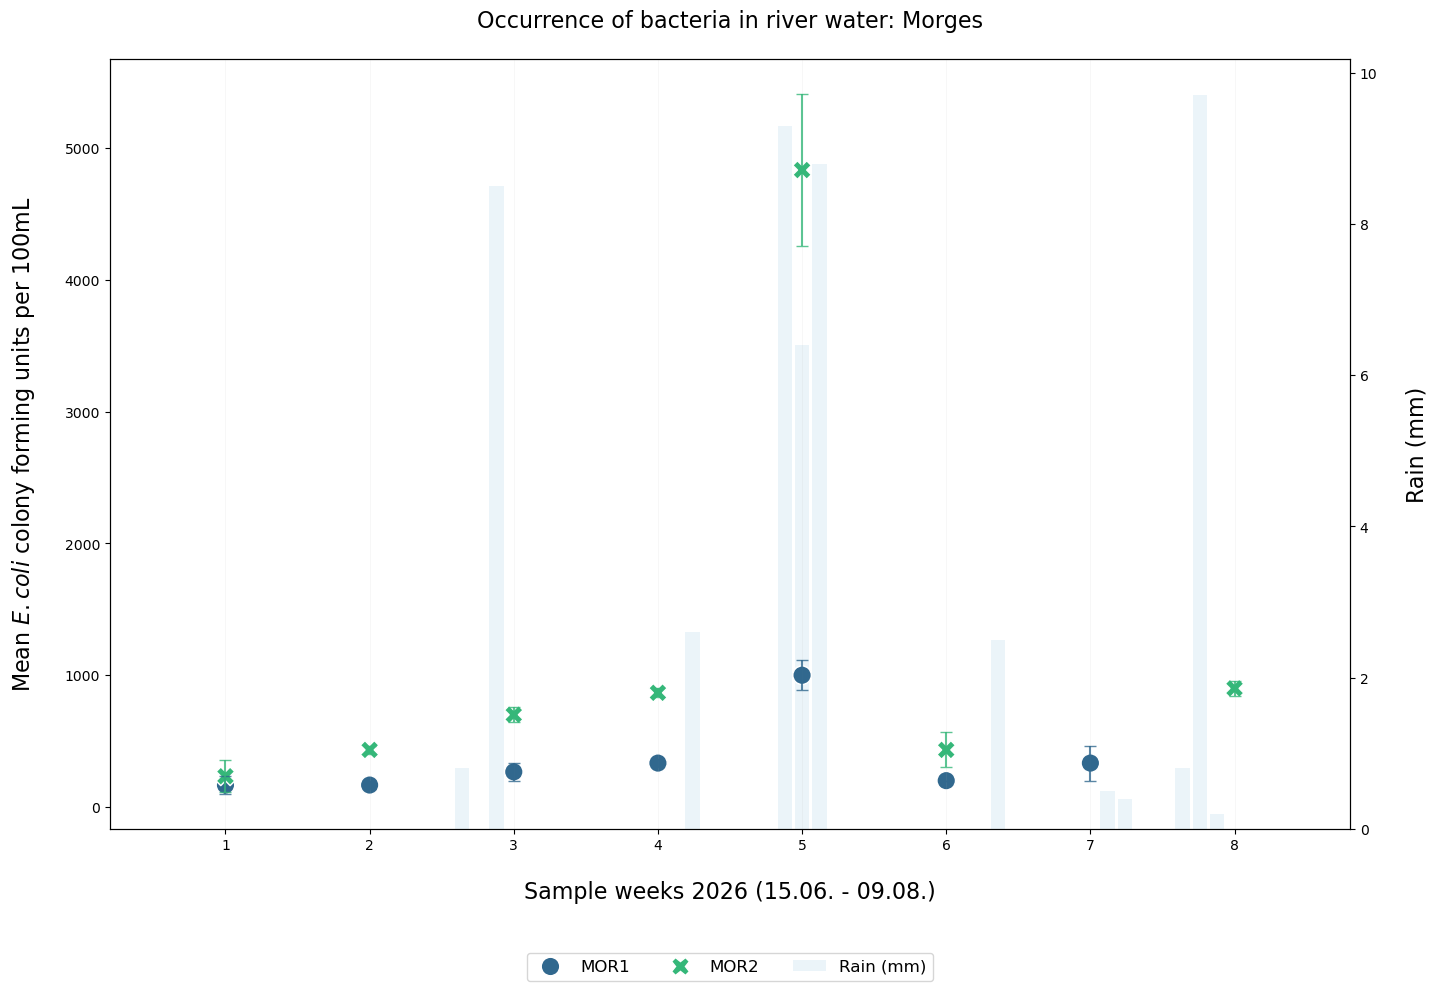

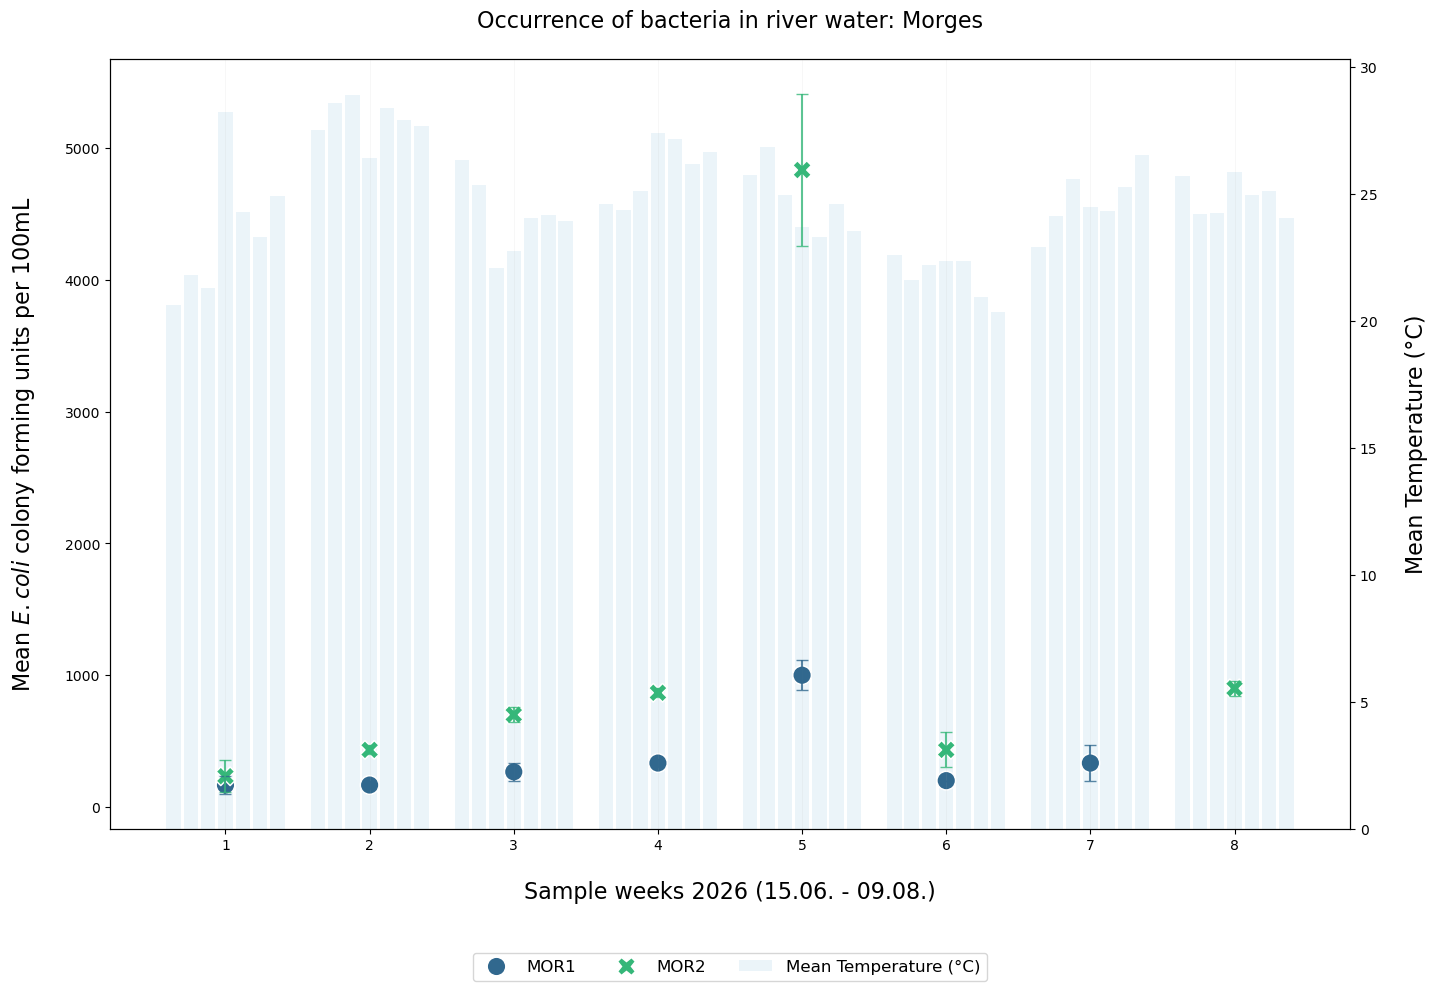

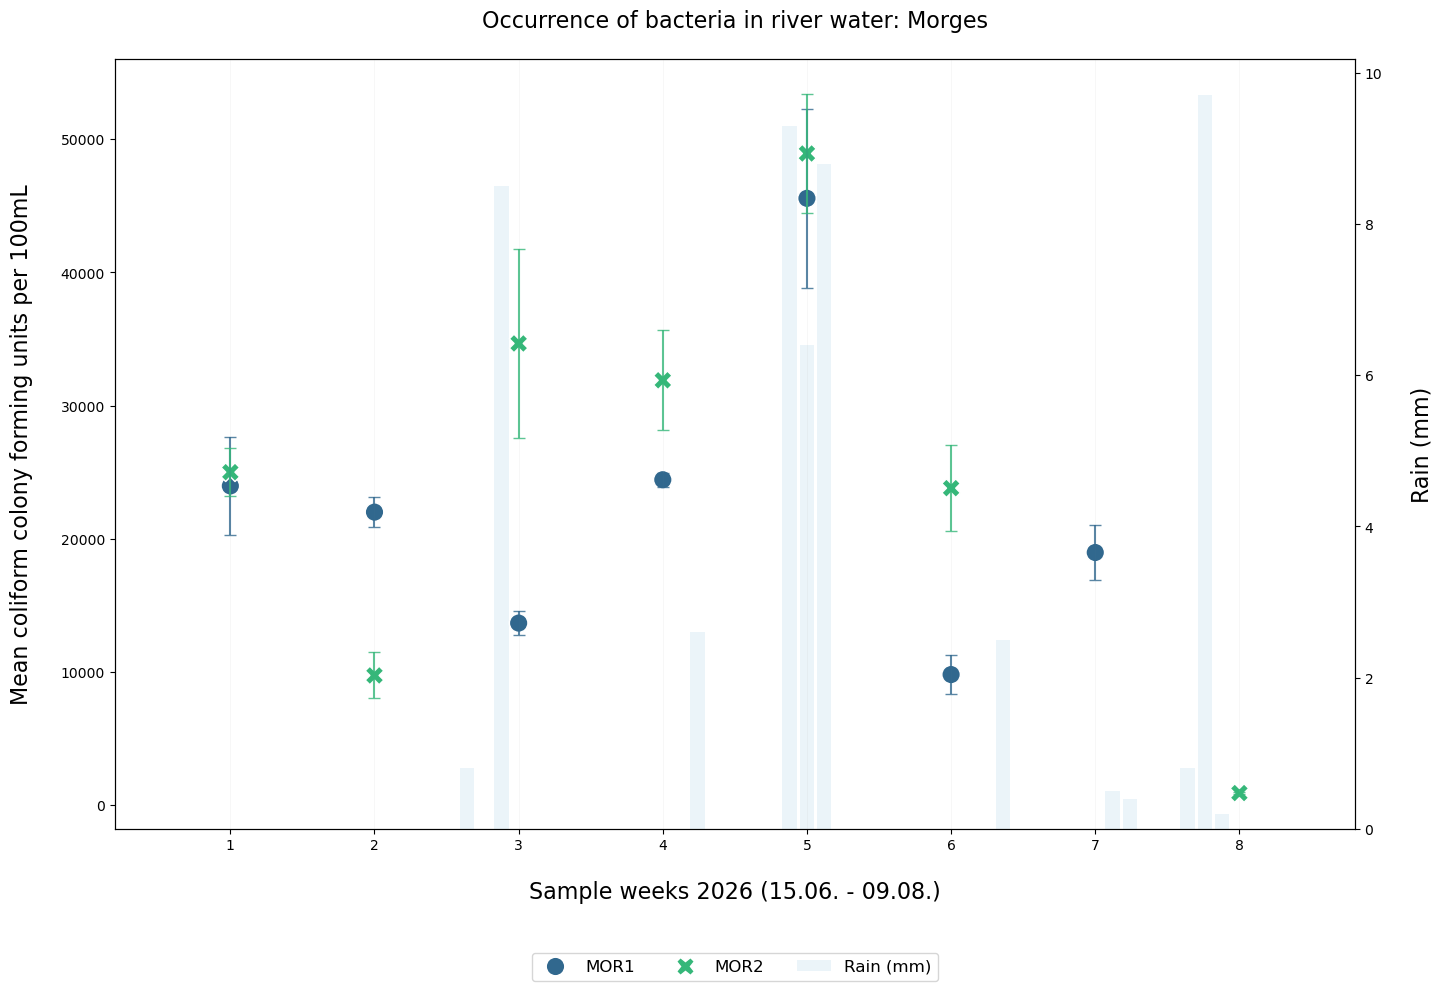

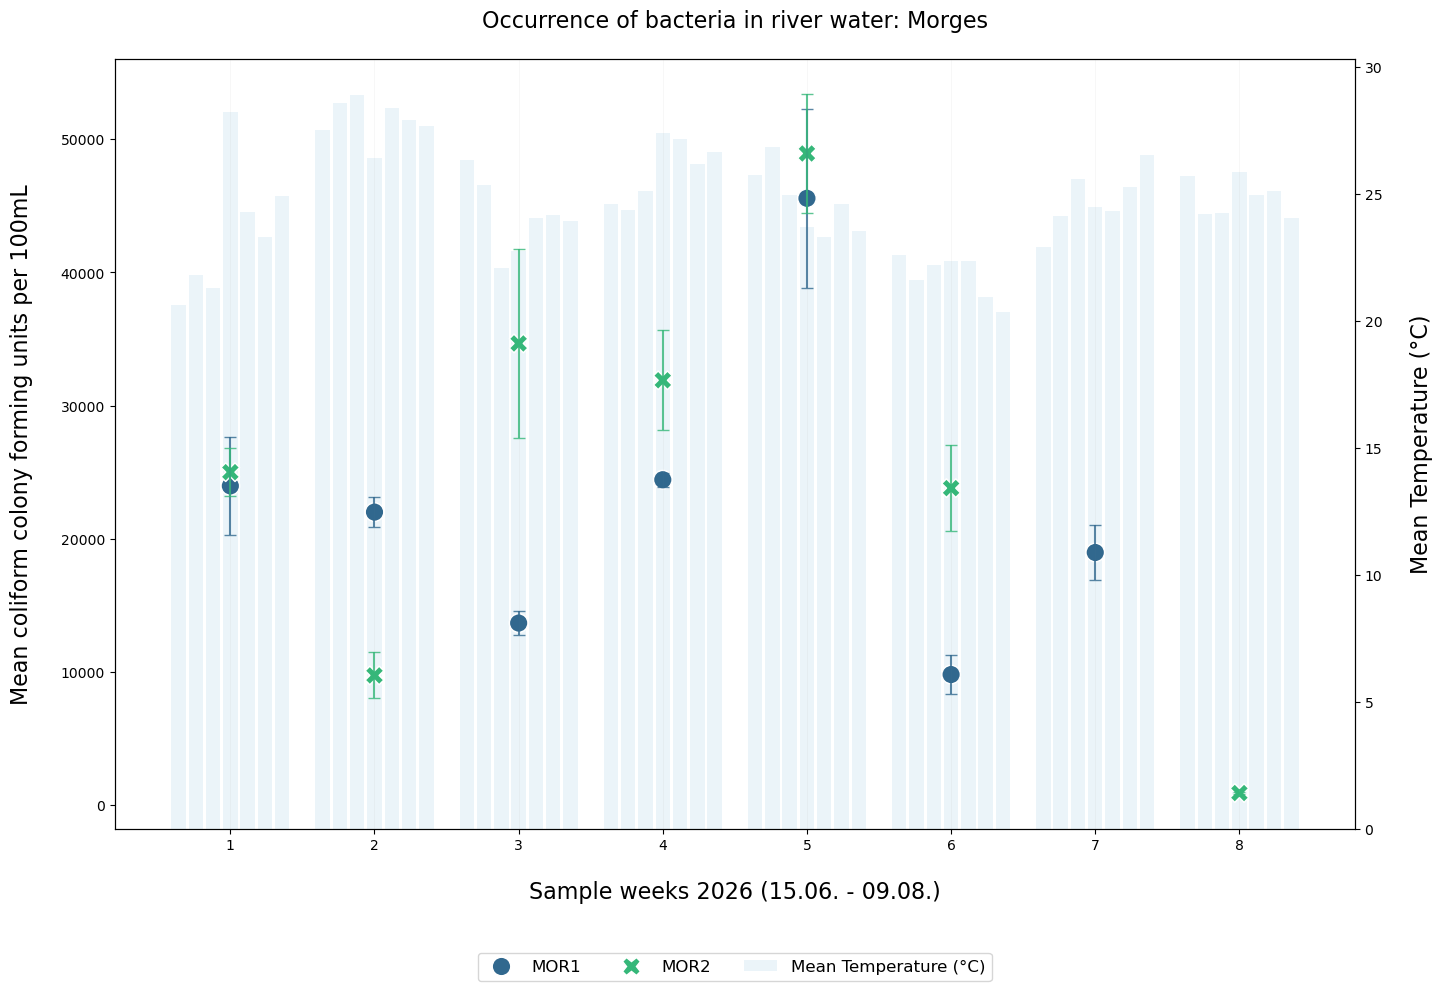

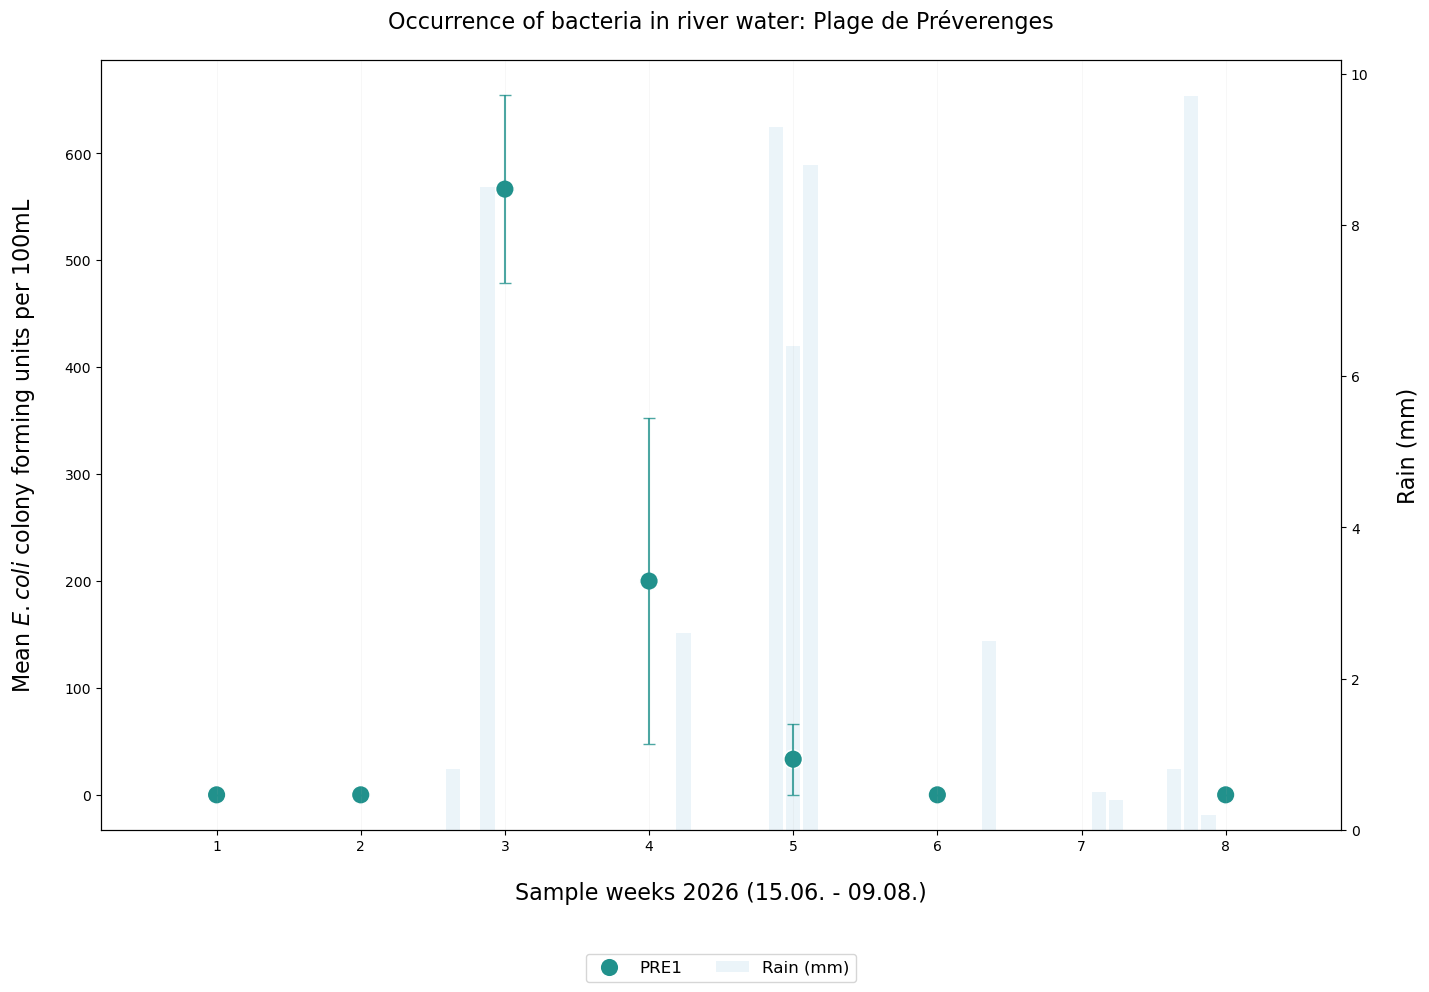

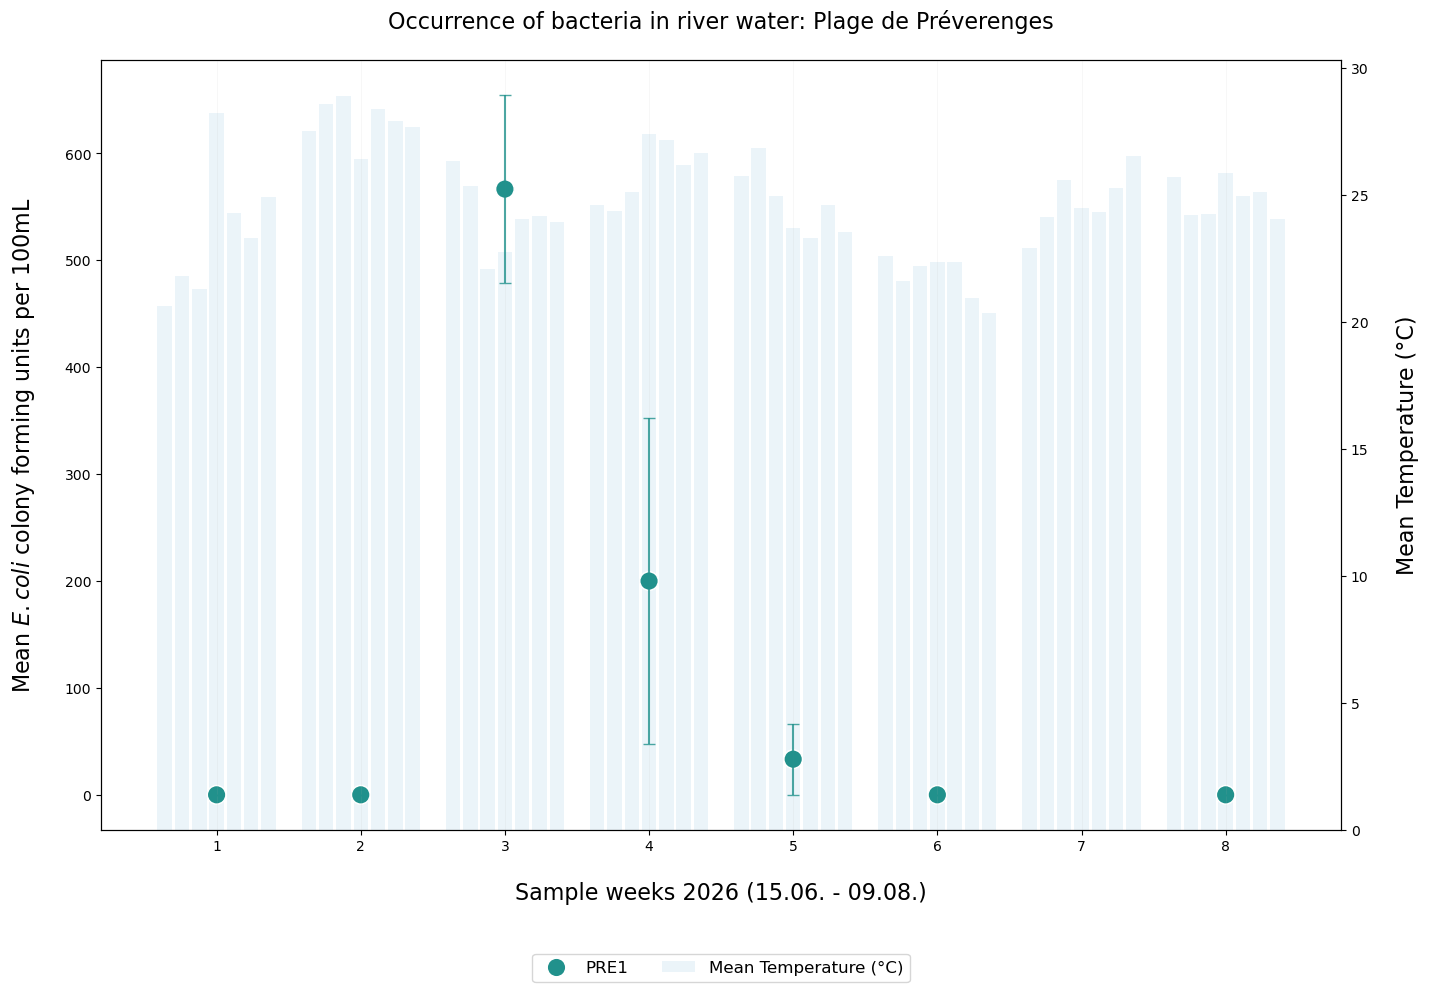

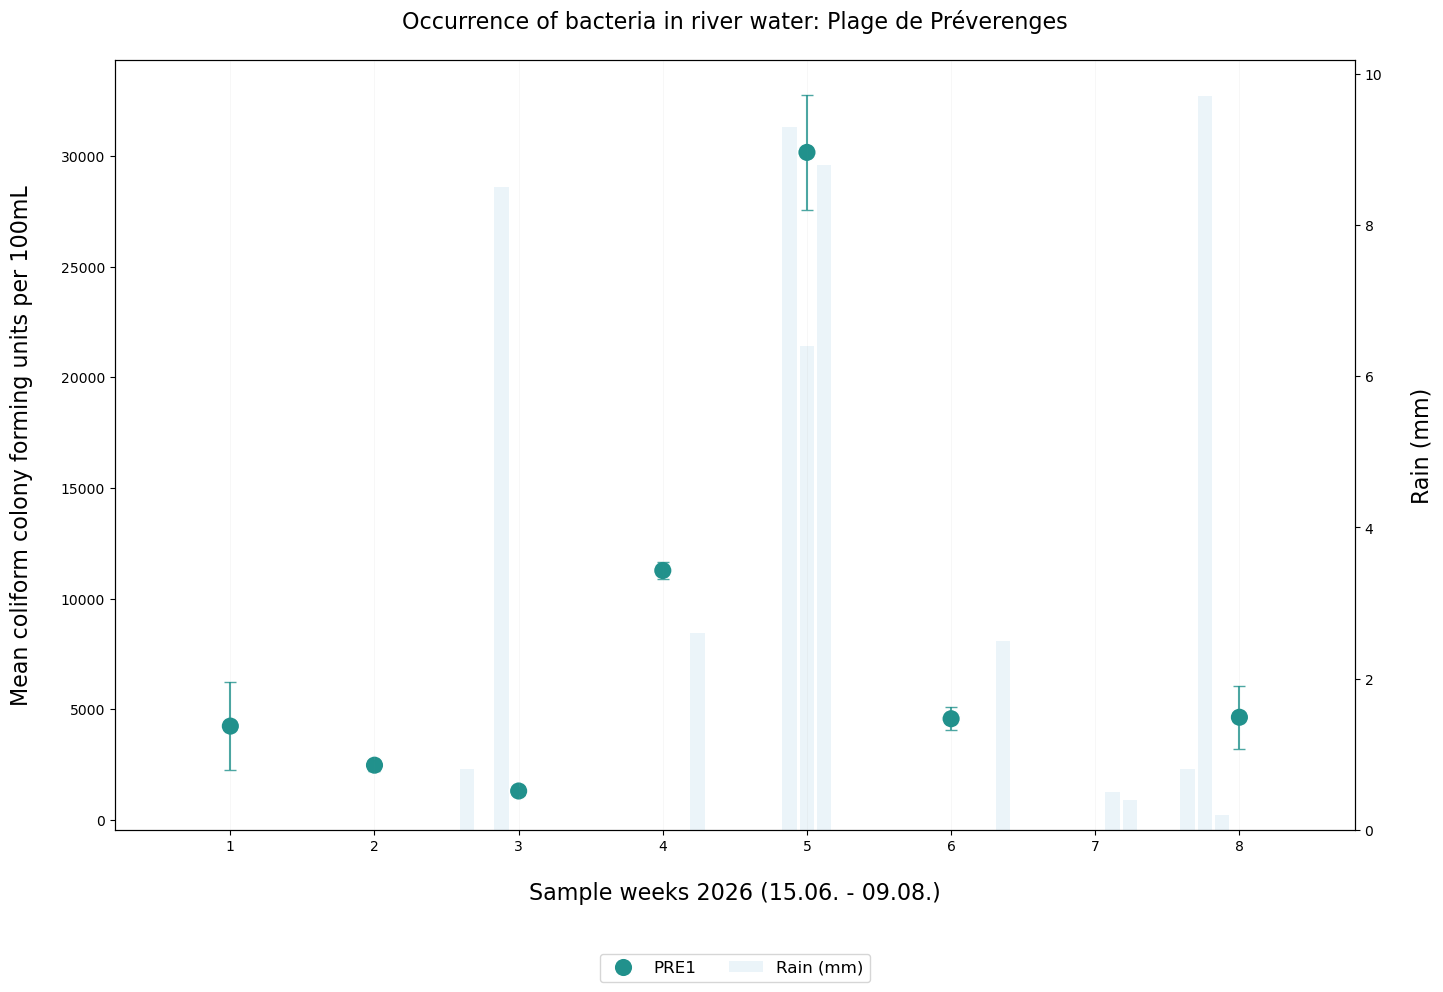

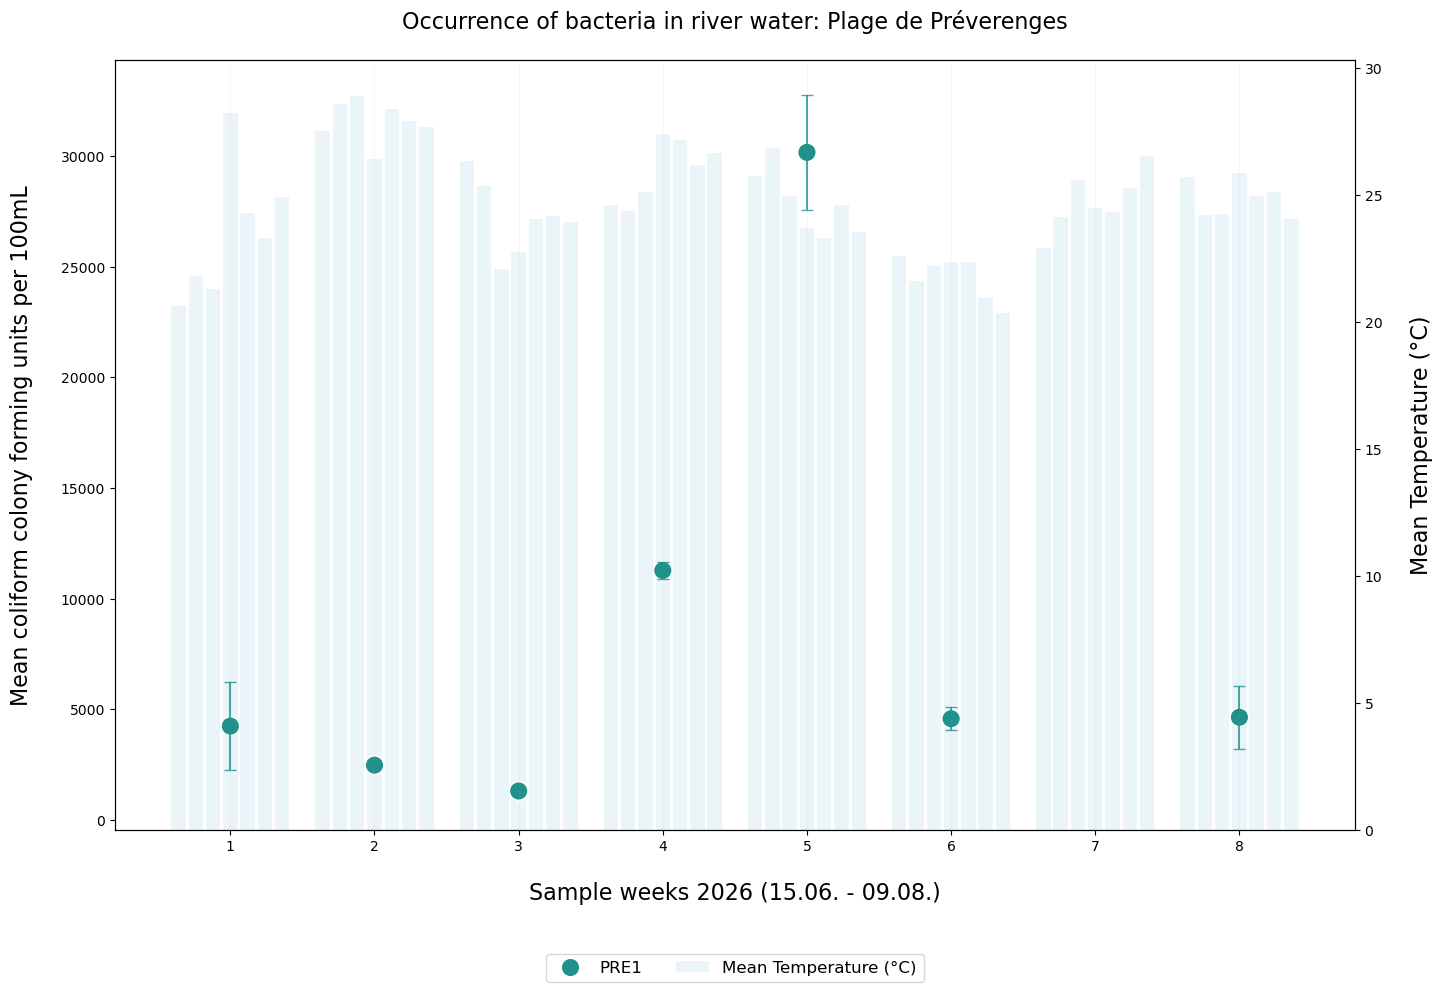

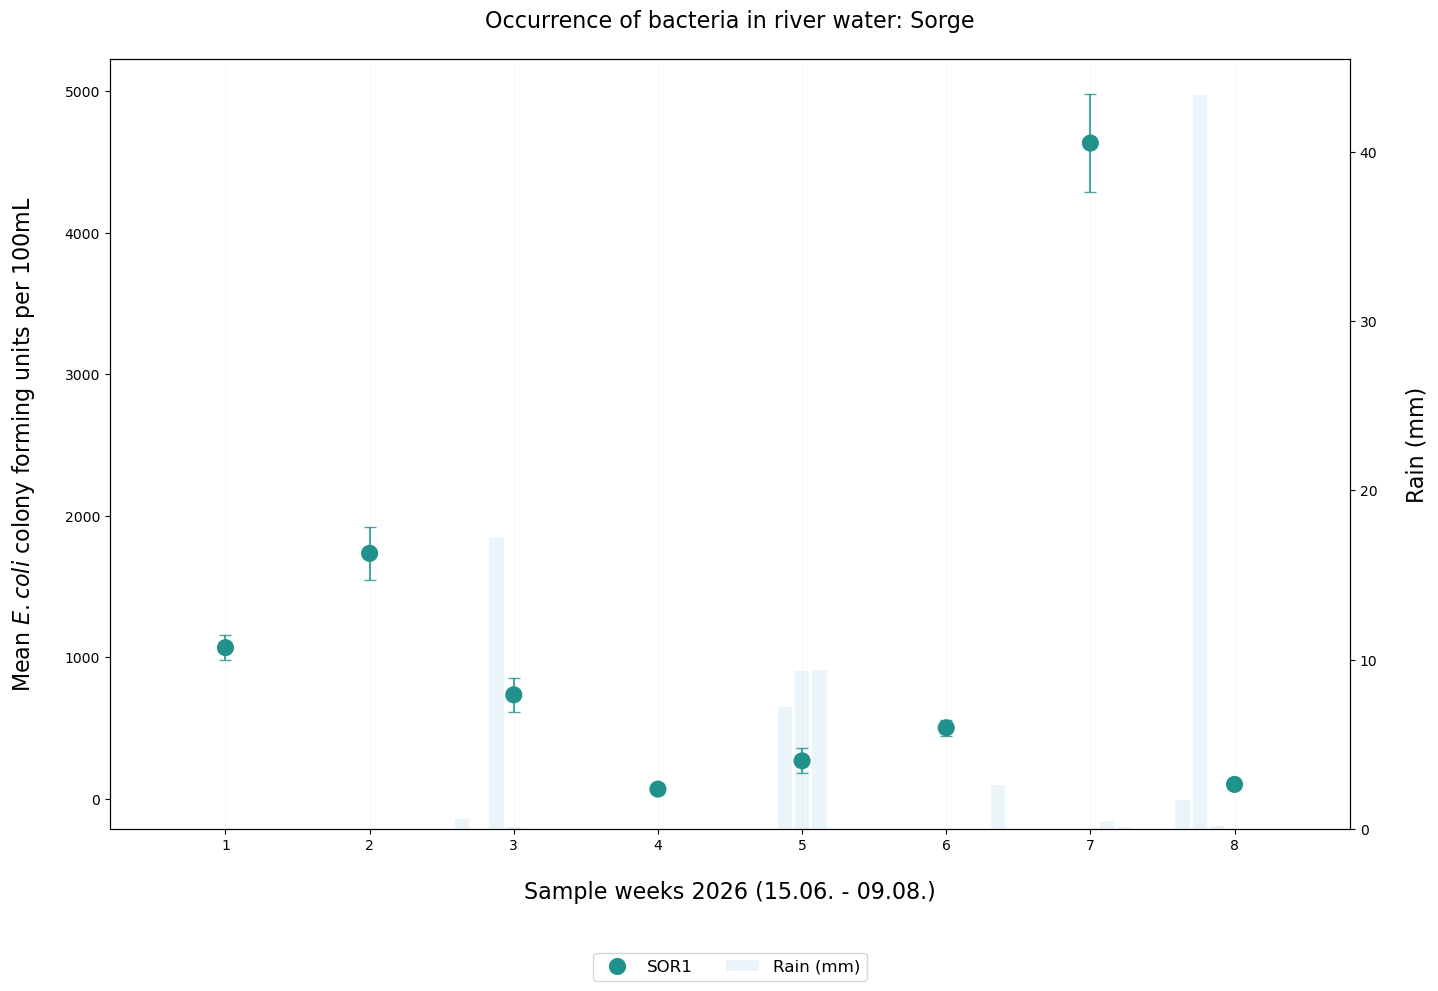

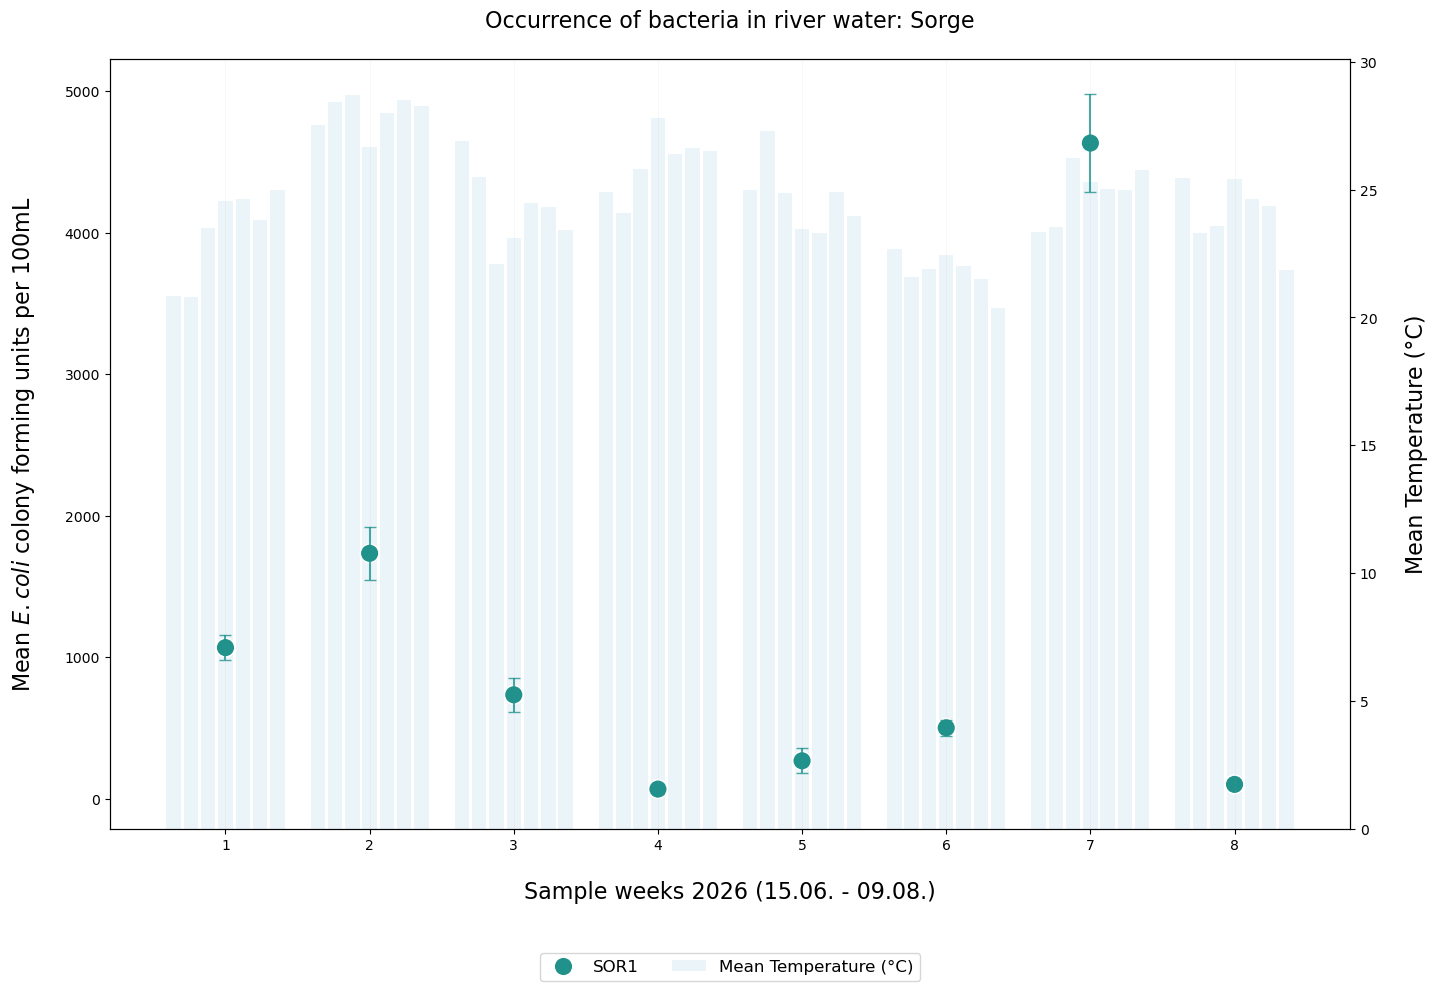

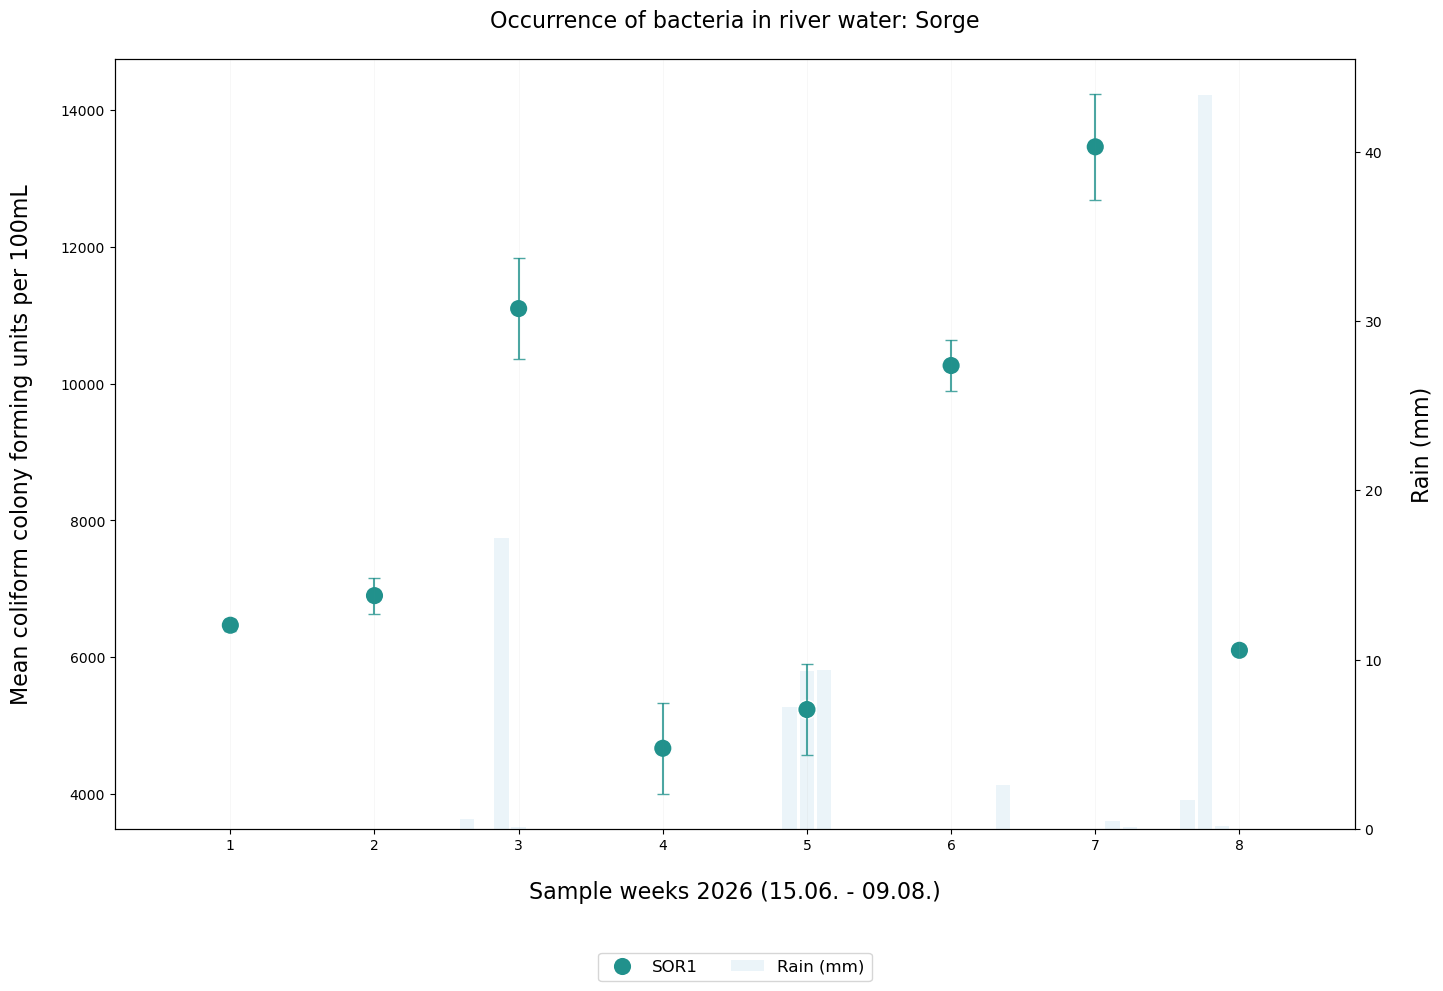

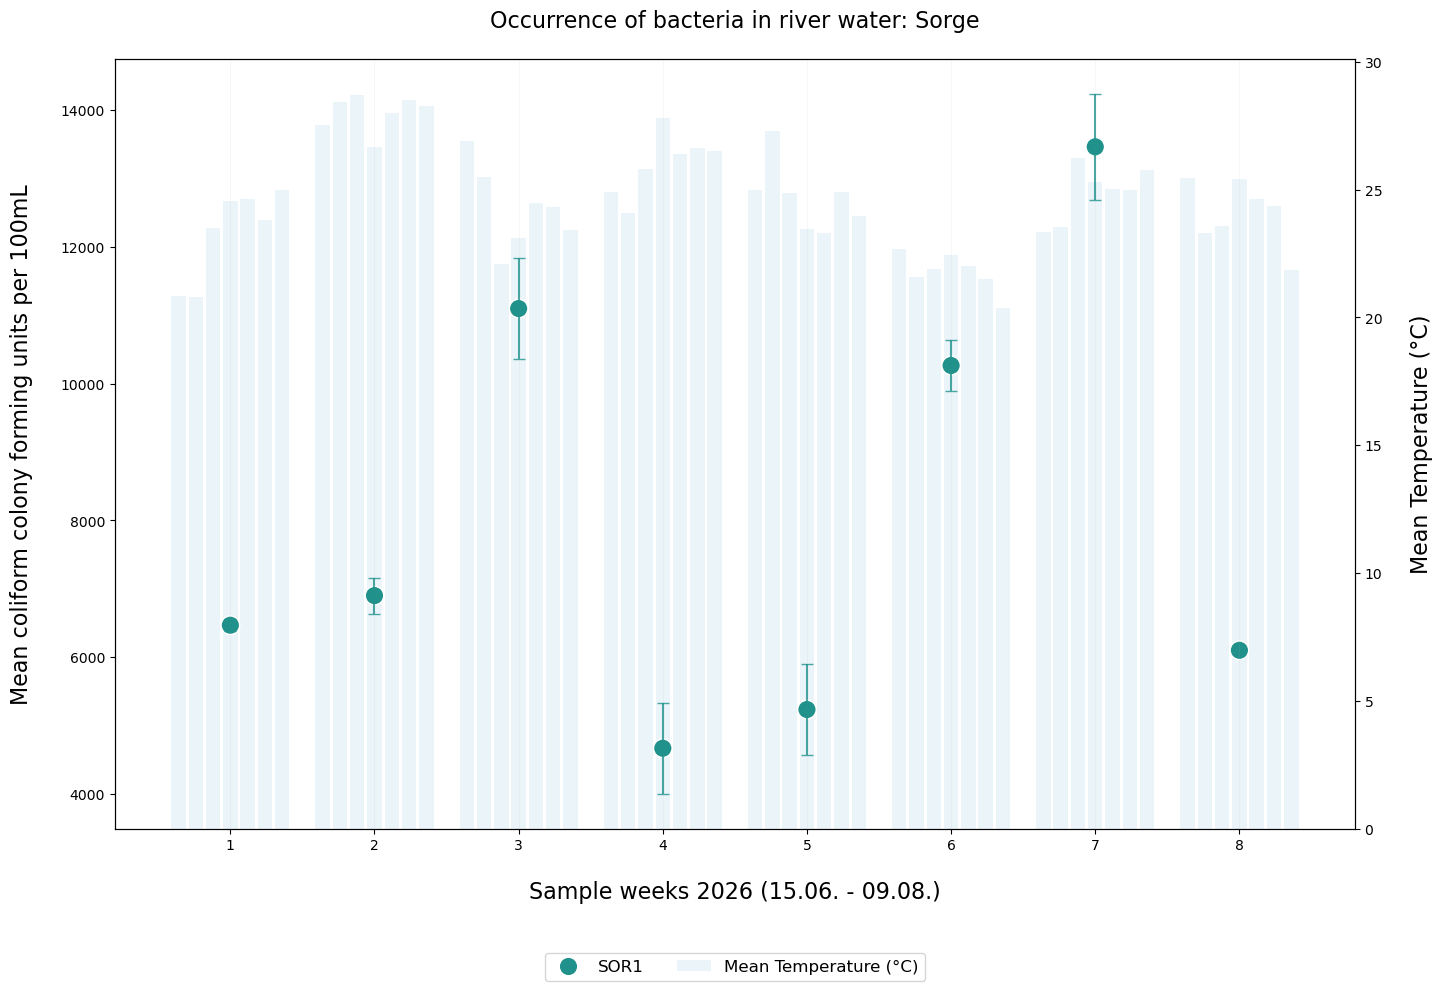

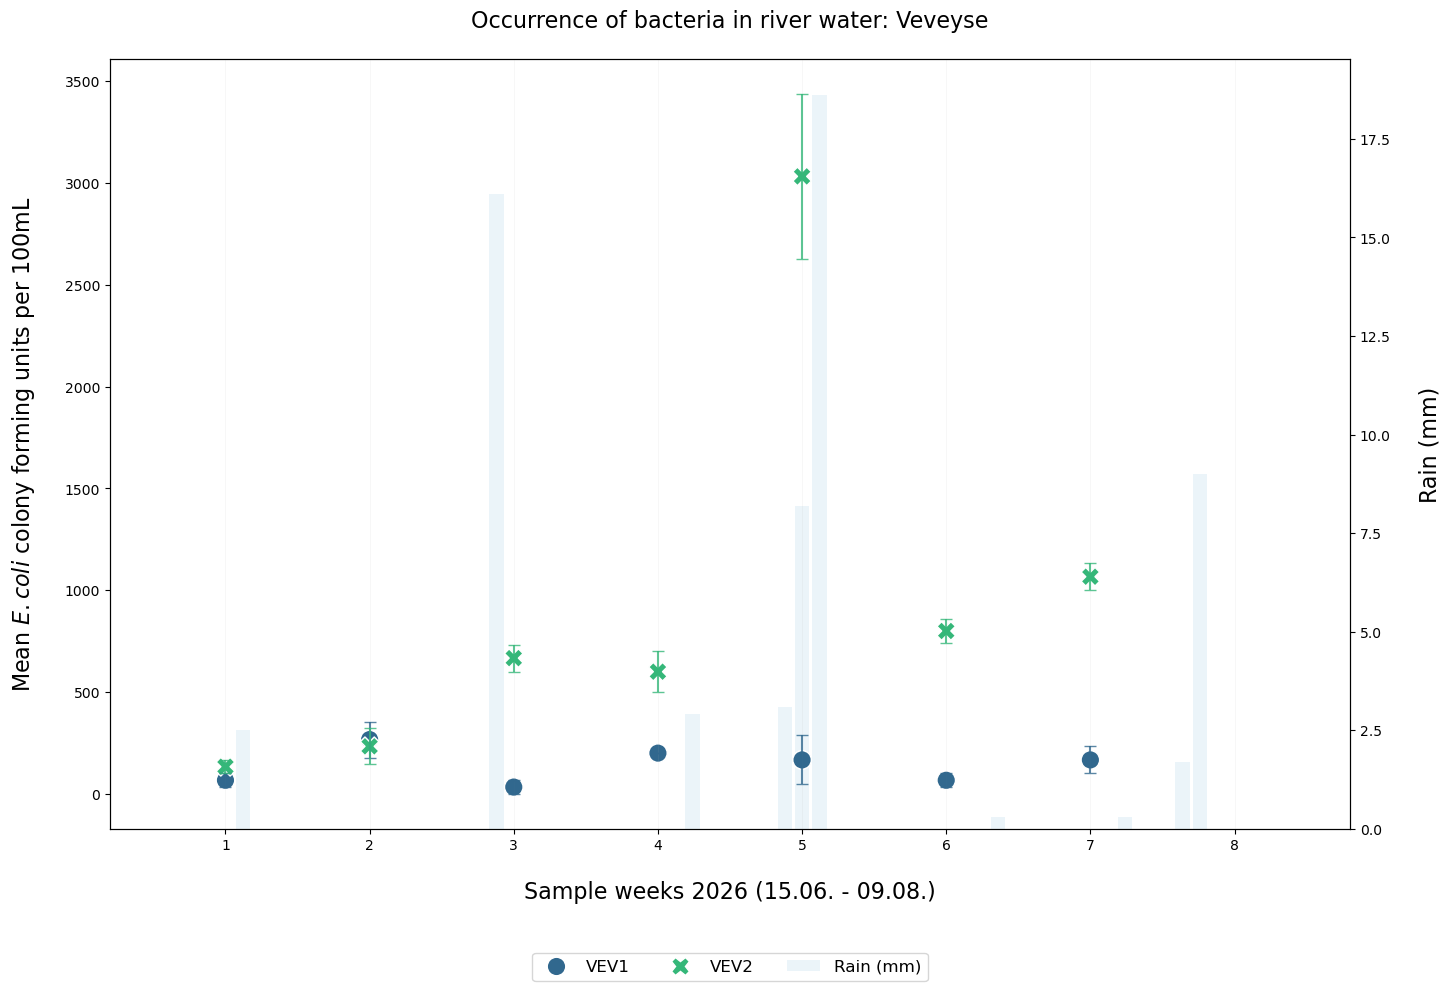

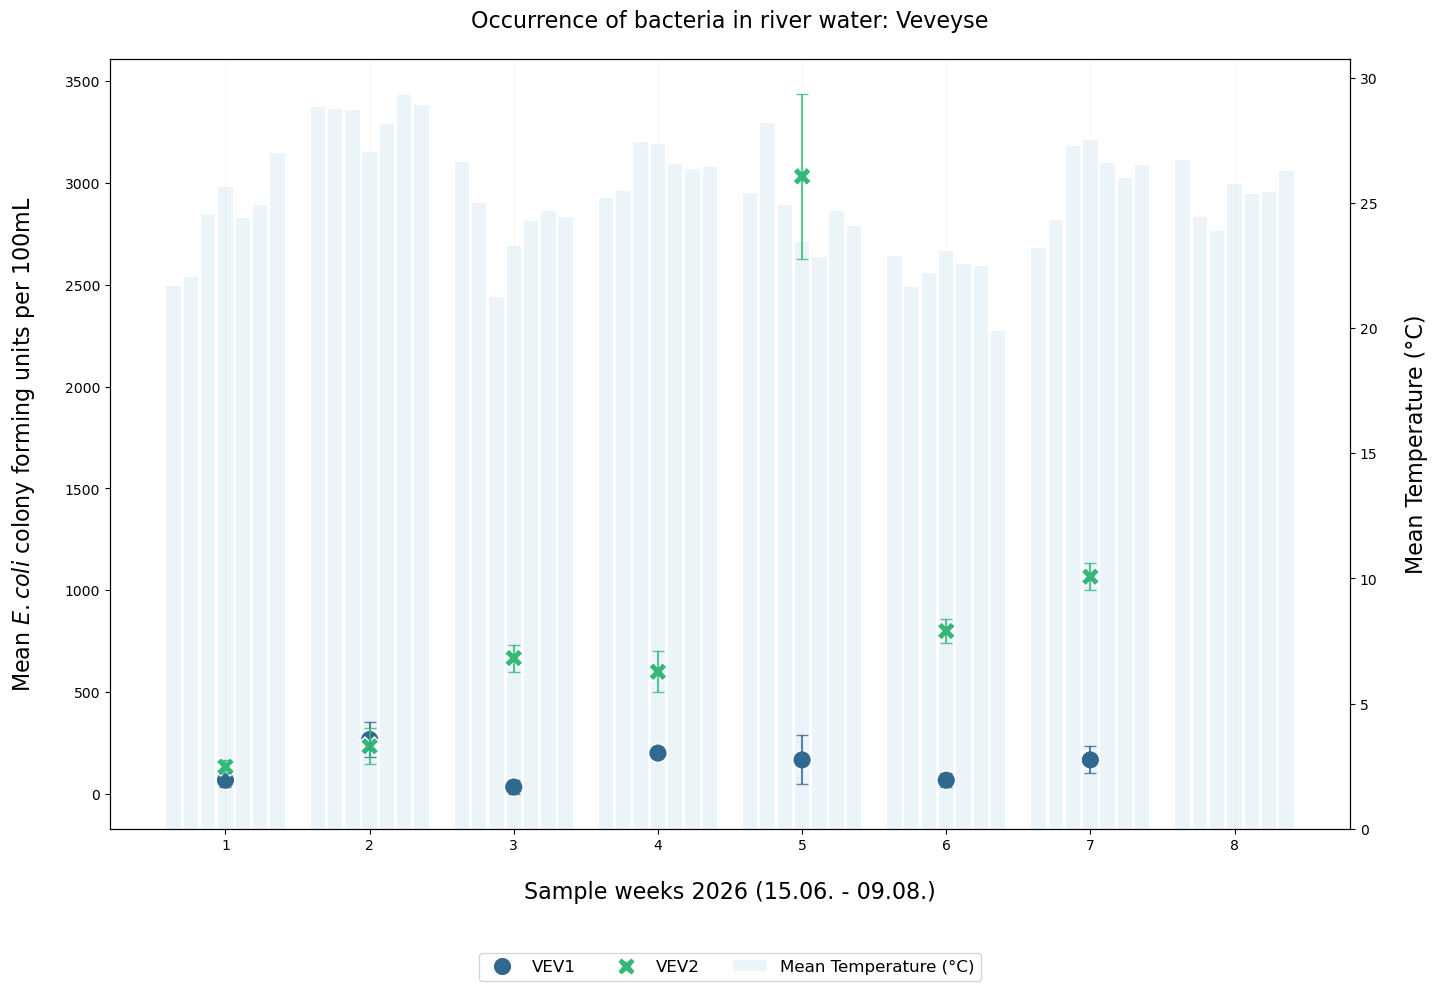

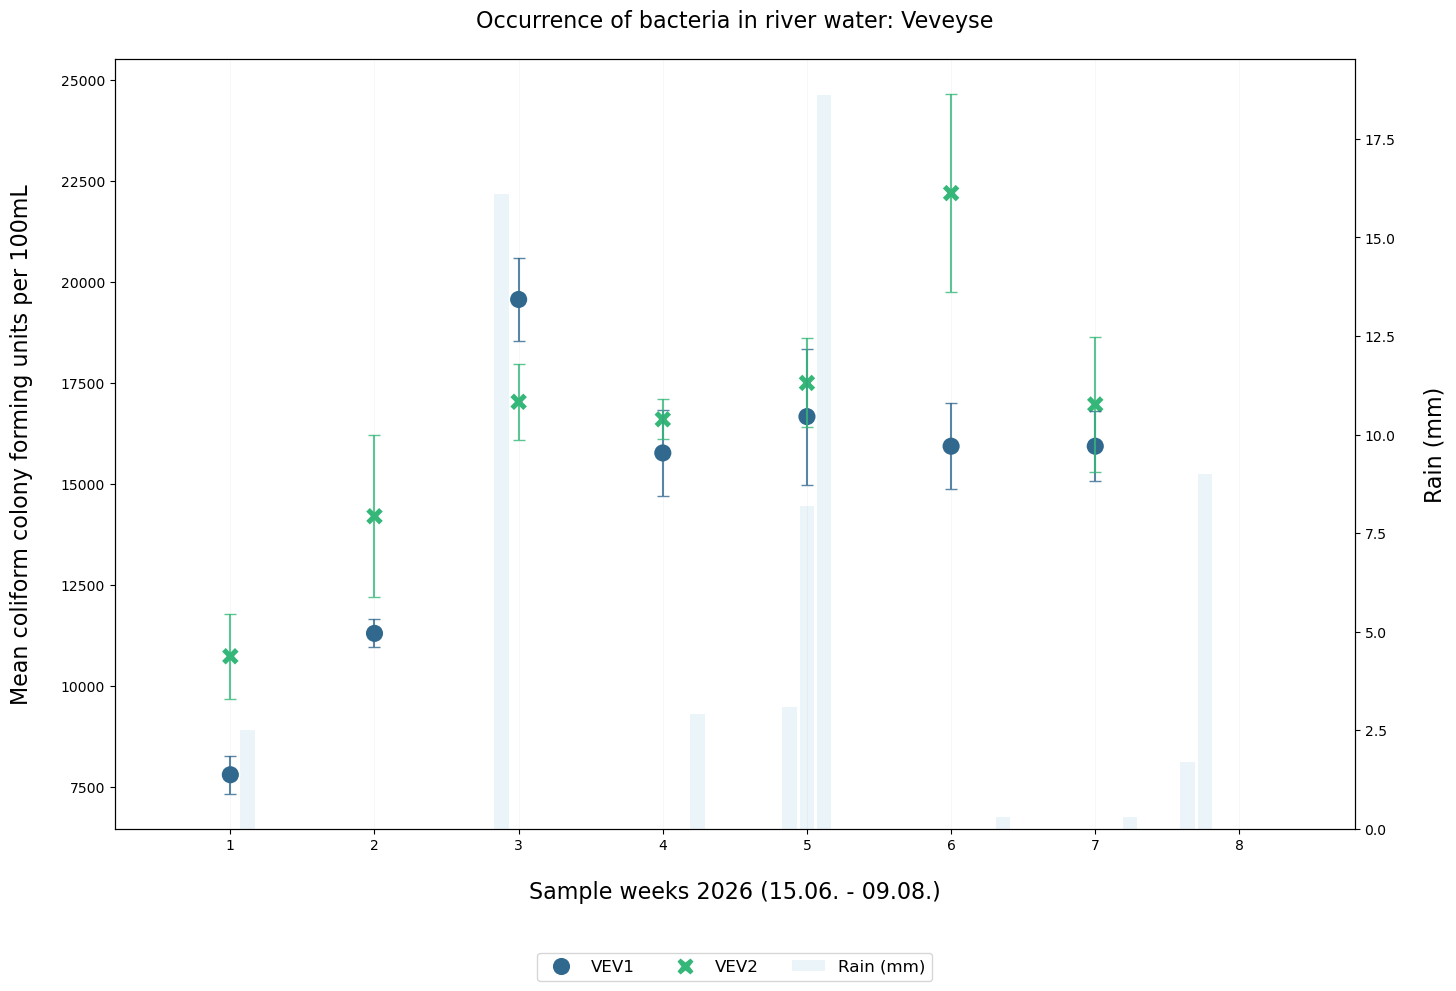

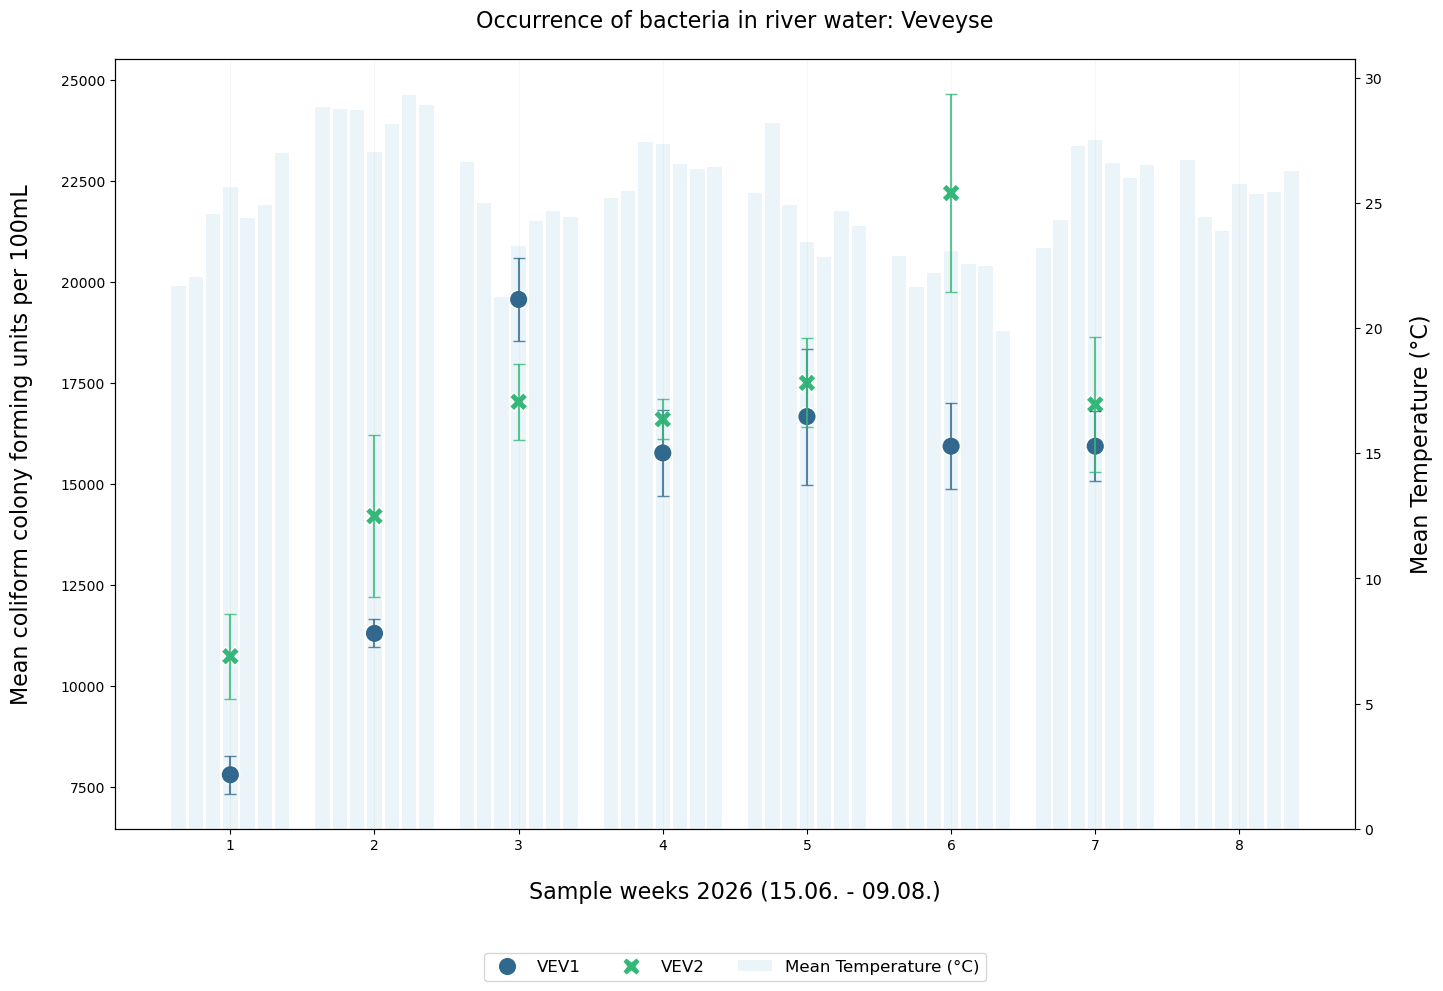

In [41]:
generate_plots_for_rivers(other_rivers)

### 3.4. Analysis By Site

In [42]:
df.groupby('ID site').agg({
    'Nb colonies E. coli':'mean',
    'Nb colonies coliformes':'mean'
}).sort_values('Nb colonies E. coli')

,Nb colonies E. coli,Nb colonies coliformes
ID site,,
SVT,0.05,21.24
PRE1,1.14,83.76
MRD,1.24,78.67
VNX,1.24,33.19
VEV1,1.38,147.10
BOIM1,1.60,355.20
BMO1,2.05,79.05
MOR1,3.52,226.29
VEN3,3.67,377.73


In [43]:
stats = df.groupby('ID site')[cols_measurements].describe()

stats = stats.sort_values(
    by=('Nb colonies E. coli', '75%'),
    ascending=False
)

stats.style.background_gradient(cmap='viridis').format('{:.2f}')

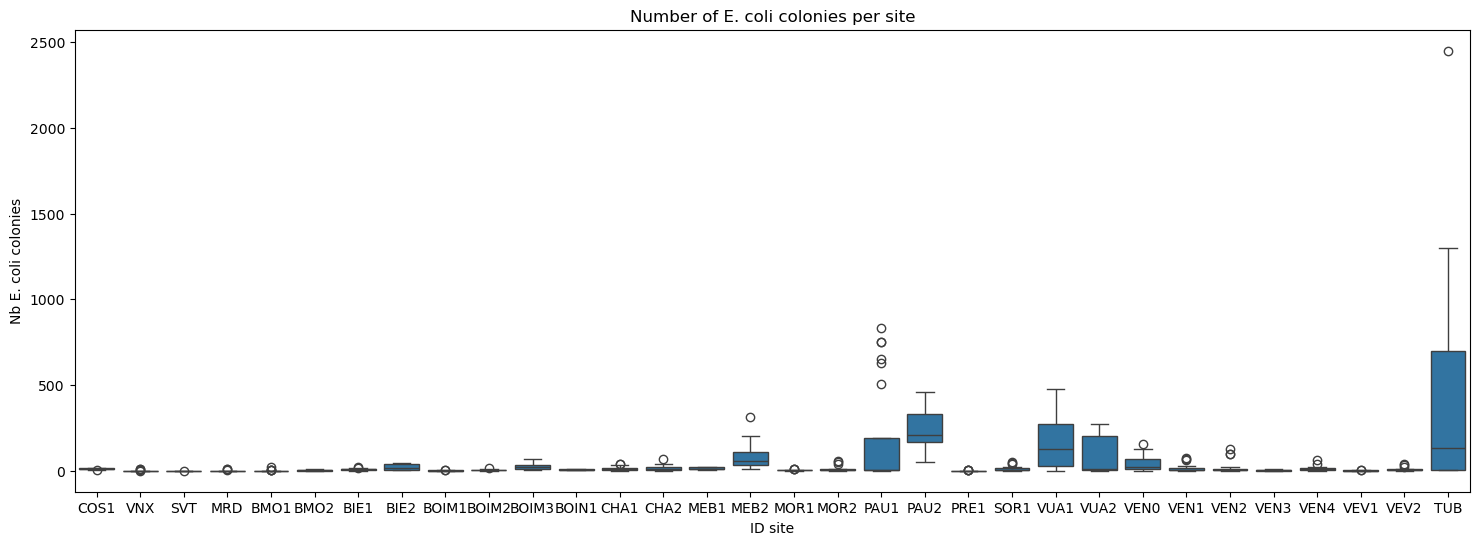

In [44]:
plt.figure(figsize=(18, 6))

sns.boxplot(
    data=df,
    x='ID site',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per site")
plt.xlabel("ID site")
plt.ylabel("Nb E. coli colonies");

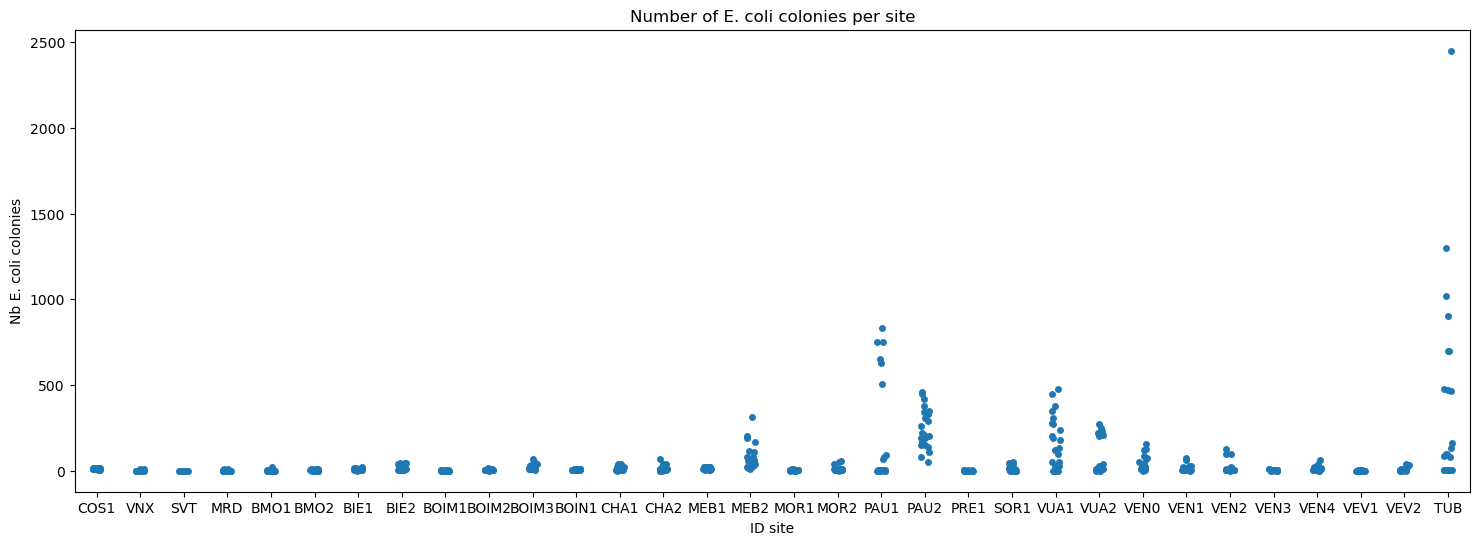

In [45]:
plt.figure(figsize=(18, 6))

sns.stripplot(
    data=df,
    x='ID site',
    y='Nb colonies E. coli'
)

plt.title("Number of E. coli colonies per site")
plt.xlabel("ID site")
plt.ylabel("Nb E. coli colonies");

In [46]:
def plotBySite(data, column, plotType):
    sites = sorted(data['ID site'].dropna().unique())

    ncols = 4
    nrows = math.ceil(len(sites) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 4 * nrows)
    )

    axes = axes.flatten()

    for ax, site in zip(axes, sites):
        data_site = df.loc[
            df['ID site'] == site,
            column
        ].dropna()
    
        if plotType == "boxplot":
            sns.boxplot(
                y=data_site,
                ax=ax
            )
        elif plotType == "stripplot":
            sns.stripplot(
                y=data_site,
                ax=ax,
                size=3,
                alpha=0.5
            )
    
        ax.set_title(site)
        ax.set_ylabel(column)
        ax.set_xlabel("")
    
    # Hide unused cells
    for ax in axes[len(sites):]:
        ax.set_visible(False)
    
    plt.tight_layout()

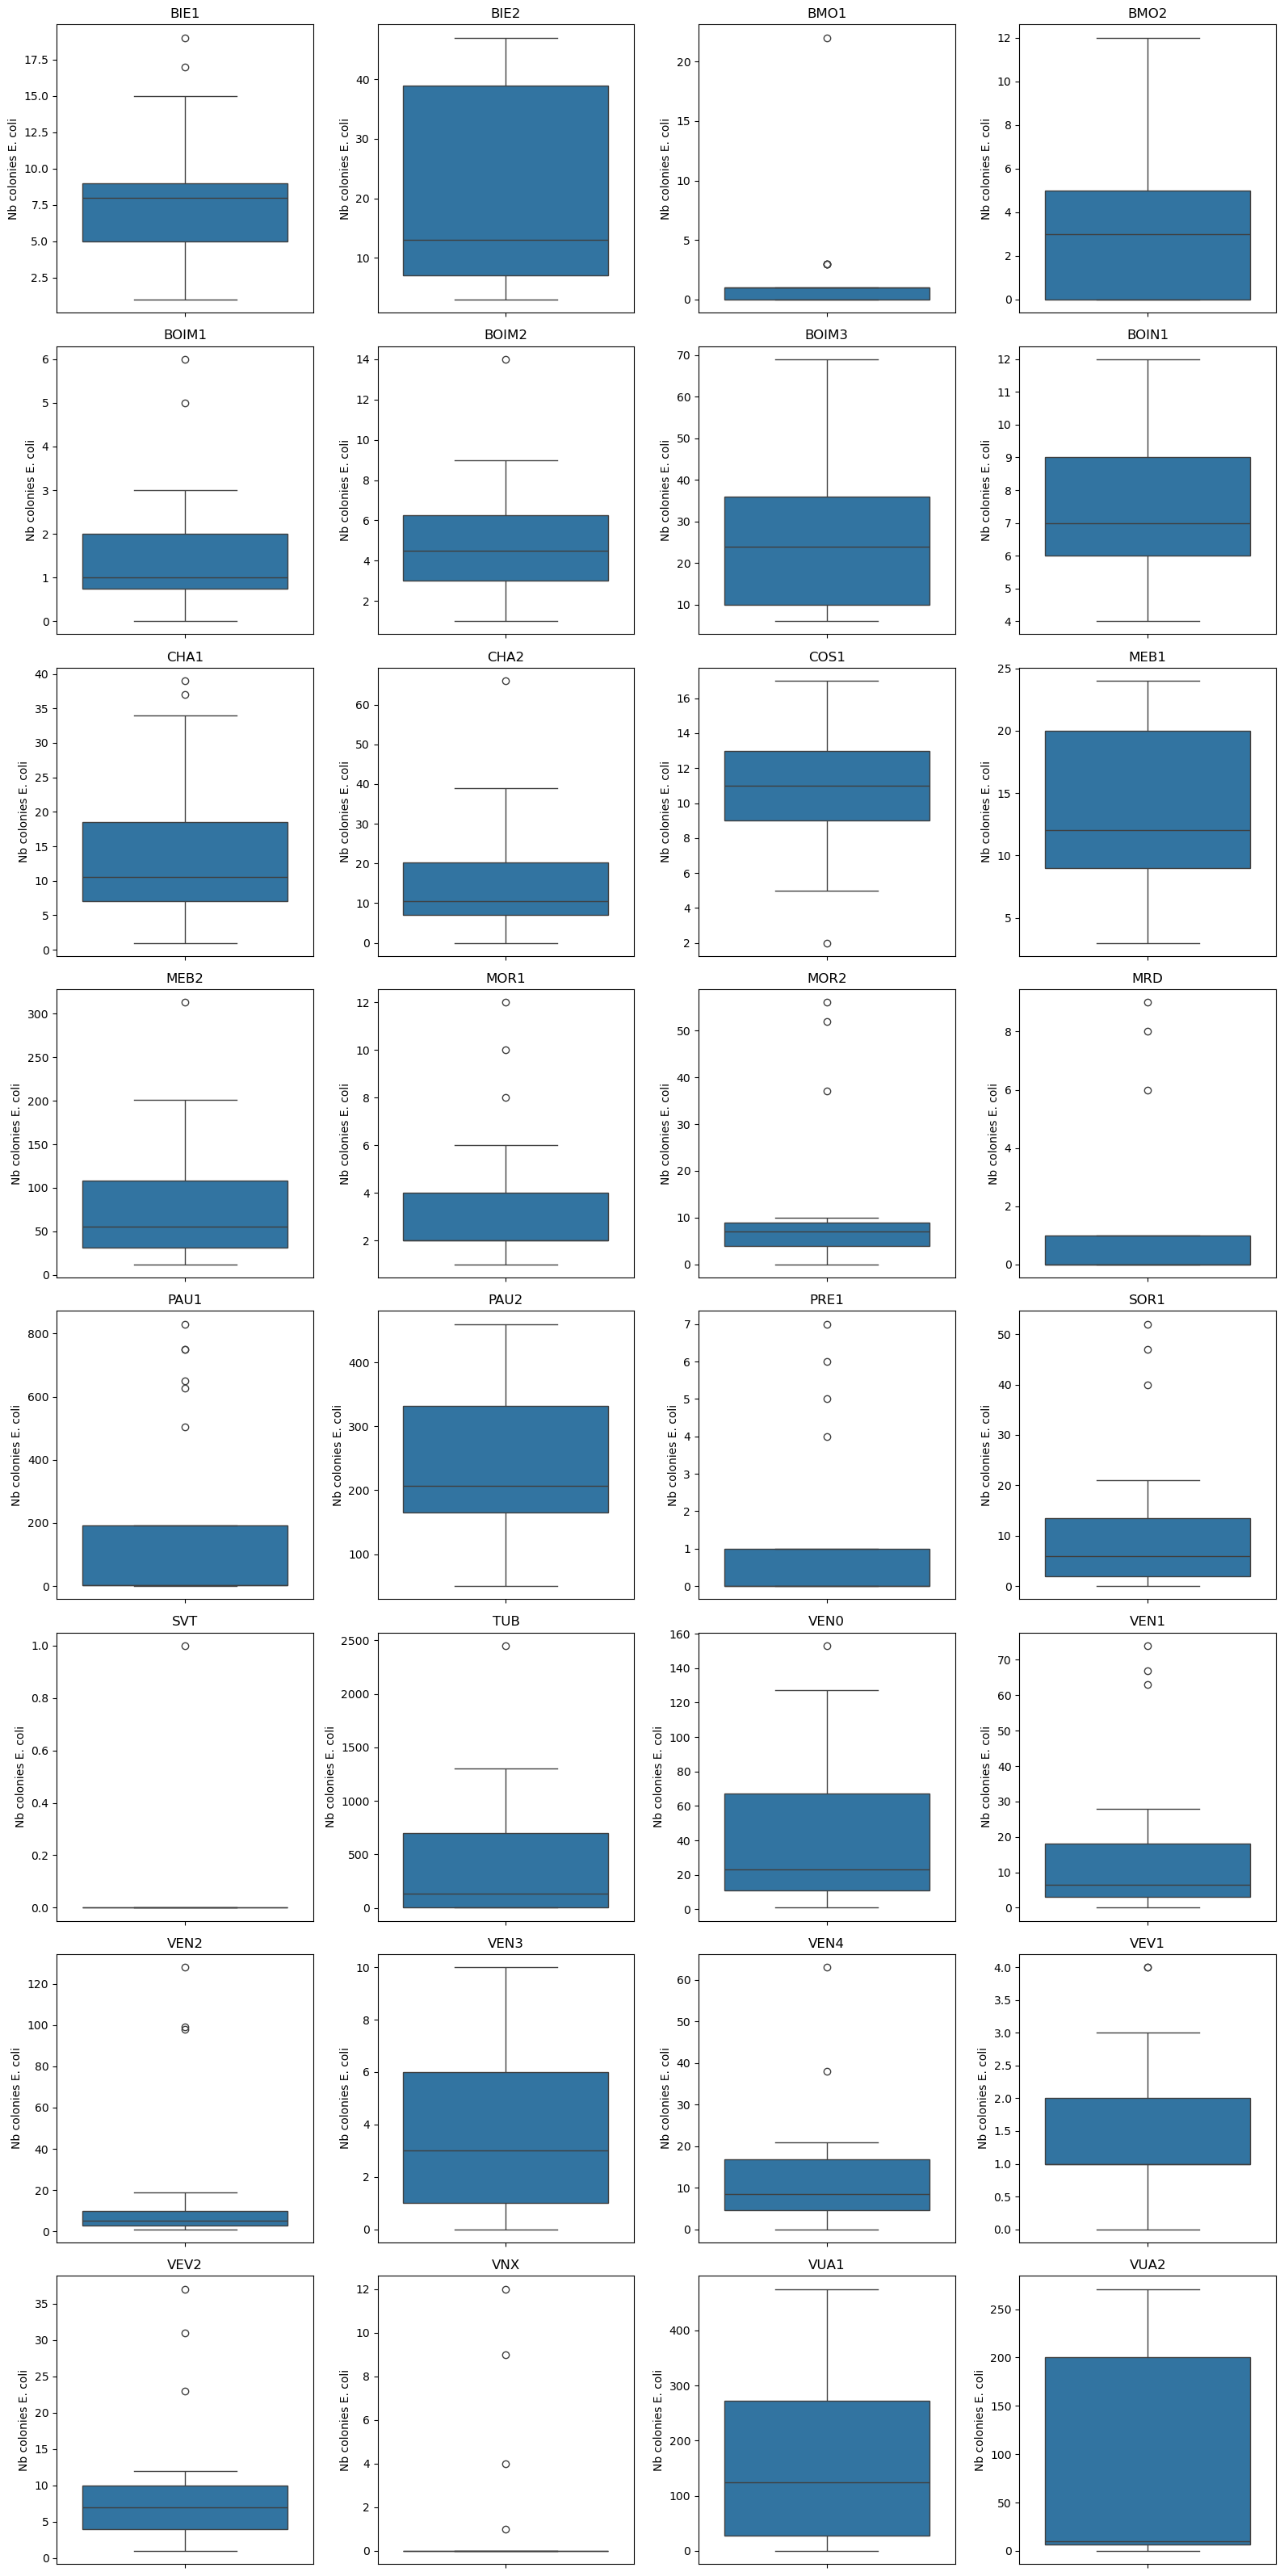

In [47]:
plotBySite(df, "Nb colonies E. coli", "boxplot")

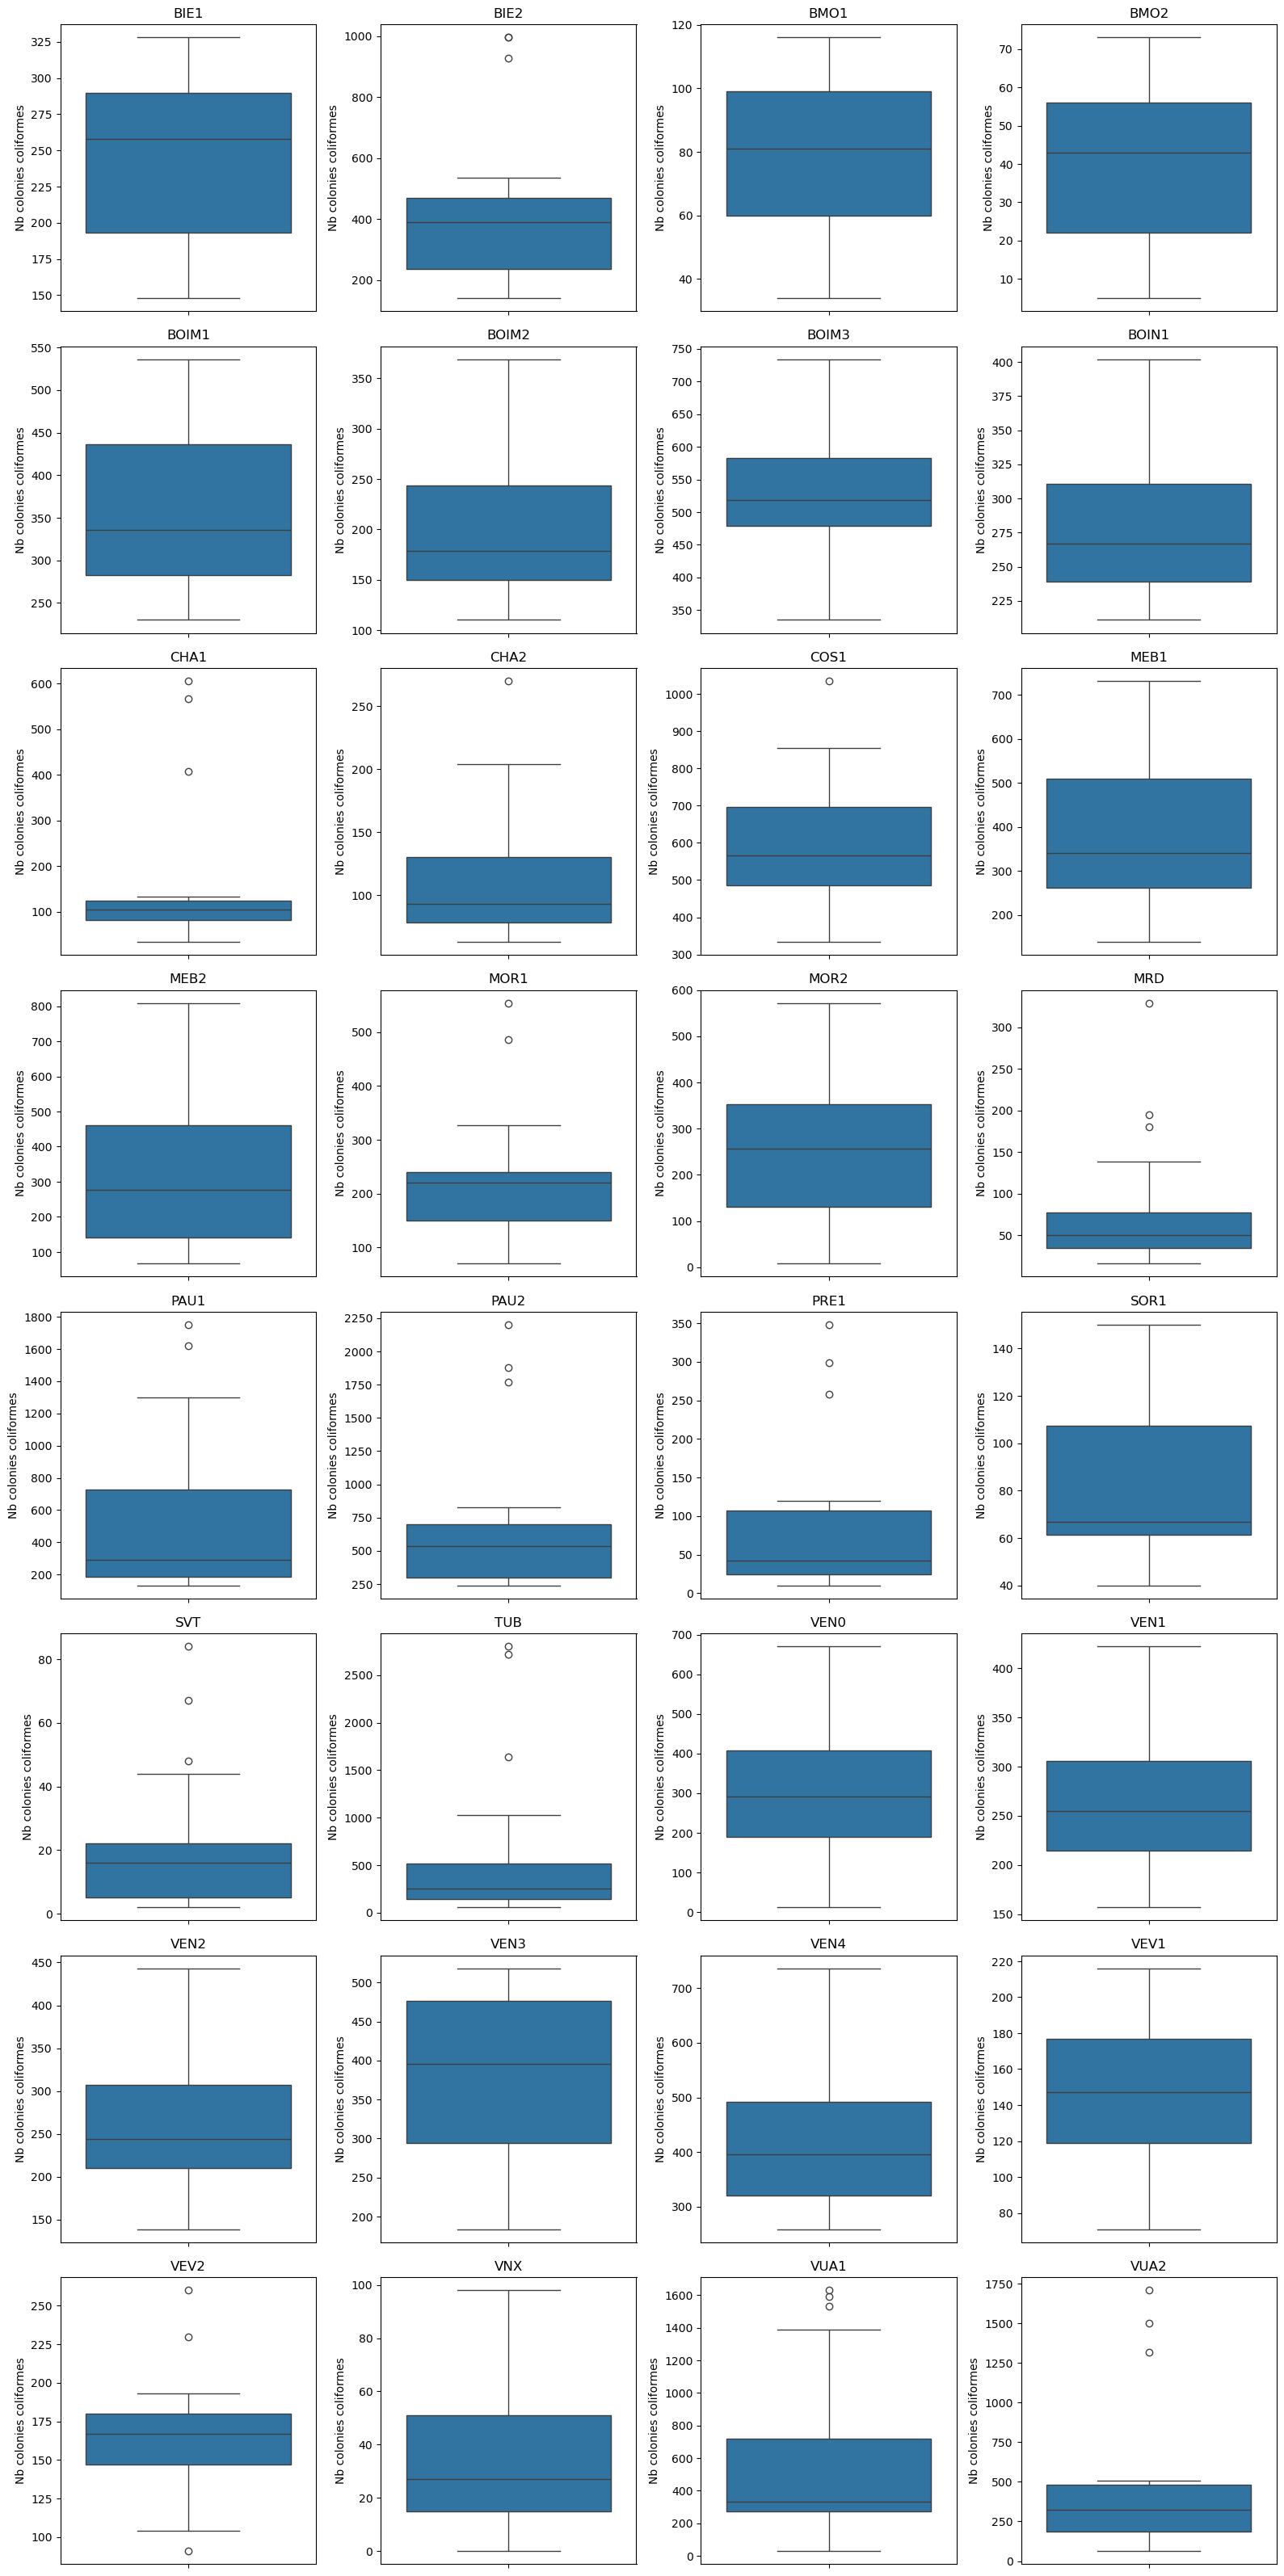

In [48]:
plotBySite(df, "Nb colonies coliformes", "boxplot")

In [49]:
sites = np.unique(df['ID site'])

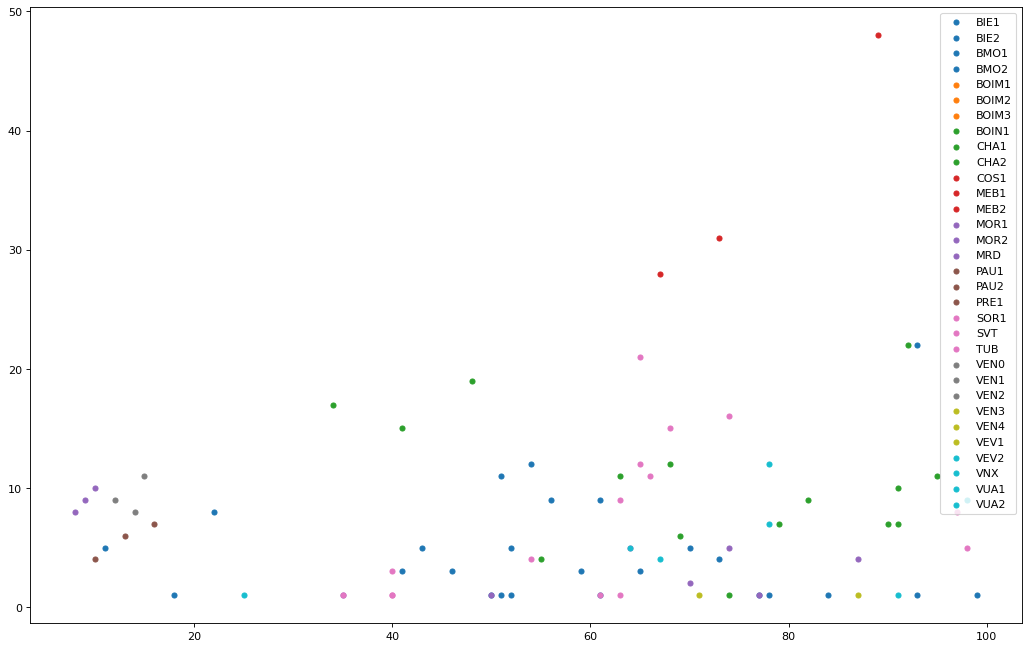

In [50]:
colors = [plt.cm.tab10(i/float(len(sites)-1)) for i in range(len(sites))]

df2 = df[(df['Nb colonies E. coli'] > 0) & (df['Nb colonies E. coli'] < 100) & (df['Nb colonies coliformes'] < 100) & (df['Nb colonies coliformes'] > 0)]

plt.figure(figsize=(16, 10), dpi= 80, facecolor='w', edgecolor='k')

for i, site in enumerate(sites):
    plt.scatter('Nb colonies coliformes', 'Nb colonies E. coli', 
                data=df2.loc[df2['ID site']==site, :], 
                s=20, color=colors[i], label=str(site))

plt.legend();

/var/folders/2f/64mxbpb54jlcq8vg5f_p1ybm0000gn/T/ipykernel_99868/1691755765.py:4: UserWarning: 
The palette list has fewer values (7) than needed (32) and will cycle, which may produce an uninterpretable plot.
  ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='ID site', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)


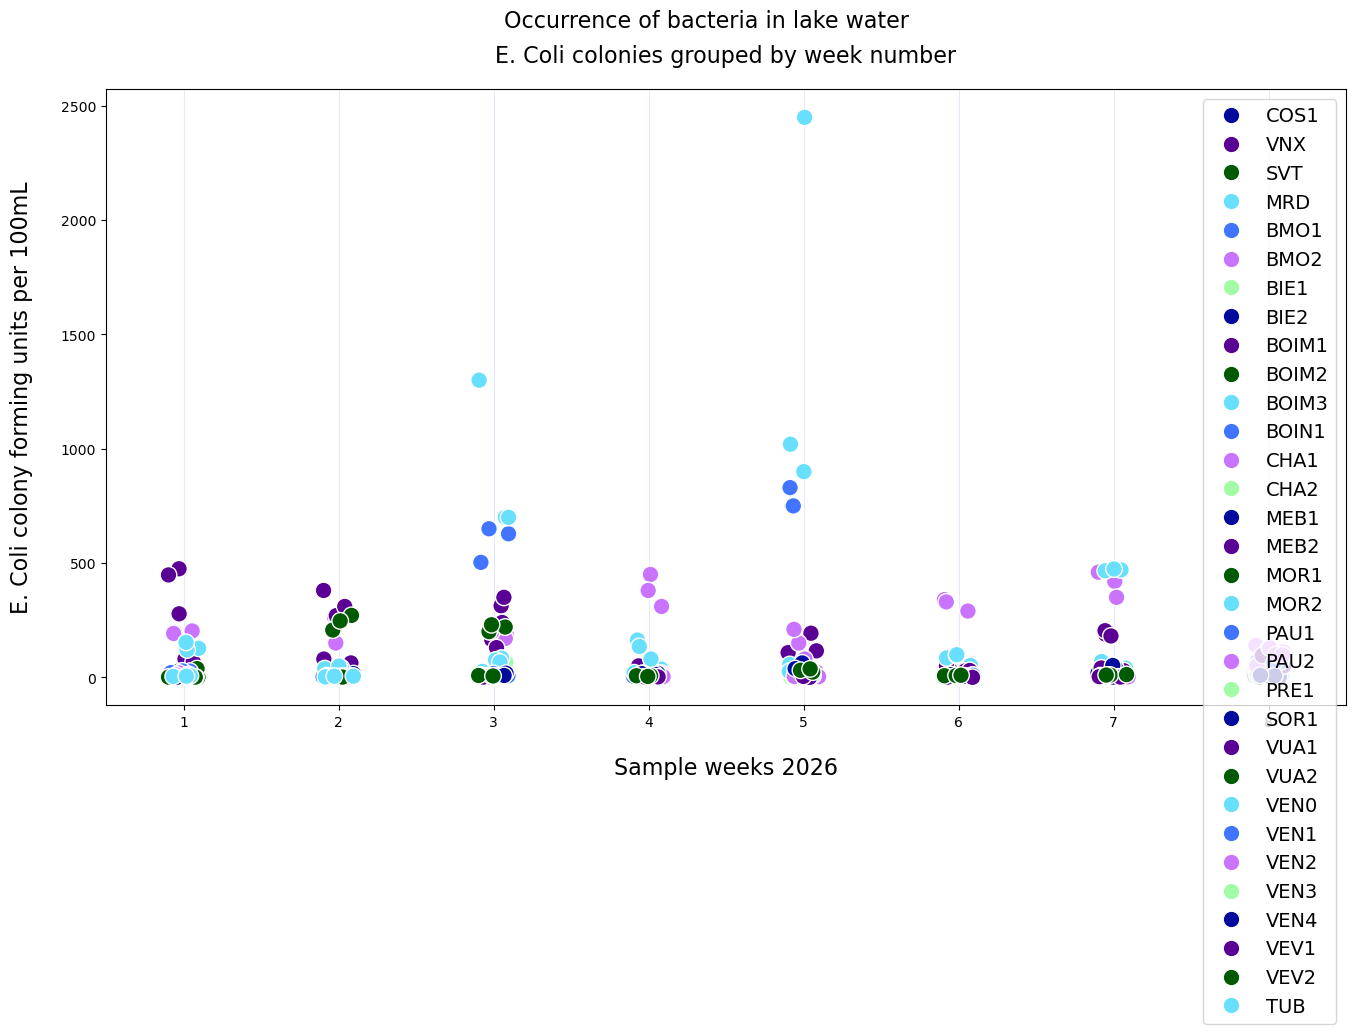

In [51]:
colors = ['#000A9C', '#5B0094', '#005903', '#68DFFC', '#4275FF', '#C973FF', '#A2FCA5']
fig, ax = plt.subplots(figsize=(16,8))

ax=sns.stripplot(x='Semaine', y='Nb colonies E. coli', hue='ID site', data=df,  alpha=1, size=12, linewidth=1, edgecolor='w', palette=colors)

ax.xaxis.grid(which="major", color='b', linewidth=0.7, alpha=0.1)
ax.set_xlabel("Sample weeks 2026", size=16, labelpad=20)

ax.set_ylabel("E. Coli colony forming units per 100mL", size=16, labelpad=20)
plt.suptitle("Occurrence of bacteria in lake water" , fontsize=16, family='sans')
plt.title("E. Coli colonies grouped by week number", fontsize=16, family='sans', y=1.03)
ax.legend(loc='upper right', fontsize=14);